# 🔍 เปรียบเทียบลายทองแดง (จากโมเดล) กับไฟล์ต้นแบบ → จำแนก Open / Short / Minor ด้วย AI
**ทำงานต่อจากโมเดลแยกลายทองแดงของคุณ · รันบน Raspberry Pi 5 (ไม่ต้อง real-time) · ไม่ต้องใช้ GPU / PyTorch**

```
 ภาพกล้อง ─► [โมเดลแยกทองแดงของคุณ] ─► mask (ขาว=ทองแดง) ─┐
                                                          ├─► ① จัดตำแหน่ง ─► ② หาจุดต่าง ─► ③ AI จำแนก ─► ผลลัพธ์
 ไฟล์ต้นแบบ (อัปโหลดตอนตรวจ, อยู่นอกโมเดล) ─────────────────┘   หมุน/กลับด้าน     candidate       open/short/
                                                                สเกล/perspective   + feature       minor/normal
```

| ขั้น | ทำอะไร | ทำไมทำแบบนี้ |
|---|---|---|
| ① จัดตำแหน่ง | ลอง **หมุนทุกมุม** (ทีละ 6°) × **กลับซ้าย-ขวา** × สเกล × สีทองแดงของต้นแบบ (ดำ/ขาว) แล้วละเอียดด้วย ECC affine + homography | บอร์ดวางทิศไหนก็ได้, ไฟล์ต้นแบบชั้น Bottom มักถูก mirror (ไฟล์ TEST1 ของคุณมีตัวหนังสือกลับด้าน) |
| ② หาจุดต่าง | ย่อต้นแบบลงให้ **ละเอียดเท่ากล้อง** ก่อน แล้วหาทองแดงที่หาย/เกินที่มีนัยสำคัญ | รายละเอียดเล็กกว่าที่กล้องเห็น (รูเจาะ, วงแหวนบาง, thermal relief) จะไม่ถูกนับเป็นตำหนิ |
| ③ จำแนก | สกัด 22 feature ต่อจุด (ขนาด, ความลึก, **net ถูกแบ่ง/เชื่อมกันไหม**, ความกว้างเส้นที่เหลือ ฯลฯ) → **RandomForest** | เทรนได้จากข้อมูลน้อย (เริ่มจากข้อมูลจำลอง แล้วเติมด้วย label ของคุณเอง), เร็วบน Pi, อธิบายได้ |

### คลาสที่ใช้
| คลาส | ความหมาย |
|---|---|
| `open` | ลายขาด — net เดียวกันในต้นแบบถูกแบ่งเป็น 2 ท่อน |
| `short` | ลายช็อต — ทองแดงเชื่อม 2 net ที่ต้นแบบแยกกัน |
| `minor` | เสียหายเล็กน้อย — แหว่ง/ปุ่มยื่น/รูเข็ม/เศษทองแดง ที่ยังไม่ขาดหรือช็อต |
| `normal` | **ไม่ใช่ตำหนิ** (false alarm จาก mask ไม่เนียน/แสง) — เพิ่มเข้ามาเพื่อให้ AI เรียน "ตัดทิ้ง" จุดที่ไม่ใช่ปัญหา |

> คุณต้องการ 3 คลาส (open/short/minor) — คลาส `normal` ช่วยให้ระบบไม่ต้องบังคับจุด noise ให้เป็นหนึ่งใน 3 คลาส
> ผลลัพธ์สุดท้ายจะแสดงเฉพาะ open/short/minor (ถ้าไม่ต้องการ normal ให้แก้ `pc.CLASSES` และไม่ต้อง label คลาสนั้น)

### สารบัญ
**0** ตั้งค่า · **A** ไลบรารี `pcb_compare.py` · **B** ตัวสร้างข้อมูลจำลอง · **C** Demo ทีละขั้น · **D** เทรน AI ·
**E** ตรวจของจริง (เดี่ยว/ทั้งโฟลเดอร์) · **F** Label เอง + เทรนซ้ำ · **G** FastAPI บน Pi · **H** เคล็ดลับ/แก้ปัญหา

## 0. ติดตั้ง + ตั้งค่า
```bash
# Raspberry Pi 5 (Raspberry Pi OS 64-bit)
pip install opencv-python-headless scikit-image scikit-learn joblib matplotlib ipywidgets fastapi uvicorn python-multipart
```
แก้ค่าใน cell ด้านล่างให้ตรงกับไฟล์ของคุณ

In [17]:
!pip install scikit-image scikit-learn joblib matplotlib ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 24.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.3/217.3 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.0/474.0 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.0 MB/s eta 0:00:00a 0:00:01


In [3]:
# !pip install opencv-python-headless scikit-image scikit-learn joblib matplotlib ipywidgets
import os, sys, json, glob, time, importlib, types
import cv2
import numpy as np
import matplotlib.pyplot as plt

def _resolve_path(p):
    """ช่วยหา path ให้ถูกต้อง ไม่ว่าจะรัน notebook จาก root หรือโฟลเดอร์ train_ai_compare"""
    if os.path.exists(p):
        return p
    parent_p = os.path.join("..", p)
    if os.path.exists(parent_p):
        return parent_p
    return p

# ---------- ไฟล์ต้นแบบ (Reference Designs) ----------
# โฟลเดอร์รวมไฟล์ต้นแบบจริง (test1..test4) จาก dataset_v4
DESIGN_DIR = _resolve_path("train_ai_pcb/dataset_v4/real-pcb")
DESIGN_PATH = _resolve_path("train_ai_compare/design/TEST1.png") if not os.path.exists("design/TEST1.png") else "design/TEST1.png"
DESIGN_COPPER = "auto"                              # "black" = ทองแดงสีดำ, "white" = ทองแดงสีขาว, "auto" = ให้ระบบเลือก

MASK_PATH = _resolve_path("train_ai_pcb/dataset_v4/masks/pcb_0001.png")     # mask จากโมเดลของคุณ (ขาว = ทองแดง)
PHOTO_PATH = _resolve_path("train_ai_pcb/dataset_v4/images/pcb_0001.png")   # ภาพถ่ายกรอบเดียวกับ mask (ไม่บังคับ)

MODEL_PATH = "models/defect_rf.joblib"    # โมเดล AI จำแนกตำหนิ
LABEL_DIR = "label_data"                  # โฟลเดอร์เก็บจุดที่รอ label / label แล้ว
SYNTH_CACHE = "models/synth_dataset.joblib"

# ---------- การเทรน ----------
N_SYNTH_BOARDS = int(os.getenv("N_SYNTH_BOARDS", "150"))   # จำนวนบอร์ดจำลอง (~2 วินาที/บอร์ดบน PC, ~5 วินาทีบน Pi 5)
REAL_WEIGHT = 3.0                          # น้ำหนักของข้อมูลจริงที่คุณ label เทียบกับข้อมูลจำลอง

os.makedirs("design", exist_ok=True)
os.makedirs("models", exist_ok=True)


def show(*imgs, titles=None, size=5):
    # ชื่อภาพใช้ภาษาอังกฤษ (ฟอนต์ matplotlib ปกติไม่มีภาษาไทย)
    fig, ax = plt.subplots(1, len(imgs), figsize=(size * len(imgs), size))
    ax = np.atleast_1d(ax)
    for i, im in enumerate(imgs):
        if im is None:
            continue
        if im.ndim == 3:
            ax[i].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        else:
            ax[i].imshow(im, cmap="gray")
        ax[i].axis("off")
        if titles and i < len(titles):
            ax[i].set_title(titles[i])
    plt.tight_layout(); plt.show()

print("ตั้งค่าสภาพแวดล้อมเรียบร้อย ✅")


ตั้งค่าสภาพแวดล้อมเรียบร้อย ✅


ไฟล์ต้นแบบตัวอย่าง (TEST1 ที่คุณส่งมา) — เขียนลงดิสก์เฉพาะเมื่อยังไม่มีไฟล์ที่ `DESIGN_PATH`

In [2]:
import base64
_TEST1_PNG = "..."
if not os.path.exists(DESIGN_PATH):
    with open(DESIGN_PATH, "wb") as f:
        f.write(base64.b64decode(_TEST1_PNG))
    print("เขียนไฟล์ตัวอย่าง →", DESIGN_PATH)

---
# ส่วน A — ไลบรารี `pcb_compare.py`
ฟังก์ชันทั้งหมดทำงานได้โดยตรงใน notebook นี้แบบ **All-in-One** ในไฟล์เดียว (ผูกกับ namespace `pc` เพื่อให้เรียก `pc.<ฟังก์ชัน>` หรือเรียกตรงๆ ได้ทั้งหมด)

### A1 — โหลดไฟล์ + เตรียม mask
- `load_mask` : ค่า ≥ 64 = ทองแดง (label 128 "ไม่แน่ใจ" ใน dataset ของคุณจะนับเป็นทองแดง) รองรับ probability map 0–1
- `load_design` : Otsu → ตัดขอบว่าง → ลบเส้นกรอบบอร์ด → เตรียมทั้งแบบ "ทองแดงดำ" และ "ทองแดงขาว" (โหมด auto)

In [38]:
# ==========================================================================================
# pcb_compare.py — เปรียบเทียบ "mask ลายทองแดงที่โมเดลทำนาย" กับ "ไฟล์ต้นแบบ (design)"
#   1) โหลด/ทำความสะอาด design + mask (รองรับ design ทองแดงสีดำหรือสีขาว, auto)
#   2) จัดตำแหน่งอัตโนมัติ: หมุนได้ทุกมุม + กลับซ้าย-ขวา (mirror) + ปรับสเกล + เลื่อน + perspective
#   3) หาจุดต่าง (candidate) ระหว่างสองลาย
#   4) สกัด feature เชิงรูปทรง/การเชื่อมต่อ (topology) ของแต่ละจุด
#   5) จำแนกด้วยโมเดล AI (RandomForest) → open / short / minor / normal
# ใช้ได้ทั้งใน notebook และ FastAPI บน Raspberry Pi 5 (ต้องการแค่ numpy, opencv, scikit-image, scikit-learn)
# ==========================================================================================
import os
import json
import time
import math
import cv2
import numpy as np
from skimage.morphology import skeletonize

CLASSES = ["open", "short", "minor", "normal"]          # normal = ไม่ใช่ตำหนิ (false alarm)
CLASS_COLORS = {"open": (0, 0, 255), "short": (255, 0, 255), "minor": (0, 200, 255), "normal": (160, 160, 160)}
CANON_LONG = 512                                         # ความยาวด้านยาวของ "กรอบมาตรฐาน" ที่ใช้เปรียบเทียบ (px)


# ---------------------------------------------------------------------------------------
# ยูทิลิตี้
# ---------------------------------------------------------------------------------------
def disk(r):
    r = max(0, int(round(r)))
    return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))


def dil(m, r):
    return cv2.dilate(m, disk(r)) if r >= 0.5 else m.copy()


def ero(m, r):
    return cv2.erode(m, disk(r)) if r >= 0.5 else m.copy()


def remove_small(m01, min_area):
    m01 = m01.astype(np.uint8)
    if min_area <= 1:
        return m01
    n, lab, st, _ = cv2.connectedComponentsWithStats(m01, connectivity=8)
    keep = np.zeros(n, np.uint8)
    keep[1:] = st[1:, cv2.CC_STAT_AREA] >= min_area
    return keep[lab]


def fill_small_holes(m01, max_area):
    inv = (1 - m01).astype(np.uint8)
    n, lab, st, _ = cv2.connectedComponentsWithStats(inv, connectivity=4)
    small = np.zeros(n, bool)
    small[1:] = st[1:, cv2.CC_STAT_AREA] < max_area
    # ไม่เติมช่องที่แตะขอบภาพ
    for side in (lab[0, :], lab[-1, :], lab[:, 0], lab[:, -1]):
        small[np.unique(side)] = False
    out = m01.copy()
    out[small[lab]] = 1
    return out


def _read_gray(src):
    if isinstance(src, str):
        img = cv2.imread(src, cv2.IMREAD_UNCHANGED)
        if img is None:
            raise FileNotFoundError(src)
    else:
        img = np.asarray(src)
    if img.ndim == 3:
        if img.shape[2] == 4:                       # PNG โปร่งใส → วางบนพื้นขาว
            a = img[..., 3:4].astype(np.float32) / 255
            img = (img[..., :3] * a + 255 * (1 - a)).astype(np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.dtype != np.uint8:                        # probability map 0..1
        img = np.clip(img.astype(np.float32) * (255 if img.max() <= 1.0 else 1), 0, 255).astype(np.uint8)
    return img


def load_mask(src, thr=64):
    """mask จากโมเดลแยกทองแดง: ขาว = ทองแดง (ค่า >= thr ถือเป็นทองแดง; label 128 'ไม่แน่ใจ' นับเป็นทองแดง)"""
    return (_read_gray(src) >= thr).astype(np.uint8)


def _trim_uniform(b01, frac=0.995):
    """ตัดขอบที่เป็นสีเดียวกันทั้งแถว/คอลัมน์ออก (ขอบกระดาษ/ขอบว่างของไฟล์ export)"""
    H, W = b01.shape
    bg = np.bincount([b01[0, 0], b01[0, -1], b01[-1, 0], b01[-1, -1]], minlength=2).argmax()
    rows = (b01 == bg).mean(1) < frac
    cols = (b01 == bg).mean(0) < frac
    if rows.sum() < 10 or cols.sum() < 10:
        return b01, (0, 0, W, H)
    y0, y1 = np.where(rows)[0][[0, -1]]
    x0, x1 = np.where(cols)[0][[0, -1]]
    return b01[y0:y1 + 1, x0:x1 + 1], (int(x0), int(y0), int(x1 - x0 + 1), int(y1 - y0 + 1))


def _drop_frame(m01, band_frac=0.05, thick_px=None):
    """
    ลบเส้นกรอบบอร์ด (board outline) ที่พิมพ์ติดมากับไฟล์ต้นแบบ:
      1) ก้อนทองแดงบางๆ ที่แตะขอบทั้ง 4 ด้าน
      2) เส้นตรงยาวบางๆ ที่วิ่งขนานขอบภาพ (อยู่ในแถบ band_frac ของขอบ)
    """
    H, W = m01.shape
    n, lab, st, _ = cv2.connectedComponentsWithStats(m01, connectivity=8)
    out = m01.copy()
    for k in range(1, n):
        x, y, w, h, a = st[k]
        if w >= 0.97 * W and h >= 0.97 * H and a < 0.12 * W * H:
            out[lab == k] = 0
    t = thick_px or max(4, int(round(0.012 * max(H, W))))       # เส้นที่บางกว่านี้ = เส้นกรอบ
    band = max(3, int(band_frac * min(H, W)))
    zone = np.zeros_like(out)
    zone[:band, :] = 1
    zone[-band:, :] = 1
    zone[:, :band] = 1
    zone[:, -band:] = 1
    hl = cv2.morphologyEx(out, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (max(3, int(0.3 * W)), 1)))
    vl = cv2.morphologyEx(out, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(3, int(0.3 * H)))))
    thick_v = cv2.morphologyEx(out, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (1, t)))
    thick_h = cv2.morphologyEx(out, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (t, 1)))
    frame = ((hl & (1 - thick_v)) | (vl & (1 - thick_h))) & zone
    frame = cv2.dilate(frame, np.ones((3, 3), np.uint8)) & out & (1 - (thick_v & thick_h))
    out[frame > 0] = 0
    return remove_small(out, max(4, int(0.0002 * H * W)))


def load_design(src, copper="auto", trim=True, drop_frame=True):
    """
    โหลดไฟล์ต้นแบบ (PNG/JPG ขาว-ดำ จาก KiCad/EasyEDA/ไฟล์พิมพ์ลาย)
    copper: "black" = ทองแดงเป็นสีดำ, "white" = ทองแดงเป็นสีขาว, "auto" = ลองทั้งสองแบบตอนจัดตำแหน่ง
    คืน dict {variants: [(ชื่อ, mask 0/1)], crop}
    """
    gray = _read_gray(src)
    _, bw = cv2.threshold(gray, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    crop = (0, 0, bw.shape[1], bw.shape[0])
    if trim:
        bw, crop = _trim_uniform(bw)
    variants = []
    for pol in (["black", "white"] if copper == "auto" else [copper]):
        m = (1 - bw) if pol == "black" else bw.copy()
        m = m.astype(np.uint8)
        if drop_frame:
            m = _drop_frame(m)
        variants.append((pol, m))
    return dict(variants=variants, crop=crop, src_shape=gray.shape)


def to_canon(m01, long_side=CANON_LONG):
    H, W = m01.shape
    s = long_side / max(H, W)
    size = (max(8, int(round(W * s))), max(8, int(round(H * s))))
    f = cv2.resize(m01.astype(np.float32), size, interpolation=cv2.INTER_AREA if s < 1 else cv2.INTER_LINEAR)
    return (f >= 0.5).astype(np.uint8)


def trace_width(D):
    """ประมาณความกว้างเส้นลายทั่วไป (px) จาก distance transform บนเส้นกลาง"""
    dt = cv2.distanceTransform(D, cv2.DIST_L2, 5)
    sk = skeletonize(D > 0)
    v = dt[sk]
    v = v[v >= 1]
    if len(v) == 0:
        return 4.0
    return float(max(3.0, 2 * np.percentile(v, 35)))


def _main_copper(m01, keep=0.985):
    """ตัดก้อนเล็กๆ ที่อยู่นอกบอร์ด (noise) ออก เก็บก้อนใหญ่ที่รวมกันได้ >= keep ของทองแดงทั้งหมด"""
    n, lab, st, _ = cv2.connectedComponentsWithStats(m01, connectivity=8)
    if n <= 2:
        return m01
    a = st[1:, cv2.CC_STAT_AREA]
    order = np.argsort(-a)
    cum = np.cumsum(a[order]) / a.sum()
    k = int(np.searchsorted(cum, keep)) + 1
    ok = np.zeros(n, np.uint8)
    ok[order[:k] + 1] = 1
    return ok[lab]


def _hull_area(m01):
    pts = cv2.findNonZero(m01)
    if pts is None or len(pts) < 3:
        return 1.0
    return max(1.0, float(cv2.contourArea(cv2.convexHull(pts))))

### A2 — จัดตำแหน่ง (หมุน/กลับด้าน/สเกล/perspective)
1. **ประมาณสเกล** จากพื้นที่ convex hull ของทองแดง (ไม่ขึ้นกับการหมุน)
2. **ค้นหาหยาบ**: ภาพย่อ ~112 px, หมุนทุก 6° × {ปกติ, mirror} × {ทองแดงดำ, ขาว} ให้คะแนนด้วย normalized cross-correlation
3. **ค้นละเอียด**: รอบผู้สมัคร 3 อันดับแรก มุม ±3° (ทีละ 1.5°) × สเกล ±10%
4. **ECC affine → ECC homography** ละเอียดระดับ sub-pixel + ชดเชยมุมกล้องเอียง (มีตัวกันหลุด `_sane`)
5. `design_as_seen` : ย่อ design ลงความละเอียดเดียวกับ mask → ใช้เทียบ (รายละเอียดที่กล้องมองไม่เห็นจะไม่ถูกนับ)

ผลลัพธ์ `A` (3×3) = การแปลงจากกรอบมาตรฐานของ design → พิกัดใน mask (ใช้วาดกรอบตำหนิกลับบนภาพถ่ายได้)

In [39]:

# ---------------------------------------------------------------------------------------
# การจัดตำแหน่ง (alignment): หมุนทุกมุม + mirror + สเกล + เลื่อน → ECC affine → ECC homography
# A (3x3) = การแปลงพิกัดจาก "กรอบมาตรฐานของ design" → "พิกัดภาพ mask"
# ---------------------------------------------------------------------------------------
def _M3(M2):
    return np.vstack([M2, [0, 0, 1]]).astype(np.float64)


def _blurf(m, sigma):
    f = m.astype(np.float32)
    return cv2.GaussianBlur(f, (0, 0), sigma) if sigma > 0 else f


def _rot_canvas(h, w, angle, scale, flip):
    """เมทริกซ์ (3x3) หมุน/สเกล/กลับด้าน รอบจุดกลาง แล้วเลื่อนให้อยู่ในกรอบใหม่ + ขนาดกรอบ"""
    F = np.array([[-1, 0, w - 1], [0, 1, 0], [0, 0, 1]], np.float64) if flip else np.eye(3)
    R = _M3(cv2.getRotationMatrix2D(((w - 1) / 2, (h - 1) / 2), angle, scale))
    M = R @ F
    c = np.array([[0, 0, 1], [w - 1, 0, 1], [w - 1, h - 1, 1], [0, h - 1, 1]], np.float64).T
    p = (M @ c)[:2]
    x0, y0 = p.min(1)
    x1, y1 = p.max(1)
    T = np.array([[1, 0, -x0], [0, 1, -y0], [0, 0, 1]], np.float64)
    return T @ M, (int(math.ceil(x1 - x0)) + 1, int(math.ceil(y1 - y0)) + 1)


def warp_to_canon(img, A, canon_shape, nearest=False, border=0):
    """ดัดภาพจากกรอบ mask กลับมาหากรอบมาตรฐานของ design (canon)"""
    flags = cv2.INTER_NEAREST if nearest else cv2.INTER_LINEAR
    return cv2.warpPerspective(img, np.linalg.inv(A), (canon_shape[1], canon_shape[0]), flags=flags, borderValue=border)


def warp_mask_to_canon(T, A, canon_shape):
    w = warp_to_canon(T, A, canon_shape)
    return (w >= 0.5).astype(np.uint8)


def match_score(D, Tc, r=2):
    """F1-score ระหว่างสองลาย (ยอมรับความคลาดเคลื่อน r px)"""
    cm = cv2.dilate(Tc, disk(r))
    cd = cv2.dilate(D, disk(r))
    prec = float((Tc & cd).sum() / max(1, Tc.sum()))
    rec = float((D & cm).sum() / max(1, D.sum()))
    return 0.0 if (prec + rec) == 0 else 2 * prec * rec / (prec + rec)


def align_quality(D, Tc, r=2, hull=None):
    """ประเมินคุณภาพการซ้อน: ดูทั้งพื้นที่รวมและเฉพาะพื้นที่ที่มีทองแดง"""
    s1 = match_score(D, Tc, r=r)
    s2 = match_score(D, Tc, r=max(1, r - 1))
    return 0.6 * s1 + 0.4 * s2


def _coarse_search(Dc, T, s0, angle_step=4.0, scale_factors=(0.85, 1.0, 1.18),
                   flips=(False, True), coarse_long=112, sigma=1.0, pad_frac=0.3, angles=None,
                   aspect_ratios=(1.0,)):
    """ค้นหาแบบหยาบ: รองรับหมุนทุกองศา × กลับด้าน × สเกล × อัตราส่วนภาพ (Aspect Ratio) ด้วย NCC"""
    Hc, Wc = Dc.shape
    ct = coarse_long / max(T.shape)
    Tsm = cv2.resize(T.astype(np.float32), (max(8, int(round(T.shape[1] * ct))), max(8, int(round(T.shape[0] * ct)))),
                     interpolation=cv2.INTER_AREA)
    ctx, cty = Tsm.shape[1] / T.shape[1], Tsm.shape[0] / T.shape[0]
    Tsm = cv2.GaussianBlur(Tsm, (0, 0), sigma)
    max_ar = max(aspect_ratios)
    pad = int(max(Wc, Hc) * s0 * ct * max(scale_factors) * max_ar * pad_frac) + 8
    Tp = cv2.copyMakeBorder(Tsm, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=0)
    ii, ii2 = cv2.integral2(Tp, sdepth=cv2.CV_64F)
    Sinv = np.diag([1 / ctx, 1 / cty, 1.0])
    res = []
    jobs = [(f, a) for f in flips for a in np.arange(0, 360, angle_step)] if angles is None else [(f, a) for f, a in angles]
    
    for ar in aspect_ratios:
        for sf in scale_factors:
            sx = s0 * sf
            sy = s0 * sf * ar
            w_c = max(4, int(round(Wc * sx * ct)))
            h_c = max(4, int(round(Hc * sy * ct)))
            Ds = cv2.resize(Dc.astype(np.float32), (w_c, h_c), interpolation=cv2.INTER_AREA)
            kx, ky = Ds.shape[1] / Wc, Ds.shape[0] / Hc
            Rs = np.diag([kx, ky, 1.0])
            for flip, ang in jobs:
                M, (tw, th) = _rot_canvas(Ds.shape[0], Ds.shape[1], ang, 1.0, flip)
                if tw >= Tp.shape[1] or th >= Tp.shape[0]:
                    continue
                tmpl = cv2.warpAffine(Ds, M[:2], (tw, th), flags=cv2.INTER_LINEAR, borderValue=0)
                tmpl = cv2.GaussianBlur(tmpl, (0, 0), sigma)
                if tmpl.std() < 1e-4:
                    continue
                r = cv2.matchTemplate(Tp, tmpl, cv2.TM_CCOEFF_NORMED)
                n = tw * th
                S = ii[th:, tw:] - ii[:-th, tw:] - ii[th:, :-tw] + ii[:-th, :-tw]
                S2 = ii2[th:, tw:] - ii2[:-th, tw:] - ii2[th:, :-tw] + ii2[:-th, :-tw]
                var = (S2 - S * S / n) / n
                r = np.where(var[:r.shape[0], :r.shape[1]] > 0.02 * tmpl.var(), r, -1)
                r = np.nan_to_num(r, nan=-1, posinf=-1, neginf=-1)
                _, mx, _, loc = cv2.minMaxLoc(r)
                Tr = np.array([[1, 0, loc[0] - pad], [0, 1, loc[1] - pad], [0, 0, 1]], np.float64)
                A = Sinv @ Tr @ M @ Rs
                res.append(dict(score=float(mx), flip=bool(flip), angle=float(ang), scale=float(s0 * sf), ar=float(ar), A=A))
    res.sort(key=lambda d: -d["score"])
    return res


def _ecc(Dc, T, A, motion, sigma_c=2.0, iters=80, eps=1e-5):
    """ECC บนภาพที่ย่อ design ลงให้ใกล้ความละเอียดของ mask (เร็วขึ้นมากบน Pi)"""
    s = math.sqrt(abs(np.linalg.det(A[:2, :2] / A[2, 2])))    # test px ต่อ canon px
    k = min(1.0, 1.3 * s)
    size = (max(8, int(round(Dc.shape[1] * k))), max(8, int(round(Dc.shape[0] * k))))
    kx, ky = size[0] / Dc.shape[1], size[1] / Dc.shape[0]
    K, Kinv = np.diag([kx, ky, 1.0]), np.diag([1 / kx, 1 / ky, 1.0])
    tmpl = cv2.GaussianBlur(cv2.resize(Dc.astype(np.float32), size, interpolation=cv2.INTER_AREA), (0, 0), max(0.6, sigma_c * k))
    inp = _blurf(T, max(0.6, sigma_c * s))
    As = A @ Kinv
    crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, iters, eps)
    try:
        if motion == cv2.MOTION_HOMOGRAPHY:
            w = (As / As[2, 2]).astype(np.float32)
            cc, w = cv2.findTransformECC(tmpl, inp, w, motion, crit, None, 1)
            return w.astype(np.float64) @ K, float(cc)
        w = (As / As[2, 2])[:2].astype(np.float32)
        cc, w = cv2.findTransformECC(tmpl, inp, w, motion, crit, None, 1)
        return _M3(w) @ K, float(cc)
    except cv2.error:
        return None, 0.0


def _sane(A0, A1, canon_shape, max_rel=0.25):
    """ป้องกัน ECC หลุด: มุมทั้ง 4 ของบอร์ดต้องไม่ขยับเกิน max_rel ของขนาดบอร์ด"""
    Hc, Wc = canon_shape
    c = np.array([[0, 0, 1], [Wc, 0, 1], [Wc, Hc, 1], [0, Hc, 1]], np.float64).T
    p0 = A0 @ c
    p1 = A1 @ c
    if np.any(np.abs(p1[2]) < 1e-6):
        return False
    p0, p1 = p0[:2] / p0[2], p1[:2] / p1[2]
    size = np.linalg.norm(p0[:, 2] - p0[:, 0])
    return bool(np.max(np.linalg.norm(p1 - p0, axis=0)) < max_rel * size)


def _angle_diff(a, b):
    d = abs(a - b) % 360
    return min(d, 360 - d)


def align(design, mask01, canon_max=768, canon_min=256, px_per_test=2.0, angle_step=4.0,
          allow_mirror=True, perspective=True, top_k=5, good_enough=0.92, verbose=False):
    """
    จัดตำแหน่ง design ให้ซ้อนกับ mask: หมุนได้ทุกมุม 360° + กลับซ้าย-ขวา + ปรับสเกล/อัตราส่วนภาพ + เลื่อน + perspective
      1) ประมาณสเกลเบื้องต้นจากพื้นที่ convex hull ของทองแดง
      2) ค้นหาแบบหยาบ (Coarse Search): ครอบคลุมมุมรอบทิศ × {ปกติ, กลับด้าน} × {สเกลหลายระดับ} × {ชดเชย Aspect Ratio จากกล้อง}
      3) คัดเลือกผู้สมัครที่ดีที่สุด top_k อันดับ
      4) ปรับละเอียดด้วย ECC affine → ECC homography (ชดเชยมุมกล้อง/perspective tilt)
    คืน dict: A (canon→mask 3x3), D (design ในกรอบมาตรฐาน), Tc (mask ที่ดัดเข้ากรอบมาตรฐาน), score, ...
    """
    t0 = time.time()
    if not isinstance(design, dict):
        design = load_design(design)
    mask01 = (mask01 > 0).astype(np.uint8)
    T = _main_copper(mask01)
    hullT = _hull_area(T)
    cands, canon = [], {}
    for pol, dm in design["variants"]:
        Hd, Wd = dm.shape
        ar_d = Wd / Hd
        ar_options = [1.0]
        if abs(ar_d - 1.0) > 0.08:
            ar_options.extend([ar_d, 1.0 / ar_d])
        
        base = to_canon(dm, 512)
        s512 = math.sqrt(hullT / _hull_area(base))
        long_ = int(np.clip(round(px_per_test * s512 * 512), canon_min, canon_max))
        Dc = to_canon(dm, long_)
        canon[pol] = Dc
        s0 = math.sqrt(hullT / _hull_area(Dc))
        flips = (False, True) if allow_mirror else (False,)
        
        # ค้นหาแบบหยาบครอบคลุมทั้ง scale factors และ aspect ratio options
        res = _coarse_search(Dc, T, s0, angle_step=angle_step, scale_factors=(0.85, 1.0, 1.18),
                             flips=flips, aspect_ratios=ar_options)
        for r in res:
            r["polarity"] = pol
        cands += res[:top_k * 2]
        
    cands.sort(key=lambda d: -d["score"])
    picked = []
    for c in cands:
        if all(not (c["polarity"] == p["polarity"] and c["flip"] == p["flip"] and
                    _angle_diff(c["angle"], p["angle"]) <= angle_step * 1.5) for p in picked):
            picked.append(c)
        if len(picked) >= top_k:
            break
            
    best = None
    for c in picked:
        Dc = canon[c["polarity"]]
        A = c["A"]
        for sig in (3.0, 1.5):
            A1, cc = _ecc(Dc, T, A, cv2.MOTION_AFFINE, sigma_c=sig)
            if A1 is not None and _sane(A, A1, Dc.shape):
                A = A1
        sc = align_quality(Dc, warp_mask_to_canon(T, A, Dc.shape))
        if perspective:
            A2, cc = _ecc(Dc, T, A, cv2.MOTION_HOMOGRAPHY, sigma_c=1.5)
            if A2 is not None and _sane(A, A2, Dc.shape, 0.08):
                sc2 = align_quality(Dc, warp_mask_to_canon(T, A2, Dc.shape))
                if sc2 >= sc - 1e-3:
                    A, sc = A2, sc2
        if verbose:
            print(f"  pol={c['polarity']} flip={c['flip']} ang={c['angle']:.1f} coarse={c['score']:.3f} → {sc:.3f}")
        if best is None or sc > best["score"]:
            best = dict(c, A=A, score=sc, D=Dc)
        if sc >= good_enough:
            break
            
    Dc, A = best["D"], best["A"]
    L = A[:2, :2] / A[2, 2]
    det = np.linalg.det(L)
    mirrored = det < 0
    Lm = L @ np.diag([-1, 1]) if mirrored else L
    angle = (-math.degrees(math.atan2(Lm[1, 0], Lm[0, 0]))) % 360
    return dict(A=A, D=Dc, Tc=warp_mask_to_canon(mask01, A, Dc.shape), T=mask01,
                score=best["score"], coarse_score=best["score"], polarity=best["polarity"],
                mirrored=bool(mirrored), angle=round(angle, 1), scale=round(math.sqrt(abs(det)), 4),
                time_s=round(time.time() - t0, 3))


def design_as_seen(D, A, mask_shape, blur=0.6):
    """
    'ต้นแบบในสายตากล้อง': ย่อ design ลงความละเอียดเดียวกับ mask (+เบลอเล็กน้อย) แล้วดัดกลับเข้ากรอบมาตรฐาน
    รายละเอียดที่เล็กกว่าความละเอียดกล้อง (รูเจาะเล็ก, thermal relief, วงแหวนบาง) จะหายไปเหมือนใน mask จริง
    → ลด false alarm ได้มาก
    """
    h, w = mask_shape
    s = math.sqrt(abs(np.linalg.det(A[:2, :2] / A[2, 2])))
    f = cv2.GaussianBlur(D.astype(np.float32), (0, 0), max(0.3, 0.45 / s))
    Dm = cv2.warpPerspective(f, A, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)
    if blur > 0:
        Dm = cv2.GaussianBlur(Dm, (0, 0), blur)
    Dm = (Dm >= 0.5).astype(np.uint8)
    return warp_mask_to_canon(Dm, A, D.shape), Dm


### A3 — หาจุดต่าง + สกัด feature
**Candidate** (จุดที่ต่าง):
- *ทองแดงหาย*: ต้นแบบมี แต่ mask ไม่มี และ **ลึกถึงเส้นกลางลาย** หรือหนากว่า tolerance
- *ทองแดงเกิน*: mask มี แต่ต้นแบบ (ความละเอียดเต็ม) ไม่มี และ **ยื่นเกิน tolerance**
- *สะพาน*: ทองแดงก้อนเดียวใน mask แตะ ≥ 2 net → หาจุดเชื่อม (ใช้หา short ในช่องแคบ)
- *โซนตรวจไม่ได้*: ช่องว่าง/ทองแดงที่แคบกว่า ~1.6 px ของ mask → ไม่นับ

**Feature 22 ตัว** (normalize ด้วยความกว้างเส้น จึงใช้ได้กับทุกลาย/ทุกความละเอียด):
`nets_bridged_*` (เชื่อมกี่ net = บ่งชี้ short), `split_*` (net ถูกแบ่งกี่ท่อน = บ่งชี้ open), `width_min/mean` (ความกว้างเส้นที่เหลือ),
`area_miss/extra`, `miss_skel_len`, `miss_depth`, `extra_out`, รูปร่างกรอบ, ระยะจากขอบบอร์ด, คะแนนการซ้อน, สัดส่วนในโซนตรวจไม่ได้ ฯลฯ

In [40]:


# ---------------------------------------------------------------------------------------
# หาจุดต่าง (candidates) + feature
# ---------------------------------------------------------------------------------------
FEATURE_NAMES = [
    "area_miss", "area_extra", "miss_skel_len", "miss_depth", "extra_out",
    "nets_bridged_local", "nets_bridged_global", "split_local", "split_global",
    "width_min", "width_mean", "extra_width_max", "bbox_long", "bbox_aspect",
    "region_solidity", "miss_frac_local", "extra_frac_local", "near_border", "align_score",
    "extra_touch_nets", "gap_local", "unc_frac",
]


def _touch_nets(region01, net_core_lab, min_px=3):
    v = net_core_lab[region01 > 0]
    v = v[v > 0]
    if len(v) == 0:
        return set()
    ids, cnt = np.unique(v, return_counts=True)
    return set(int(i) for i, c in zip(ids, cnt) if c >= min_px)


class Comparator:
    """เตรียมข้อมูลของการเปรียบเทียบหนึ่งคู่ (design canon D กับ mask ที่ดัดแล้ว Tc)"""

    def __init__(self, D, Tc, align_score=1.0, tol=None, border=None, px=1.0, min_feature=1.6, D_hi=None):
        """
        D    = design 'ในสายตากล้อง' (canon)  — ใช้หา net / ทองแดงหาย
        D_hi = design ความละเอียดเต็ม (canon) — ใช้ตัดสินทองแดงเกิน (ถ้าต้นแบบมีทองแดงจริงตรงนั้น ไม่นับว่าเกิน)
        Tc   = mask ที่ดัดเข้ากรอบแล้ว, px = จำนวน px ของ canon ต่อ 1 px ของ mask
        """
        self.D = D.astype(np.uint8)
        self.D_hi = (D_hi if D_hi is not None else D).astype(np.uint8)
        self.px = float(px)
        self.tw = trace_width(self.D)
        tw = self.tw
        self.tol = int(tol if tol is not None else max(2, round(max(0.3 * tw, 1.3 * px))))
        self.min_area = max(4, int(0.2 * tw * tw), int(round(px * px)))
        T = remove_small(Tc.astype(np.uint8), self.min_area)
        T = fill_small_holes(T, max(4, int(0.15 * tw * tw)))
        self.T_raw = T
        # โซนที่กล้องแยกไม่ออก: ช่องว่าง/ทองแดงที่แคบกว่า ~min_feature px ของ mask
        #   → ไม่นับว่าช็อต/ขาดตรงนั้น (ตรวจไม่ได้จริงที่ความละเอียดนี้)
        r = max(1, int(math.ceil((min_feature * px - 1) / 2)))
        k = disk(r)
        self.thin_gap = dil(((1 - D) & (1 - cv2.morphologyEx((1 - D).astype(np.uint8), cv2.MORPH_OPEN, k))).astype(np.uint8), 1) & (1 - D)
        self.thin_cu = dil((D & (1 - cv2.morphologyEx(D, cv2.MORPH_OPEN, k))).astype(np.uint8), 1) & D
        # ส่วนที่ 'ต้นแบบในสายตากล้อง' ต่างจากต้นแบบจริง = รายละเอียดเล็กกว่าความละเอียดกล้อง → ตรวจไม่ได้
        self.subres = (dil((self.D ^ self.D_hi).astype(np.uint8), 1)) if D_hi is not None else np.zeros_like(self.D)
        self.uncertain = (self.thin_gap | self.thin_cu | self.subres).astype(np.uint8)
        T = ((T & (1 - self.thin_gap)) | self.thin_cu).astype(np.uint8)
        T = np.where(self.subres > 0, self.D, T).astype(np.uint8)
        self.T = T
        self.align_score = align_score
        H, W = D.shape
        b = int(border if border is not None else max(3, round(0.6 * tw), round(2.5 * px)))
        self.valid = np.zeros_like(self.D)
        self.valid[b:H - b, b:W - b] = 1
        self.n_net, self.net = cv2.connectedComponents(self.D, connectivity=8)
        self.dtD = cv2.distanceTransform(self.D, cv2.DIST_L2, 5)
        self.dtDo = cv2.distanceTransform((1 - self.D).astype(np.uint8), cv2.DIST_L2, 5)
        self.dtT = cv2.distanceTransform(self.T, cv2.DIST_L2, 5)
        self.core = ero(self.D, 1)
        self.core_lab = self.net * self.core
        sk = skeletonize(self.D > 0).astype(np.uint8)
        self.skel = sk & (self.dtD >= max(1.5, 0.3 * tw)).astype(np.uint8)
        self.skel_lab = self.net * self.skel
        self.n_t, self.t_lab = cv2.connectedComponents(self.T, connectivity=8)
        # รูเจาะ (drill hole) ใน design = ช่องว่างเล็กที่ล้อมด้วย net เดียว → ไม่สนใจทองแดงเกินในนั้น
        self.ignore = self._drill_holes()
        # จำนวนท่อนของแต่ละ net ใน T (ใช้บอก open ระดับทั้งบอร์ด)
        self.frag_global = self._fragments_global()

    def _drill_holes(self):
        tw = self.tw
        inv = (1 - self.D).astype(np.uint8)
        n, lab, st, _ = cv2.connectedComponentsWithStats(inv, connectivity=4)
        ign = np.zeros_like(self.D)
        for k in range(1, n):
            if st[k, cv2.CC_STAT_AREA] > 10.0 * tw * tw:
                continue
            x, y, w, h = st[k, :4]
            if x <= 1 or y <= 1 or x + w >= self.D.shape[1] - 1 or y + h >= self.D.shape[0] - 1:
                continue
            x0, y0, x1, y1 = max(0, x - 3), max(0, y - 3), min(self.D.shape[1], x + w + 3), min(self.D.shape[0], y + h + 3)
            comp = (lab[y0:y1, x0:x1] == k).astype(np.uint8)
            ring = dil(comp, 2) & (1 - comp)
            nets = set(np.unique(self.net[y0:y1, x0:x1][ring > 0]).tolist()) - {0}
            if len(nets) <= 1:
                ign[y0:y1, x0:x1] |= dil(comp, 2)
        return ign

    def _fragments_global(self):
        frag = {}
        tcov = dil(self.T, 1)
        for i in range(1, self.n_net):
            sk = (self.skel_lab == i)
            n_sk = int(sk.sum())
            if n_sk < 3:
                continue
            ids = self.t_lab[sk & (tcov > 0)]
            ids = ids[ids > 0]
            if len(ids) == 0:
                frag[i] = 0
                continue
            u, c = np.unique(ids, return_counts=True)
            frag[i] = int((c >= max(3, 0.5 * self.tw)).sum())
        return frag

    # ------------------------------------------------------------------
    def candidates(self):
        tw, tol = self.tw, self.tol
        D, T, V = self.D, self.T, self.valid
        Dh = dil(self.D_hi, 1)
        miss = (D & self.D_hi & (1 - T) & V & (1 - self.ignore)).astype(np.uint8)
        extra = (T & (1 - D) & (1 - Dh) & V & (1 - self.ignore)).astype(np.uint8)
        keep = np.zeros_like(D)
        # ทองแดงหาย: ต้องลึกถึงเส้นกลาง หรือ หนาเกิน tol
        n, lab, st, _ = cv2.connectedComponentsWithStats(miss, connectivity=8)
        skd = dil(self.skel, 1)
        for k in range(1, n):
            if st[k, cv2.CC_STAT_AREA] < 3:
                continue
            x, y, w, h = st[k, :4]
            comp = lab[y:y + h, x:x + w] == k
            if (skd[y:y + h, x:x + w][comp]).any() or self.dtD[y:y + h, x:x + w][comp].max() > tol + 0.5:
                keep[y:y + h, x:x + w][comp] = 1
        # ทองแดงเกิน: ต้องยื่นออกเกิน tol
        n, lab, st, _ = cv2.connectedComponentsWithStats(extra, connectivity=8)
        for k in range(1, n):
            if st[k, cv2.CC_STAT_AREA] < 3:
                continue
            x, y, w, h = st[k, :4]
            comp = lab[y:y + h, x:x + w] == k
            if self.dtDo[y:y + h, x:x + w][comp].max() > tol + 0.5:
                keep[y:y + h, x:x + w][comp] = 1
        # short ที่ช่องแคบมาก (สะพานอยู่ในระยะ tol): T ก้อนเดียวแตะหลาย net
        for j in range(1, self.n_t):
            comp = (self.t_lab == j)
            nets = _touch_nets(comp.astype(np.uint8), self.core_lab, 3)
            if len(nets) < 2:
                continue
            ex = comp & (D == 0) & (V > 0)
            if not ex.any():
                continue
            nets = sorted(nets)[:6]
            dts = [cv2.distanceTransform((self.net != i).astype(np.uint8), cv2.DIST_L2, 3) for i in nets]
            for a in range(len(nets)):
                for b in range(a + 1, len(nets)):
                    s = dts[a] + dts[b]
                    sv = s[ex]
                    if len(sv) == 0:
                        continue
                    lim = sv.min() + max(2.0, 0.5 * tw)
                    if sv.min() > 6 * tw:
                        continue
                    keep[ex & (s <= lim)] = 1
        # รวมจุดใกล้กันเป็นกลุ่มเดียว
        grp = dil(keep, max(2, round(0.6 * tw)))
        n, lab, st, _ = cv2.connectedComponentsWithStats(grp, connectivity=8)
        out = []
        for k in range(1, n):
            x, y, w, h = st[k, :4]
            reg = ((lab == k) & (keep > 0)).astype(np.uint8)
            if reg.sum() < 3:
                continue
            out.append(dict(bbox=[int(x), int(y), int(w), int(h)], region=reg))
        return out

    # ------------------------------------------------------------------
    def features(self, cand):
        tw, tol = self.tw, self.tol
        D, T = self.D, self.T
        H, W = D.shape
        x, y, w, h = cand["bbox"]
        pad = int(round(2.5 * tw))
        x0, y0, x1, y1 = max(0, x - pad), max(0, y - pad), min(W, x + w + pad), min(H, y + h + pad)
        sl = (slice(y0, y1), slice(x0, x1))
        reg = cand["region"][sl]
        Dw, Tw = D[sl], T[sl]
        Dhw = self.D_hi[sl]
        miss = reg & Dw & Dhw & (1 - Tw)
        extra = reg & Tw & (1 - Dw) & (1 - dil(Dhw, 1))
        f = {}
        f["area_miss"] = miss.sum() / tw ** 2
        f["area_extra"] = extra.sum() / tw ** 2
        skw = self.skel[sl]
        regd = dil(reg, 1)
        f["miss_skel_len"] = float((skw & regd & (1 - Tw)).sum()) / tw
        f["miss_depth"] = float(self.dtD[sl][miss > 0].max() / tw) if miss.any() else 0.0
        f["extra_out"] = float(self.dtDo[sl][extra > 0].max() / tw) if extra.any() else 0.0
        # short: T ก้อนที่ทับบริเวณนี้ แตะ net ต่างกันกี่ net
        core_w = self.core_lab[sl]
        tl, tlab = cv2.connectedComponents(Tw, connectivity=8)
        ids = np.unique(tlab[(regd > 0) & (Tw > 0)])
        nb_loc, touch_all = 0, set()
        for j in ids[ids > 0]:
            nets = _touch_nets((tlab == j).astype(np.uint8), core_w, 3)
            nb_loc = max(nb_loc, len(nets))
        gids = np.unique(self.t_lab[sl][(regd > 0) & (Tw > 0)])
        nb_glob = 0
        for j in gids[gids > 0]:
            nets = _touch_nets((self.t_lab == j).astype(np.uint8), self.core_lab, 3)
            nb_glob = max(nb_glob, len(nets))
        f["nets_bridged_local"] = float(nb_loc)
        f["nets_bridged_global"] = float(nb_glob)
        # open: net ในหน้าต่างนี้ ถูกแบ่งเป็นกี่ท่อนเพิ่มขึ้น
        nets_here = set(np.unique(self.net[sl][dil(reg, 2) > 0]).tolist()) - {0}
        split_loc, split_glob = 0, 0
        tcov = dil(Tw, 1)
        for i in nets_here:
            dn = (self.net[sl] == i).astype(np.uint8)
            skn = (skw > 0) & (dn > 0)
            if skn.sum() < 3:
                continue
            nd = cv2.connectedComponents(dn, connectivity=8)[0] - 1
            tn = (Tw & dil(dn, tol)).astype(np.uint8)
            nt, tlb = cv2.connectedComponents(tn, connectivity=8)
            cnt = np.bincount(tlb[skn & (tcov > 0)].ravel(), minlength=nt)
            cnt[0] = 0
            nfr = int((cnt >= 2).sum())
            split_loc = max(split_loc, nfr - nd)
            split_glob = max(split_glob, self.frag_global.get(i, 1) - 1)
        f["split_local"] = float(max(0, split_loc))
        f["split_global"] = float(max(0, split_glob))
        # ความกว้างที่เหลือของเส้นเทียบกับต้นแบบ (0 = ขาด, 1 = ครบ)
        skr = (skw > 0) & (regd > 0)
        if skr.any():
            ratio = np.clip(self.dtT[sl][skr] / np.maximum(1.0, self.dtD[sl][skr]), 0, 1.5)
            f["width_min"] = float(ratio.min())
            f["width_mean"] = float(ratio.mean())
        else:
            f["width_min"], f["width_mean"] = 1.0, 1.0
        if extra.any():
            dte = cv2.distanceTransform(extra.astype(np.uint8), cv2.DIST_L2, 3)
            f["extra_width_max"] = float(2 * dte.max() / tw)
        else:
            f["extra_width_max"] = 0.0
        f["bbox_long"] = max(w, h) / tw
        f["bbox_aspect"] = max(w, h) / max(1, min(w, h))
        pts = cv2.findNonZero(reg)
        ha = _hull_area(reg) if pts is not None and len(pts) >= 3 else 1.0
        f["region_solidity"] = float(min(1.0, reg.sum() / ha))
        f["miss_frac_local"] = float((Dw & (1 - Tw)).sum() / max(1, Dw.sum()))
        f["extra_frac_local"] = float((Tw & (1 - Dw)).sum() / max(1, (1 - Dw).sum()))
        cx, cy = x + w / 2, y + h / 2
        f["near_border"] = float(min(cx, cy, W - cx, H - cy) / tw)
        f["align_score"] = float(self.align_score)
        f["extra_touch_nets"] = float(len(_touch_nets(dil(extra, 1), core_w, 1))) if extra.any() else 0.0
        # ช่องว่างระหว่าง net ใกล้ๆ (ถ้าแคบ short เกิดง่าย / false alarm ง่าย)
        dto = self.dtDo[sl]
        f["gap_local"] = float(2 * np.percentile(dto[dto > 0], 60) / tw) if (dto > 0).any() else 10.0
        f["unc_frac"] = float((dil(self.uncertain, 1)[sl] & reg).sum() / max(1, reg.sum()))
        return np.array([f[k] for k in FEATURE_NAMES], np.float32), f

### A4 — ตัวจำแนก + ฟังก์ชันหลัก `inspect()`
- `rule_predict` : กฎตั้งต้น (ใช้ตอนยังไม่มีโมเดล และเป็นค่าแนะนำตอน label)
- `DefectClassifier` : RandomForest 300 ต้น, `class_weight="balanced"`, บันทึกด้วย joblib (ไฟล์ ~1–5 MB)
- `inspect(mask, design, classifier, photo)` → `result` (verdict **PASS / WARN / FAIL / NO_MATCH**, รายการตำหนิ, คำเตือน) + `ctx` (ข้อมูลกลางทาง)
  - `critical_thr` (ไม่บังคับ) : เช่น `0.3` = ถ้า AI ให้ความน่าจะเป็น open/short ≥ 30% จะรายงานเป็น open/short (ไวขึ้น แต่เตือนเกินมากขึ้น)
  - คะแนนซ้อน (`align.score`) = min(F-score ทองแดง, F-score ช่องว่าง) — < 0.8 → `NO_MATCH` (คนละลาย/ผิดด้าน)

In [41]:

# ---------------------------------------------------------------------------------------
# ตัวจำแนก
# ---------------------------------------------------------------------------------------
def rule_predict(f):
    """กฎตั้งต้น: ใช้ตัดสินตอนยังไม่มีโมเดล หรือใช้เป็น baseline (ปรับปรุงลด False Alarm ที่รูเจาะและเส้นตรงยาว)"""
    # 1. Short: ต้องเชื่อมต่อข้าม Net อย่างแท้จริง (>= 2 nets)
    if f.get("nets_bridged_local", 0) >= 2 or f.get("extra_touch_nets", 0) >= 2:
        return "short"
    
    # 2. Open: ต้องมีหลักฐานการขาดจริงเฉพาะจุด (Local Disconnection)
    if f.get("split_local", 0) >= 1:
        return "open"
    if f.get("area_miss", 0) >= 2.5 and f.get("miss_skel_len", 0) >= 1.0:
        return "open"
    if f.get("width_mean", 1.0) < 0.2 and f.get("width_min", 1.0) <= 0.05 and f.get("area_miss", 0) >= 0.4:
        return "open"

    # ถ้าเป็นเส้นตรงยาวที่ยังต่อกันดี (split_local == 0 และ width_mean >= 0.35)
    # ถือเป็นความคลาดเคลื่อนของการจัดแนวขอบ (Edge Alignment Tolerance)
    if f.get("split_local", 0) == 0 and f.get("width_mean", 1.0) >= 0.35:
        if f.get("area_miss", 0) < 1.8 and f.get("area_extra", 0) < 0.5:
            return "normal"
    
    # 3. Minor: ตำหนิเล็กน้อย เช่น ติ่งทองแดงยื่น หรือรอยแหว่งขอบเล็กๆ
    if f.get("area_miss", 0) >= 0.3 or f.get("area_extra", 0) >= 0.3:
        return "minor"
    return "normal"


class DefectClassifier:
    """ตัวจำแนกตำหนิด้วย AI (RandomForest) หรือกฎตั้งต้น"""

    def __init__(self, model=None, classes=None, meta=None):
        self.model = model
        self.classes = list(classes or CLASSES)
        self.meta = meta or {}

    @staticmethod
    def load(path):
        import joblib
        obj = joblib.load(path)
        if obj.get("feature_names") != FEATURE_NAMES:
            raise ValueError("feature ของโมเดลไม่ตรงกับเวอร์ชันโค้ด — เทรนใหม่")
        return DefectClassifier(obj["model"], obj["classes"], obj.get("meta"))

    def save(self, path):
        import joblib
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        joblib.dump(dict(model=self.model, classes=self.classes, feature_names=FEATURE_NAMES,
                         meta=self.meta), path, compress=3)

    def fit(self, X, y, sample_weight=None, n_estimators=300, seed=0):
        from sklearn.ensemble import RandomForestClassifier
        self.model = RandomForestClassifier(n_estimators=n_estimators, min_samples_leaf=2,
                                            class_weight="balanced", n_jobs=-1, random_state=seed)
        self.model.fit(X, y, sample_weight=sample_weight)
        self.classes = [str(c) for c in self.model.classes_]
        return self

    def predict(self, X, feats=None, critical_thr=None):
        """
        critical_thr: ถ้าความน่าจะเป็นของ open หรือ short ≥ ค่านี้ ให้ตอบคลาสนั้น (แม้ไม่ใช่ค่าสูงสุด)
                      → ลดโอกาสพลาดตำหนิร้ายแรง แลกกับ false alarm เพิ่มเล็กน้อย (None = ใช้ค่าสูงสุดตามปกติ)
        """
        if self.model is None:
            labs = [rule_predict(f) for f in feats]
            P = np.array([[1.0 if c == l else 0.0 for c in CLASSES] for l in labs])
            return labs, P, list(CLASSES)
        P = self.model.predict_proba(np.atleast_2d(X))
        cls = [str(c) for c in self.model.classes_]
        labs = [cls[i] for i in P.argmax(1)]
        if critical_thr is not None:
            crit = [c for c in ("open", "short") if c in cls]
            for n, p in enumerate(P):
                if crit:
                    c = max(crit, key=lambda k: p[cls.index(k)])
                    if p[cls.index(c)] >= critical_thr:
                        labs[n] = c
        return labs, P, cls


def match_best_design(mask, designs_dict, **align_kw):
    """
    ค้นหาและจับคู่ mask กับไฟล์ต้นแบบที่ตรงที่สุดโดยอัตโนมัติ (Zero-Shot Template Matching)
    1. Fast Coarse Scan (~0.4s) เพื่อคัดเลือกลำดับต้นแบบที่มีแนวโน้มตรงที่สุด
    2. รัน Full Alignment & ECC บนต้นแบบที่เลือกเพื่อความแม่นยำสูงสุด
    คืน (best_name, best_align_result, best_design_obj)
    """
    m = (mask > 0).astype(np.uint8) if not isinstance(mask, np.ndarray) else mask
    T = _main_copper(m)
    hullT = _hull_area(T)
    
    # 1. Fast Coarse Scan
    coarse_scores = {}
    for name, des in designs_dict.items():
        pol, dm = des["variants"][0]
        Dc = to_canon(dm, 256)
        s0 = math.sqrt(hullT / _hull_area(Dc))
        Hd, Wd = dm.shape
        ar_d = Wd / Hd
        ar_options = [1.0]
        if abs(ar_d - 1.0) > 0.08:
            ar_options.extend([ar_d, 1.0 / ar_d])
        r = _coarse_search(Dc, T, s0, angle_step=12.0, scale_factors=(1.0,), flips=(True, False),
                           coarse_long=80, aspect_ratios=ar_options)
        coarse_scores[name] = r[0]["score"] if r else 0.0
        
    sorted_candidates = sorted(coarse_scores.keys(), key=lambda k: -coarse_scores[k])
    
    best_name = None
    best_al = None
    best_des = None
    best_score = -1.0
    for name in sorted_candidates:
        des = designs_dict[name]
        al = align(des, m, **align_kw)
        if al["score"] > best_score:
            best_score = al["score"]
            best_name = name
            best_al = al
            best_des = des
        if best_score >= align_kw.get("good_enough", 0.92):
            break
            
    return best_name, best_al, best_des


# ---------------------------------------------------------------------------------------
# ฟังก์ชันหลัก: ตรวจ 1 แผ่น
# ---------------------------------------------------------------------------------------
def inspect(mask, design, classifier=None, photo=None, mask_thr=64, copper="auto", align_kw=None,
            tol=None, min_prob=0.0, design_blur=0.6, min_align=0.8, critical_thr=None):
    """
    mask   : mask ทองแดงจากโมเดล (path / ภาพ gray / probability) — ขาว = ทองแดง
    design : ไฟล์ต้นแบบ (path / ภาพ / dict จาก load_design / หรือ dict ของหลายต้นแบบ)
             หากส่ง dict ของหลายต้นแบบ เช่น DESIGNS ระบบจะค้นหาต้นแบบที่ตรงที่สุดให้อัตโนมัติ!
    photo  : (ไม่บังคับ) ภาพถ่ายต้นฉบับกรอบเดียวกับ mask ใช้แสดงผล
    design_blur : เบลอ design ที่ย่อแล้ว (หน่วย px ของ mask) — None = เทียบกับ design ความละเอียดเต็ม
    min_align   : คะแนนซ้อนต่ำกว่านี้ → verdict = NO_MATCH
    critical_thr: (ไม่บังคับ) ถ้า P(open) หรือ P(short) ≥ ค่านี้ ให้ตอบคลาสนั้น เช่น 0.3 = ไวขึ้น แต่ false alarm มากขึ้น
    คืน result (dict, พร้อมแปลงเป็น JSON ด้วย result_to_json) และ ctx (ข้อมูลกลางทาง)
    """
    t0 = time.time()
    m = load_mask(mask, mask_thr) if not (isinstance(mask, np.ndarray) and mask.dtype == np.uint8 and mask.max() <= 1) else mask
    
    # หาก design เป็น dict ที่เก็บหลายต้นแบบ ให้ค้นหาต้นแบบที่ตรงที่สุดโดยอัตโนมัติ
    matched_design_name = None
    if isinstance(design, dict) and "variants" not in design:
        matched_design_name, al, design = match_best_design(m, design, **(align_kw or {}))
    else:
        if not isinstance(design, dict):
            design = load_design(design, copper=copper)
        al = align(design, m, **(align_kw or {}))

    # ป้องกันกรณี Mask กลับขั้ว (Inverted Mask เช่น ถ่ายแบบ Frontlit หรือโมเดลสกัดสับสน):
    # ถ้าคะแนนต่ำกว่า min_align ให้ลองตรวจสอบด้วย inverted mask ทันที
    if al["score"] < min_align:
        m_inv = (1 - m).astype(np.uint8)
        if isinstance(design, dict) and "variants" not in design:
            name_inv, al_inv, des_inv = match_best_design(m_inv, design, **(align_kw or {}))
        else:
            name_inv = matched_design_name
            des_inv = design
            al_inv = align(design, m_inv, **(align_kw or {}))
        if al_inv["score"] > al["score"]:
            m = m_inv
            al = al_inv
            design = des_inv
            matched_design_name = name_inv
        
    s_test = math.sqrt(abs(np.linalg.det(al["A"][:2, :2] / al["A"][2, 2])))
    D_eff, _ = design_as_seen(al["D"], al["A"], m.shape, blur=design_blur) if design_blur is not None else (al["D"], None)
    cmp_ = Comparator(D_eff, al["Tc"], al["score"], tol=tol, px=1.0 / s_test, D_hi=al["D"])
    cands = cmp_.candidates()
    X, F = [], []
    for c in cands:
        x, f = cmp_.features(c)
        X.append(x)
        F.append(f)
    clf = classifier or DefectClassifier()
    defects = []
    if cands:
        labs, P, cls = clf.predict(np.array(X), F, critical_thr=critical_thr)
        H_c, W_c = cmp_.D.shape
        b_c = cmp_.tol
        for c, x, f, lab, p in zip(cands, X, F, labs, P):
            prob = float(p[cls.index(lab)]) if lab in cls else float(p.max())
            bx, by, bw, bh = c["bbox"]
            pts = np.array([[bx, by], [bx + bw, by], [bx + bw, by + bh], [bx, by + bh]], np.float64)
            pm = cv2.perspectiveTransform(pts[None], al["A"])[0]

            # ตรวจสอบความถูกต้องทางกายภาพเพื่อตัด False Alarm
            final_lab = lab
            if final_lab == "short":
                has_true_short = (f.get("nets_bridged_local", 0) >= 2 or f.get("extra_touch_nets", 0) >= 2)
                if not has_true_short:
                    final_lab = "minor" if f.get("area_extra", 0) >= 0.5 and f.get("extra_width_max", 0) >= 0.6 else "normal"
            if final_lab == "open":
                is_true_open = (
                    f.get("split_local", 0) >= 1 or
                    (f.get("area_miss", 0) >= 2.5 and f.get("miss_skel_len", 0) >= 1.0) or
                    (f.get("width_mean", 1.0) < 0.2 and f.get("width_min", 1.0) <= 0.05 and f.get("area_miss", 0) >= 0.4)
                )
                if not is_true_open:
                    final_lab = "normal"
            is_corner = (bx <= b_c + 4 or bx + bw >= W_c - b_c - 4) and (by <= b_c + 4 or by + bh >= H_c - b_c - 4)
            if is_corner and f.get("split_local", 0) == 0:
                final_lab = "normal"
            elif f.get("near_border", 10.0) < 1.2 and f.get("split_local", 0) == 0 and f.get("area_miss", 0) < 2.5:
                final_lab = "normal"

            defects.append(dict(cls=str(final_lab), prob=round(prob, 3),
                                probs={str(k): round(float(v), 3) for k, v in zip(cls, p)},
                                rule=rule_predict(f), bbox=c["bbox"], poly_mask=pm.round(1).tolist(),
                                features={k: round(float(v), 4) for k, v in f.items()},
                                _x=x, _region=c["region"]))
    real = [d for d in defects if d["cls"] != "normal" and d["prob"] >= min_prob]
    counts = {k: sum(d["cls"] == k for d in defects) for k in CLASSES}
    verdict = "FAIL" if (counts.get("open", 0) + counts.get("short", 0)) else ("WARN" if counts.get("minor", 0) else "PASS")
    warn = []
    if al["score"] < min_align:
        verdict = "NO_MATCH"
        warn.append(f"ALIGN_LOW: ลายซ้อนกันได้น้อย (คะแนน {al['score']:.2f} < {min_align}) — อาจเป็นคนละลาย, ผิดด้าน (top/bottom), "
                    f"หรือ mask ไม่ดี → ผลตำหนิเชื่อถือไม่ได้")
    tw_test = cmp_.tw / cmp_.px                                   # ความกว้างเส้นใน px ของ mask
    unresolved = float((cmp_.uncertain & cmp_.valid).sum() / max(1, cmp_.valid.sum()))
    if tw_test < 3.0 or unresolved > 0.08:
        why = []
        if tw_test < 3.0:
            why.append(f"เส้นลายกว้างเพียง {tw_test:.1f} px ใน mask (ควร ≥ 4 px)")
        if unresolved > 0.08:
            why.append(f"{unresolved * 100:.0f}% ของบอร์ดมีช่องว่าง/ลายที่แคบเกินกว่าจะตรวจ open/short ได้ (ควร < 8%)")
        warn.append("LOW_RES: " + " และ ".join(why) + " — ควรใช้ mask ความละเอียดสูงขึ้น")
    result = dict(verdict=verdict, matched_design=matched_design_name, counts=counts, n_candidates=len(defects),
                  align=dict(score=round(al["score"], 4), angle=al["angle"], mirrored=al["mirrored"],
                             scale=al["scale"], polarity=al["polarity"], time_s=al["time_s"]),
                  trace_width_px=round(cmp_.tw, 2), trace_width_mask_px=round(tw_test, 2), tol_px=cmp_.tol,
                  unresolved_frac=round(unresolved, 4), canon_size=list(al["D"].shape[::-1]),
                  model="rf" if clf.model is not None else "rule", warnings=warn,
                  defects=defects, time_s=round(time.time() - t0, 3))
    ctx = dict(align=al, cmp=cmp_, mask=m, photo=photo, design_name=matched_design_name)
    return result, ctx


def result_to_json(result):
    out = dict(result)
    out["defects"] = [{k: v for k, v in d.items() if not k.startswith("_")} for d in result["defects"]]
    return out


### A5 — วาดผลและจัดระนาบภาพ (Alignment Visualization)
- `draw_aligned` : **(แนะนำ)** วาดผลบนภาพถ่ายจริงที่ถูก **"หมุน เลื่อน ปรับสเกล"** ตรงกับ Template พอดิบพอดี 100%
- `get_aligned_photo` : คืนภาพถ่ายชิ้นงานจริงที่หมุน/เลื่อนเข้าหากรอบ Template สำหรับนำไปแสดงผลคู่กัน
- `manual_adjust_alignment` : เลื่อน (dx, dy) หรือหมุนปรับองศา (d_angle) ได้อย่างละเอียด
- `draw_canon` : ในทิศของต้นแบบ — **เขียว** = ตรงกัน, **แดง** = ขาดหาย, **ฟ้า** = ทองแดงเกิน
- `draw_on_mask` : วาดกลับบนภาพถ่าย/mask ในทิศเดิมของกล้อง
- `candidate_crop` : ภาพ 3 ช่อง (ต้นแบบ | mask | ความต่าง) ใช้ตอน label


In [42]:


# ---------------------------------------------------------------------------------------
# วาดผล
# ---------------------------------------------------------------------------------------
def draw_canon(result, ctx, show_normal=False):
    """ภาพเทียบในกรอบ design: เขียว=ตรงกัน, แดง=ต้นแบบมีแต่ของจริงหาย, ฟ้า=ของจริงมีเกิน"""
    cm = ctx["cmp"]
    D, T = cm.D > 0, cm.T > 0
    vis = np.full(D.shape + (3,), 30, np.uint8)
    vis[D & T] = (0, 150, 0)
    vis[D & ~T] = (0, 0, 220)
    vis[~D & T] = (220, 160, 0)
    vis = cv2.resize(vis, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_NEAREST)
    for i, d in enumerate(result["defects"]):
        if d["cls"] == "normal" and not show_normal:
            continue
        x, y, w, h = [int(round(v * 1.5)) for v in d["bbox"]]
        c = CLASS_COLORS[d["cls"]]
        cv2.rectangle(vis, (x - 4, y - 4), (x + w + 4, y + h + 4), c, 2)
        cv2.putText(vis, f"{i}:{d['cls']} {d['prob']:.2f}", (x - 4, max(12, y - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, c, 1, cv2.LINE_AA)
    return vis


def draw_on_mask(result, ctx, show_normal=False, scale=3):
    """วาดกรอบตำหนิกลับไปบนภาพต้นฉบับ (photo ถ้ามี ไม่งั้น mask) — ทิศทางเดิมของกล้อง"""
    photo = ctx.get("photo")
    m = ctx["mask"]
    if photo is not None:
        base = photo if photo.ndim == 3 else cv2.cvtColor(photo, cv2.COLOR_GRAY2BGR)
        sx, sy = base.shape[1] / m.shape[1], base.shape[0] / m.shape[0]
    else:
        base = cv2.cvtColor((m * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        sx = sy = 1.0
    s = scale if max(base.shape[:2]) < 700 else 1
    vis = cv2.resize(base, None, fx=s, fy=s, interpolation=cv2.INTER_NEAREST)
    # เส้นลายต้นแบบ (ขอบ) ทับบนภาพ
    D = ctx["cmp"].D
    Dm = cv2.warpPerspective(D, ctx["align"]["A"], (m.shape[1], m.shape[0]), flags=cv2.INTER_NEAREST)
    Dm = cv2.resize(Dm, (vis.shape[1], vis.shape[0]), interpolation=cv2.INTER_NEAREST)
    edge = Dm - cv2.erode(Dm, np.ones((3, 3), np.uint8))
    vis[edge > 0] = (0, 255, 255)
    for i, d in enumerate(result["defects"]):
        if d["cls"] == "normal" and not show_normal:
            continue
        p = np.array(d["poly_mask"]) * [sx * s, sy * s]
        c = CLASS_COLORS[d["cls"]]
        cv2.polylines(vis, [p.astype(np.int32)], True, c, 2)
        cv2.putText(vis, f"{i}:{d['cls']}", tuple(p.min(0).astype(int) + [0, -4]),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 1, cv2.LINE_AA)
    cv2.putText(vis, result["verdict"], (8, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                {"FAIL": (0, 0, 255), "WARN": (0, 200, 255), "PASS": (0, 200, 0)}.get(result["verdict"], (255, 0, 255)), 2)
    return vis


def get_aligned_photo(ctx):
    """
    คืนภาพถ่ายชิ้นงานจริงที่ถูก 'หมุน เลื่อน ปรับสเกล และดัด Perspective' 
    (Warp to Canon) ให้เข้าสู่ระนาบและทิศทางเดียวกับภาพต้นแบบ (Template) พอดิบพอดี 100%
    """
    photo = ctx.get("photo")
    al = ctx.get("align")
    if photo is None or al is None:
        return None
    A = al["A"]
    canon_shape = al["D"].shape
    return warp_to_canon(photo, A, canon_shape)


def draw_aligned(result, ctx, show_normal=False, show_edge=True):
    """
    วาดผลการตรวจสอบลงบนภาพชิ้นงานจริงที่ถูก 'หมุนและเลื่อน' ให้ตรงกับทิศทางของ Template พอดิบพอดี:
    - ภาพถ่ายจริงจากกล้องจะถูกหมุน 90°/180°/270°, พลิกด้าน (Un-mirror), และเลื่อนตำแหน่งตรงกับกรอบ Template
    - ขอบเส้นลายต้นแบบสีเหลืองจะทับลงบนลายทองแดงจริง เพื่อยืนยันว่าจัดตำแหน่งตรง 100%
    - ตีกรอบ Defect (Open=แดง, Short=ส้ม, Minor=เหลือง) ในทิศทางเดียวกับ Template สะดวกต่อการดูเทียบ 1:1
    """
    cm = ctx["cmp"]
    D = cm.D
    photo = ctx.get("photo")
    al = ctx.get("align")
    A = al["A"]
    canon_shape = D.shape

    if photo is not None:
        base = warp_to_canon(photo, A, canon_shape)
        if base.ndim == 2:
            base = cv2.cvtColor(base, cv2.COLOR_GRAY2BGR)
    else:
        Tc = al["Tc"]
        base = cv2.cvtColor((Tc * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)

    vis = base.copy()

    # แสดงเส้นขอบของ Design สีเหลือง เพื่อเช็คความแม่นยำของการซ้อนทับ (Alignment)
    if show_edge:
        edge = D - cv2.erode(D, np.ones((3, 3), np.uint8))
        vis[edge > 0] = (0, 255, 255)

    # วาดกรอบตำหนิ
    for i, d in enumerate(result["defects"]):
        if d["cls"] == "normal" and not show_normal:
            continue
        x, y, w, h = [int(round(v)) for v in d["bbox"]]
        c = CLASS_COLORS.get(d["cls"], (255, 255, 255))
        cv2.rectangle(vis, (x - 3, y - 3), (x + w + 3, y + h + 3), c, 2)
        cv2.putText(vis, f"{i}:{d['cls']} {d['prob']:.2f}", (x - 3, max(14, y - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, c, 1, cv2.LINE_AA)

    # ข้อความ Verdict สรุป
    verdict_colors = {"PASS": (0, 200, 0), "WARN": (0, 200, 255), "FAIL": (0, 0, 255), "NO_MATCH": (180, 180, 180)}
    v_col = verdict_colors.get(result.get("verdict"), (255, 0, 255))
    cv2.putText(vis, f"{result['verdict']} (Score: {al['score']:.2f}, Rot: {al['angle']} deg)",
                (10, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.75, v_col, 2, cv2.LINE_AA)
    return vis


def manual_adjust_alignment(ctx, dx=0.0, dy=0.0, d_angle=0.0, d_scale=1.0):
    """
    ฟังก์ชันสำหรับ 'เลื่อน ปรับ' (Manual / Fine-tune Alignment):
    - dx, dy: เลื่อนแกน X, Y (พิกเซล)
    - d_angle: หมุนปรับองศาเพิ่มเติม (degree)
    - d_scale: ปรับอัตราขยายย่อ/ขยาย
    ช่วยให้ปรับแก้ตำแหน่งการทาบของบอร์ดได้ละเอียดระดับพิกเซล
    """
    al = ctx["align"].copy()
    A = al["A"].copy()
    Hc, Wc = al["D"].shape
    cx, cy = (Wc - 1) / 2.0, (Hc - 1) / 2.0
    rad = math.radians(d_angle)
    cos_a, sin_a = math.cos(rad), math.sin(rad)

    T_shift = np.array([[1, 0, -dx], [0, 1, -dy], [0, 0, 1]], dtype=np.float64)
    T_c1 = np.array([[1, 0, -cx], [0, 1, -cy], [0, 0, 1]], dtype=np.float64)
    R_s = np.array([[d_scale * cos_a, -d_scale * sin_a, 0],
                    [d_scale * sin_a,  d_scale * cos_a, 0],
                    [0, 0, 1]], dtype=np.float64)
    T_c2 = np.array([[1, 0, cx], [0, 1, cy], [0, 0, 1]], dtype=np.float64)

    M_canon = T_c2 @ R_s @ T_c1 @ T_shift
    A_new = A @ np.linalg.inv(M_canon)
    al["A"] = A_new
    al["Tc"] = warp_mask_to_canon(ctx["mask"], A_new, al["D"].shape)
    al["score"] = align_quality(al["D"], al["Tc"])
    ctx["align"] = al
    return al


def candidate_crop(ctx, d, size=96):
    """ภาพตัวอย่าง 3 ช่อง (ต้นแบบ | mask จริง | ความต่าง) ของจุดหนึ่ง สำหรับหน้าจอ label"""
    cm = ctx["cmp"]
    x, y, w, h = d["bbox"]
    tw = cm.tw
    half = int(max(w, h) / 2 + 2.5 * tw)
    cx, cy = x + w // 2, y + h // 2
    H, W = cm.D.shape

    def crop(img):
        P = cv2.copyMakeBorder(img, half, half, half, half, cv2.BORDER_CONSTANT, value=0)
        c = P[cy:cy + 2 * half, cx:cx + 2 * half]
        return cv2.resize(c, (size, size), interpolation=cv2.INTER_NEAREST)

    Dc = crop(cm.D * 255)
    Tc = crop(cm.T * 255)
    diff = np.zeros((size, size, 3), np.uint8)
    Db, Tb = Dc > 0, Tc > 0
    diff[Db & Tb] = (0, 150, 0)
    diff[Db & ~Tb] = (0, 0, 230)
    diff[~Db & Tb] = (230, 160, 0)
    reg = crop(d["_region"] * 255) > 0
    edge = reg & ~(cv2.erode(reg.astype(np.uint8), np.ones((3, 3), np.uint8)) > 0)
    diff[edge] = (255, 255, 255)
    g = lambda a: cv2.cvtColor(a, cv2.COLOR_GRAY2BGR)
    sep = np.full((size, 3, 3), 255, np.uint8)
    return np.hstack([g(Dc), sep, g(Tc), sep, diff])

### A6 — เก็บจุดสำหรับ label เอง (`label_data/candidates.jsonl` + `crops/*.png` + `labels.csv`)

In [43]:


# ---------------------------------------------------------------------------------------
# ชุดข้อมูลสำหรับ label เอง (active learning)
#   save_candidates → โฟลเดอร์ label_data/  (crops/*.png + candidates.jsonl)
#   set_label        → labels.csv  (id,label)
#   load_labeled     → X, y สำหรับเทรน
# ---------------------------------------------------------------------------------------
def save_candidates(result, ctx, out_dir="label_data", source="board", include_normal=True, context=True, min_align=0.8):
    # ป้องกันการบันทึกภาพตำหนิจากบอร์ดที่ align ไม่ผ่านหรือจับคู่ผิดแบบ
    if result.get("verdict") == "NO_MATCH" or result.get("align", {}).get("score", 1.0) < min_align:
        return []
    os.makedirs(os.path.join(out_dir, "crops"), exist_ok=True)
    stamp = time.strftime("%Y%m%d_%H%M%S")
    ids = []
    board_vis = draw_canon(result, ctx, show_normal=True) if context else None
    with open(os.path.join(out_dir, "candidates.jsonl"), "a", encoding="utf-8") as fp:
        for i, d in enumerate(result["defects"]):
            if d["cls"] == "normal" and not include_normal:
                continue
            cid = f"{source}_{stamp}_{i:03d}"
            crop = candidate_crop(ctx, d, 128)
            if board_vis is not None:
                bv = board_vis.copy()
                x, y, w, h = [int(round(v * 1.5)) for v in d["bbox"]]
                cv2.rectangle(bv, (x - 8, y - 8), (x + w + 8, y + h + 8), (255, 255, 255), 3)
                s_ = 128 * 2 / bv.shape[0]
                bv = cv2.resize(bv, None, fx=s_, fy=s_, interpolation=cv2.INTER_AREA)
                top = np.zeros((bv.shape[0], max(bv.shape[1], crop.shape[1] * 1), 3), np.uint8)
                crop_big = cv2.resize(crop, None, fx=2, fy=2, interpolation=cv2.INTER_NEAREST)
                sheet = np.hstack([crop_big, np.full((crop_big.shape[0], 6, 3), 255, np.uint8),
                                   cv2.resize(bv, (int(bv.shape[1] * crop_big.shape[0] / bv.shape[0]), crop_big.shape[0]))])
            else:
                sheet = cv2.resize(crop, None, fx=2, fy=2, interpolation=cv2.INTER_NEAREST)
            cv2.imwrite(os.path.join(out_dir, "crops", cid + ".png"), sheet)
            rec = dict(id=cid, source=source, pred=d["cls"], prob=d["prob"], rule=d["rule"], bbox=d["bbox"],
                       x=[float(v) for v in d["_x"]], feature_names=FEATURE_NAMES)
            fp.write(json.dumps(rec, ensure_ascii=False) + "\n")
            ids.append(cid)
    return ids


def read_candidates(out_dir="label_data"):
    p = os.path.join(out_dir, "candidates.jsonl")
    if not os.path.exists(p):
        return []
    with open(p, encoding="utf-8") as fp:
        return [json.loads(l) for l in fp if l.strip()]


def read_labels(out_dir="label_data"):
    p = os.path.join(out_dir, "labels.csv")
    lab = {}
    if os.path.exists(p):
        with open(p, encoding="utf-8") as fp:
            for line in fp:
                line = line.strip()
                if line and not line.startswith("id,"):
                    k, v = line.split(",", 1)
                    lab[k] = v
    return lab


def set_label(cid, label, out_dir="label_data"):
    """บันทึก label (ถ้าเคย label แล้วจะเขียนทับ); label = 'skip' เพื่อข้าม, '' เพื่อลบ"""
    lab = read_labels(out_dir)
    if label:
        lab[cid] = label
    else:
        lab.pop(cid, None)
    os.makedirs(out_dir, exist_ok=True)
    with open(os.path.join(out_dir, "labels.csv"), "w", encoding="utf-8") as fp:
        fp.write("id,label\n")
        for k, v in lab.items():
            fp.write(f"{k},{v}\n")


def load_labeled(out_dir="label_data", classes=None):
    classes = classes or CLASSES
    lab = read_labels(out_dir)
    X, y, ids = [], [], []
    for r in read_candidates(out_dir):
        l = lab.get(r["id"])
        if l in classes and r.get("feature_names") == FEATURE_NAMES:
            X.append(r["x"])
            y.append(l)
            ids.append(r["id"])
    return np.array(X, np.float32).reshape(-1, len(FEATURE_NAMES)), np.array(y), ids


### A7 — ผูก namespace pc และ sys.modules

In [44]:
# ผูก namespace 'pc' และ sys.modules['pcb_compare'] เพื่อให้เรียกใช้งานผ่าน pc.<ชื่อฟังก์ชัน> หรือเรียกตรงๆ ได้ทั้งหมด
import sys, types
pc = types.ModuleType('pcb_compare')
sys.modules['pcb_compare'] = pc
for _k, _v in list(globals().items()):
    if not _k.startswith('__'):
        setattr(pc, _k, _v)

print('ระบบเปรียบเทียบ PCB พร้อมใช้งาน (All-in-One) ✅  classes =', pc.CLASSES, '| features =', len(pc.FEATURE_NAMES))


ระบบเปรียบเทียบ PCB พร้อมใช้งาน (All-in-One) ✅  classes = ['open', 'short', 'minor', 'normal'] | features = 22


---
# ส่วน B — ตัวสร้างข้อมูลจำลอง `pcb_synth.py`
ใช้ทั้ง **ทดสอบระบบ** และ **เทรน AI รอบแรก** (ก่อนคุณจะมี label ของจริง)
- `add_defects` ใส่ตำหนิลงในต้นแบบ แล้ว **ตรวจ topology ยืนยันชนิด**: จำนวน net เพิ่ม = open, ลด = short, เท่าเดิม = minor
- `simulate_mask` จำลอง mask จากโมเดล: หมุนสุ่ม 0–360°, mirror, ย่อ, perspective, ขอบขรุขระ, เส้นหนา/บางลง, จุด noise, วัตถุแปลกปลอมที่ขอบภาพ

In [45]:
# ==========================================================================================
# pcb_synth.py — สร้างข้อมูลจำลองสำหรับทดสอบ/เทรนเบื้องต้น
#   - ใส่ตำหนิลงใน design (open / short / minor) โดยตรวจ topology ว่าเป็นชนิดนั้นจริง
#   - จำลอง "mask จากโมเดล": หมุน/กลับด้าน/ย่อ/perspective/ขอบขรุขระ/noise
# ==========================================================================================
import math
import cv2
import numpy as np
from skimage.morphology import skeletonize
import pcb_compare as pc


def make_trace_design(seed=0, W=420, H=380):
    """ลายวงจรแบบเส้น (ไม่มี ground pour) สุ่มขึ้นมา — ขาว(1)=ทองแดง"""
    rng = np.random.default_rng(seed)
    m = np.zeros((H, W), np.uint8)
    gx = np.linspace(50, W - 50, 6).astype(int)
    gy = np.linspace(50, H - 50, 5).astype(int)
    pads = [(int(x + rng.integers(-10, 11)), int(y + rng.integers(-10, 11))) for x in gx for y in gy]
    rng.shuffle(pads)
    used = pads[:22]
    for i in range(0, len(used) - 1, 2):
        (x1, y1), (x2, y2) = used[i], used[i + 1]
        th = int(rng.integers(6, 10))
        d = min(abs(x2 - x1), abs(y2 - y1))
        sx, sy = np.sign(x2 - x1), np.sign(y2 - y1)
        pts = [(x1, y1), (x1 + sx * d, y1 + sy * d), (x2, y2)] if rng.random() < 0.5 else [(x1, y1), (x2, y1), (x2, y2)]
        cv2.polylines(m, [np.array(pts, np.int32)], False, 1, th)
    for (x, y) in used:
        cv2.circle(m, (x, y), 11, 1, -1)
        cv2.circle(m, (x, y), 3, 0, -1)
    for (x, y) in [(20, 20), (W - 20, 20), (20, H - 20), (W - 20, H - 20)]:
        cv2.circle(m, (x, y), 13, 1, -1)
        cv2.circle(m, (x, y), 6, 0, -1)
    return m


def _ncomp(m):
    return cv2.connectedComponents(m.astype(np.uint8), connectivity=8)[0] - 1


def topo_class(before, after):
    """ชนิดตำหนิตามนิยาม: จำนวน net เพิ่ม = open, ลด = short, เท่าเดิม = minor"""
    nb, na = _ncomp(before), _ncomp(after)
    if na < nb:
        return "short"
    if na > nb:
        return "open"
    return "minor"


def _bbox(mask):
    ys, xs = np.nonzero(mask)
    return [int(xs.min()), int(ys.min()), int(xs.max() - xs.min() + 1), int(ys.max() - ys.min() + 1)]


def add_defects(D, rng, s_test, n_open=1, n_short=1, n_minor=2, tries=300):
    """
    ใส่ตำหนิลงใน D (กรอบ canon) — s_test = จำนวน px ของภาพทดสอบต่อ 1 px canon (ใช้กำหนดขนาดให้มองเห็นได้)
    คืน (D ใหม่, list ของ {cls, kind, bbox})
    """
    D = D.copy().astype(np.uint8)
    tw = pc.trace_width(D)
    u = 1.0 / max(s_test, 1e-3)                       # 1 px ของภาพทดสอบ = u px canon
    H, W = D.shape
    gts = []
    margin = int(2 * tw) + 4

    def inside(x, y):
        return margin < x < W - margin and margin < y < H - margin

    def far_from_gts(x, y):
        return all(abs(x - (g["bbox"][0] + g["bbox"][2] / 2)) + abs(y - (g["bbox"][1] + g["bbox"][3] / 2)) > 5 * tw
                   for g in gts)

    def commit(new, want, kind):
        nonlocal D
        cls = topo_class(D, new)
        if cls != want:
            return False
        diff = (new != D).astype(np.uint8)
        if diff.sum() < 2:
            return False
        gts.append(dict(cls=cls, kind=kind, bbox=_bbox(diff)))
        D = new
        return True

    # ---- OPEN: ตัดขวางเส้นลาย ----
    for _ in range(n_open):
        dt = cv2.distanceTransform(D, cv2.DIST_L2, 5)
        sk = skeletonize(D > 0) & (dt >= max(0.3 * tw, 1.4 * u)) & (dt <= max(0.75 * tw, 1.6 * u))
        ys, xs = np.nonzero(sk)
        for _t in range(tries):
            if len(xs) == 0:
                break
            k = rng.integers(len(xs))
            x, y = int(xs[k]), int(ys[k])
            if not inside(x, y) or not far_from_gts(x, y):
                continue
            win = sk[y - 4:y + 5, x - 4:x + 5]
            py, px = np.nonzero(win)
            if len(px) < 3:
                continue
            v = np.cov(np.stack([px, py]).astype(float))
            ev, evec = np.linalg.eigh(v)
            d = evec[:, -1]                              # ทิศของเส้น
            n = np.array([-d[1], d[0]])                  # ทิศตั้งฉาก
            half_len = dt[y, x] + 2 + 1.5 * u
            cut_w = rng.uniform(2.5, 5.5) * u
            p1 = np.array([x, y]) + n * half_len
            p2 = np.array([x, y]) - n * half_len
            new = D.copy()
            cv2.line(new, tuple(np.round(p1).astype(int)), tuple(np.round(p2).astype(int)), 0,
                     max(1, int(round(cut_w))))
            if commit(new, "open", "cut"):
                break

    # ---- SHORT: สะพานทองแดงข้ามช่องระหว่าง 2 net ----
    for _ in range(n_short):
        inv = (1 - D).astype(np.uint8)
        dto, lab = cv2.distanceTransformWithLabels(inv, cv2.DIST_L2, 5, labelType=cv2.DIST_LABEL_CCOMP)
        # lab: net (ก้อนทองแดง) ที่ใกล้ที่สุด → เขตแดน Voronoi = กลางช่องระหว่างสอง net
        edge = np.zeros_like(D, bool)
        edge[:, 1:] |= lab[:, 1:] != lab[:, :-1]
        edge[1:, :] |= lab[1:, :] != lab[:-1, :]
        edge &= (inv > 0) & (dto <= max(2.2 * tw, 3 * u)) & (dto >= max(1.0, 1.1 * u))
        ys, xs = np.nonzero(edge)
        n_net, net = cv2.connectedComponents(D, connectivity=8)
        for _t in range(tries):
            if len(xs) == 0:
                break
            k = rng.integers(len(xs))
            x, y = int(xs[k]), int(ys[k])
            if not inside(x, y) or not far_from_gts(x, y):
                continue
            r = int(3 * tw)
            y0, y1, x0, x1 = max(0, y - r), min(H, y + r), max(0, x - r), min(W, x + r)
            nw = net[y0:y1, x0:x1]
            ids = [i for i in np.unique(nw) if i > 0]
            if len(ids) < 2:
                continue
            pts = []
            for i in ids:
                py, px = np.nonzero(nw == i)
                dd = (px + x0 - x) ** 2 + (py + y0 - y) ** 2
                j = dd.argmin()
                pts.append((dd[j], (int(px[j] + x0), int(py[j] + y0))))
            pts.sort()
            (_, pa), (_, pb) = pts[0], pts[1]
            th = max(2, int(round(rng.uniform(2.5, 5.0) * u)))
            new = D.copy()
            cv2.line(new, pa, pb, 1, th)
            if commit(new, "short", "bridge"):
                break

    # ---- MINOR: รอยแหว่ง / ปุ่มยื่น / รูเข็ม / เศษทองแดง ที่ไม่ทำให้ขาดหรือช็อต ----
    kinds = ["nick", "spur", "pinhole", "speck"]
    for _ in range(n_minor):
        kind = kinds[int(rng.integers(len(kinds)))]
        dt = cv2.distanceTransform(D, cv2.DIST_L2, 5)
        dto = cv2.distanceTransform((1 - D).astype(np.uint8), cv2.DIST_L2, 5)
        for _t in range(tries):
            new = D.copy()
            if kind == "nick":                                    # แหว่งที่ขอบเส้น ไม่ถึงครึ่ง
                ys, xs = np.nonzero((dt > 0) & (dt <= 1.2))
                k = rng.integers(len(xs))
                x, y = int(xs[k]), int(ys[k])
                r = max(2.5 * u, rng.uniform(0.25, 0.45) * tw)
                cv2.circle(new, (x, y), int(round(r)), 0, -1)
            elif kind == "spur":                                  # ปุ่มยื่นออกจากเส้น ไม่แตะเส้นอื่น
                ys, xs = np.nonzero((dto > 0) & (dto <= 1.2))
                k = rng.integers(len(xs))
                x, y = int(xs[k]), int(ys[k])
                r = max(2.5 * u, rng.uniform(0.25, 0.5) * tw)
                cv2.circle(new, (x, y), int(round(r)), 1, -1)
            elif kind == "pinhole":                               # รูในทองแดงกว้าง
                r = max(1.6 * u, rng.uniform(0.15, 0.35) * tw)
                ys, xs = np.nonzero(dt > r + 2.5 * u)
                if len(xs) == 0:
                    kind = "nick"
                    continue
                k = rng.integers(len(xs))
                x, y = int(xs[k]), int(ys[k])
                cv2.circle(new, (x, y), int(round(r)), 0, -1)
            else:                                                 # เศษทองแดงลอยในช่องว่าง
                r = max(1.6 * u, rng.uniform(0.2, 0.45) * tw)
                ys, xs = np.nonzero(dto > r + 3 * u)
                if len(xs) == 0:
                    kind = "spur"
                    continue
                k = rng.integers(len(xs))
                x, y = int(xs[k]), int(ys[k])
                cv2.ellipse(new, (x, y), (int(round(r * 1.4)), int(round(r))), float(rng.uniform(0, 180)), 0, 360, 1, -1)
            if not inside(x, y) or not far_from_gts(x, y):
                continue
            want = "minor"
            if kind == "speck":                                    # เศษลอย = เพิ่ม 1 ก้อน (ไม่ใช่ open)
                if _ncomp(new) == _ncomp(D) + 1 and (new & dil1(D)).sum() == (D & dil1(D)).sum():
                    diff = (new != D).astype(np.uint8)
                    gts.append(dict(cls="minor", kind=kind, bbox=_bbox(diff)))
                    D = new
                    break
                continue
            if kind == "nick":
                # ต้องไม่ทำให้เส้นเหลือบางกว่า ~ครึ่งหนึ่ง (ไม่งั้นกลายเป็นเกือบขาด)
                dtn = cv2.distanceTransform(new, cv2.DIST_L2, 5)
                sk = skeletonize(D > 0)
                loc = np.zeros_like(D)
                cv2.circle(loc, (x, y), int(tw), 1, -1)
                v = dtn[(sk > 0) & (loc > 0)]
                if len(v) == 0 or v.min() < 0.25 * tw:
                    continue
            if commit(new, want, kind):
                break
    return D, gts


def dil1(m):
    return cv2.dilate(m.astype(np.uint8), np.ones((3, 3), np.uint8))


def simulate_mask(Dd, rng, out=256, fill=(0.7, 0.95), flip=None, angle=None, persp=0.03,
                  bias=(-0.08, 0.08), rough=0.10, specks=(0, 4), clutter=0.3):
    """
    จำลอง mask ที่โมเดลทำนายได้จากภาพกล้อง: หมุน/กลับด้าน/ย่อ/perspective + ขอบขรุขระ + noise
    คืน (mask uint8 0/255, A_true canon→mask, s_test)
    """
    Hc, Wc = Dd.shape
    flip = bool(rng.random() < 0.5) if flip is None else flip
    angle = float(rng.uniform(0, 360)) if angle is None else float(angle)
    M, (bw, bh) = pc._rot_canvas(Hc, Wc, angle, 1.0, flip)
    s = out * rng.uniform(*fill) / max(bw, bh)
    S = np.diag([s, s, 1.0])
    M = S @ M
    bw, bh = bw * s, bh * s
    tx, ty = rng.uniform(0, max(1, out - bw)), rng.uniform(0, max(1, out - bh))
    A = np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]]) @ M
    src = np.float32([[0, 0], [Wc, 0], [Wc, Hc], [0, Hc]])
    dst = cv2.perspectiveTransform(src[None].astype(np.float64), A)[0]
    dst = dst + rng.uniform(-persp, persp, dst.shape) * out
    A = cv2.getPerspectiveTransform(src, dst.astype(np.float32)).astype(np.float64)
    f = cv2.GaussianBlur(Dd.astype(np.float32), (0, 0), max(0.3, 0.45 / s))
    T = cv2.warpPerspective(f, A, (out, out), flags=cv2.INTER_LINEAR, borderValue=0)
    T = cv2.GaussianBlur(T, (0, 0), 0.7)
    noise = cv2.GaussianBlur(rng.normal(0, 1, T.shape).astype(np.float32), (0, 0), 1.2)
    lf = cv2.GaussianBlur(rng.normal(0, 1, T.shape).astype(np.float32), (0, 0), 25)
    lf = lf / (np.abs(lf).max() + 1e-6)
    thr = 0.5 - rng.uniform(*bias) + 0.06 * lf
    m = (T + rough * noise > thr).astype(np.uint8)
    for _ in range(int(rng.integers(specks[0], specks[1] + 1))):   # จุด noise เล็กๆ
        x, y = int(rng.integers(0, out)), int(rng.integers(0, out))
        cv2.circle(m, (x, y), int(rng.integers(1, 2)), int(rng.random() < 0.5), -1)
    if rng.random() < clutter:                                     # วัตถุแปลกปลอมที่ขอบภาพ
        x = int(rng.choice([rng.integers(0, 15), rng.integers(out - 15, out)]))
        y = int(rng.integers(0, out))
        cv2.ellipse(m, (x, y), (int(rng.integers(4, 12)), int(rng.integers(8, 25))), float(rng.uniform(0, 180)), 0, 360, 1, -1)
    return m * 255, A, s


# ------------------------------------------------------------------------------------------
# ประเมินผล: จับคู่จุดที่ระบบเจอ กับ ตำหนิจริง
# ------------------------------------------------------------------------------------------
def gt_to_canon(gts, base_shape, canon_shape):
    sy_, sx_ = canon_shape[0] / base_shape[0], canon_shape[1] / base_shape[1]
    out = []
    for g in gts:
        x, y, w, h = g["bbox"]
        out.append(dict(g, bbox=[x * sx_, y * sy_, w * sx_, h * sy_]))
    return out


def _iou_box(a, b, grow=0.0):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    ax, ay, aw, ah = ax - grow, ay - grow, aw + 2 * grow, ah + 2 * grow
    ix = max(0, min(ax + aw, bx + bw) - max(ax, bx))
    iy = max(0, min(ay + ah, by + bh) - max(ay, by))
    return ix * iy


def match_candidates(defects, gts_canon, tw):
    """คืน label ของแต่ละ candidate (ชนิดของตำหนิจริงที่ทับ หรือ normal) และ index ของ gt ที่ถูกพบ"""
    labels, found = [], set()
    for d in defects:
        best, bi = 0.0, -1
        for i, g in enumerate(gts_canon):
            ov = _iou_box(d["bbox"], g["bbox"], grow=0.75 * tw)
            if ov > best:
                best, bi = ov, i
        if bi >= 0:
            labels.append(gts_canon[bi]["cls"])
            found.add(bi)
        else:
            labels.append("normal")
    return labels, found


# ------------------------------------------------------------------------------------------
# สร้างชุดข้อมูลเทรนจากบอร์ดจำลอง
# ------------------------------------------------------------------------------------------
def make_training_set(designs, n_boards, seed=0, outs=(256, 320, 384, 512), verbose=True):
    """
    designs: list ของ (ชื่อ, design dict จาก pc.load_design) — ใช้หลายแบบลายจะดีกว่า
    คืน X (N×F), y (N), meta (list) และสถิติการตรวจพบ
    """
    import time as _t
    rng = np.random.default_rng(seed)
    X, y, meta = [], [], []
    stat = {c: [0, 0] for c in ("open", "short", "minor")}
    t0 = _t.time()
    for b in range(n_boards):
        name, des = designs[b % len(designs)]
        pol, dm = des["variants"][0]
        base = pc.to_canon(dm, 512)
        out = int(rng.choice(outs))
        fill = float(rng.uniform(0.7, 0.95))
        Dd, gts = add_defects(base, rng, out * fill / 512, n_open=int(rng.integers(0, 3)),
                              n_short=int(rng.integers(0, 3)), n_minor=int(rng.integers(0, 4)))
        m, A, s = simulate_mask(Dd, rng, out=out, fill=(fill, fill))
        res, ctx = pc.inspect(m, dict(variants=[(pol, dm)], crop=des["crop"]))
        cm = ctx["cmp"]
        g2 = gt_to_canon(gts, base.shape, cm.D.shape)
        labs, found = match_candidates(res["defects"], g2, cm.tw)
        for i, g in enumerate(gts):
            stat[g["cls"]][0] += 1
            stat[g["cls"]][1] += int(i in found)
        for d, l in zip(res["defects"], labs):
            f = d["features"]
            # จุดที่ไม่ตรงกับตำหนิที่ใส่ แต่ mask จำลอง "ขาดจริง" จาก noise → กำกวม (เหมือน open ทุกอย่าง) ไม่ใช้เทรน
            if l == "normal" and (f["split_local"] >= 1 or f["width_min"] < 0.05):
                continue
            X.append(d["_x"])
            y.append(l)
            meta.append(dict(board=b, design=name, out=out, rule=d["rule"]))
        if verbose and (b + 1) % max(1, n_boards // 10) == 0:
            print(f"  {b + 1}/{n_boards} boards | samples {len(y)} | {_t.time() - t0:.0f}s")
    return np.array(X, np.float32), np.array(y), meta, stat

In [46]:
# ผูก namespace 'sy' และ sys.modules['pcb_synth'] สำหรับฟังก์ชันสร้างข้อมูลจำลอง
import sys, types
sy = types.ModuleType('pcb_synth')
sys.modules['pcb_synth'] = sy
_sy_funcs = ['make_trace_design', '_ncomp', 'topo_class', '_bbox', 'add_defects',
             'dil1', 'simulate_mask', 'gt_to_canon', '_iou_box', 'match_candidates', 'make_training_set']
for _fn in _sy_funcs:
    if _fn in globals():
        setattr(sy, _fn, globals()[_fn])

print('ระบบสร้างข้อมูลจำลอง (pcb_synth) พร้อมใช้งาน (All-in-One) ✅')


ระบบสร้างข้อมูลจำลอง (pcb_synth) พร้อมใช้งาน (All-in-One) ✅


---
# ส่วน C — Demo ทีละขั้น (ใช้ไฟล์ต้นแบบของคุณ + mask จำลองที่รู้คำตอบ)
### C1 — โหลดไฟล์ต้นแบบ
โหมด `auto` เตรียมไว้ 2 แบบ ระบบจะเลือกแบบที่ซ้อนกับ mask ได้ดีกว่าเอง

ตัดขอบ (x, y, w, h): (15, 19, 340, 302)


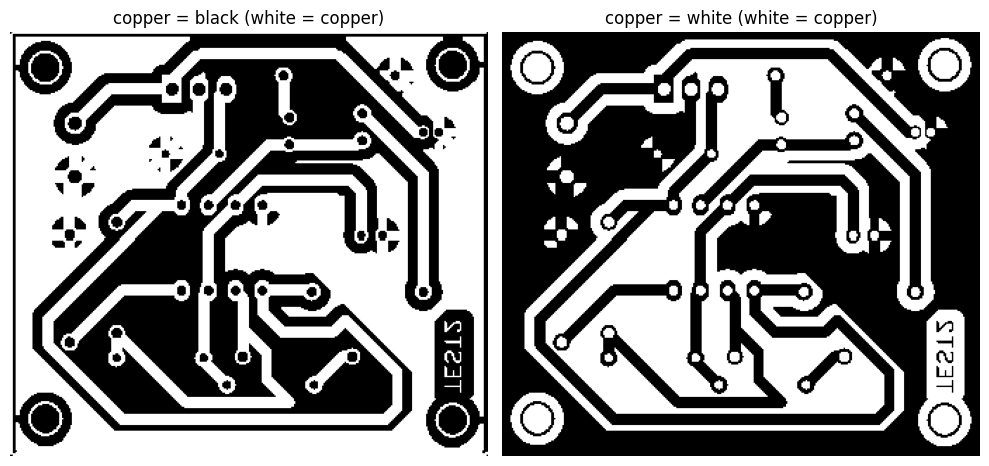

In [47]:
design = pc.load_design(DESIGN_PATH, copper=DESIGN_COPPER)
print("ตัดขอบ (x, y, w, h):", design["crop"])
show(*[v[1] * 255 for v in design["variants"]], titles=[f"copper = {v[0]} (white = copper)" for v in design["variants"]], size=5)

### C2 — สร้าง "mask จากโมเดล" จำลอง: ใส่ตำหนิ open 1 + short 1 + minor 2 จุด แล้ว **หมุน 137° + กลับซ้าย-ขวา + perspective**
(ตอนใช้งานจริง ขั้นนี้คือ mask ที่โมเดลของคุณทำนายออกมา)

ตำหนิที่ใส่ (พิกัดต้นแบบ 512 px):
   {'cls': 'open', 'kind': 'cut', 'bbox': [280, 401, 9, 29]}
   {'cls': 'short', 'kind': 'bridge', 'bbox': [256, 302, 14, 13]}
   {'cls': 'minor', 'kind': 'speck', 'bbox': [238, 93, 9, 7]}
   {'cls': 'minor', 'kind': 'speck', 'bbox': [362, 367, 7, 9]}


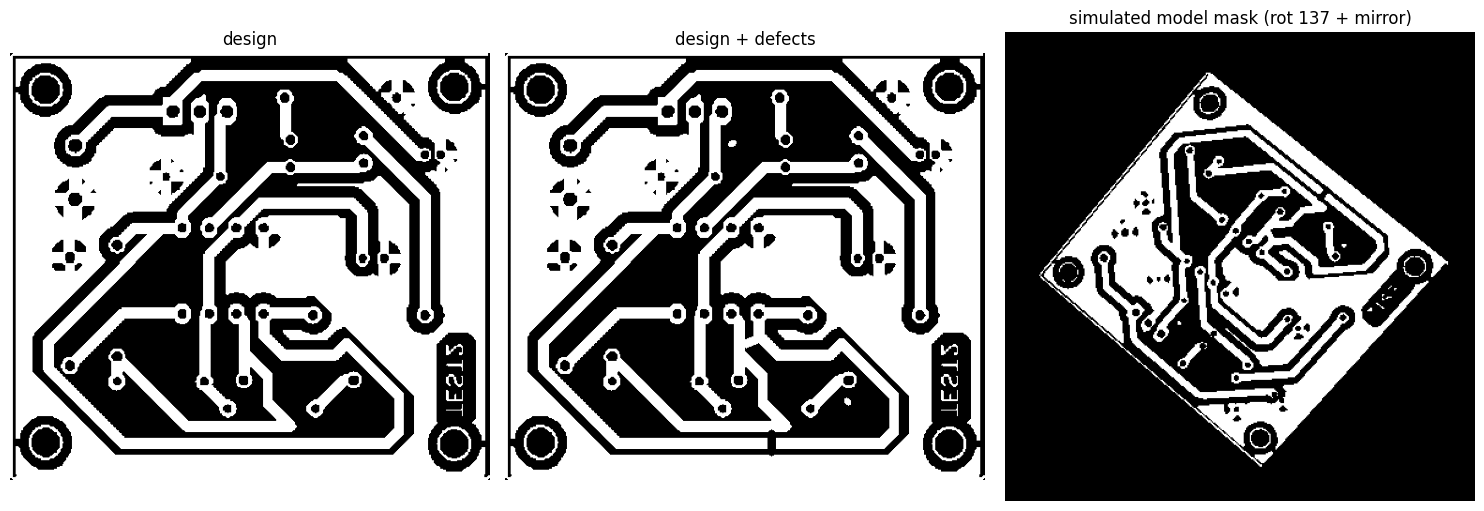

In [13]:
rng = np.random.default_rng(7)
pol0, dm0 = design["variants"][0]
base = pc.to_canon(dm0, 512)
OUT = 384                                                     # ขนาด mask (px)
D_defect, truth = sy.add_defects(base, rng, s_test=OUT * 0.85 / 512, n_open=1, n_short=1, n_minor=2)
demo_mask, A_true, s_true = sy.simulate_mask(D_defect, rng, out=OUT, fill=(0.85, 0.85), angle=137, flip=True)
print("ตำหนิที่ใส่ (พิกัดต้นแบบ 512 px):")
for t in truth:
    print("  ", t)
show(base * 255, D_defect * 255, demo_mask, titles=["design", "design + defects", "simulated model mask (rot 137 + mirror)"])

### C3 — จัดตำแหน่ง (หมุน/กลับด้าน/สเกลอัตโนมัติ)

  pol=black flip=True ang=140.0 coarse=0.967 → 0.989
→ polarity=black  angle=140.7°  mirrored=True  scale=0.4711  score=0.989  (3.637 s)
ความคลาดของมุมบอร์ด = 0.24 px (ใน mask)


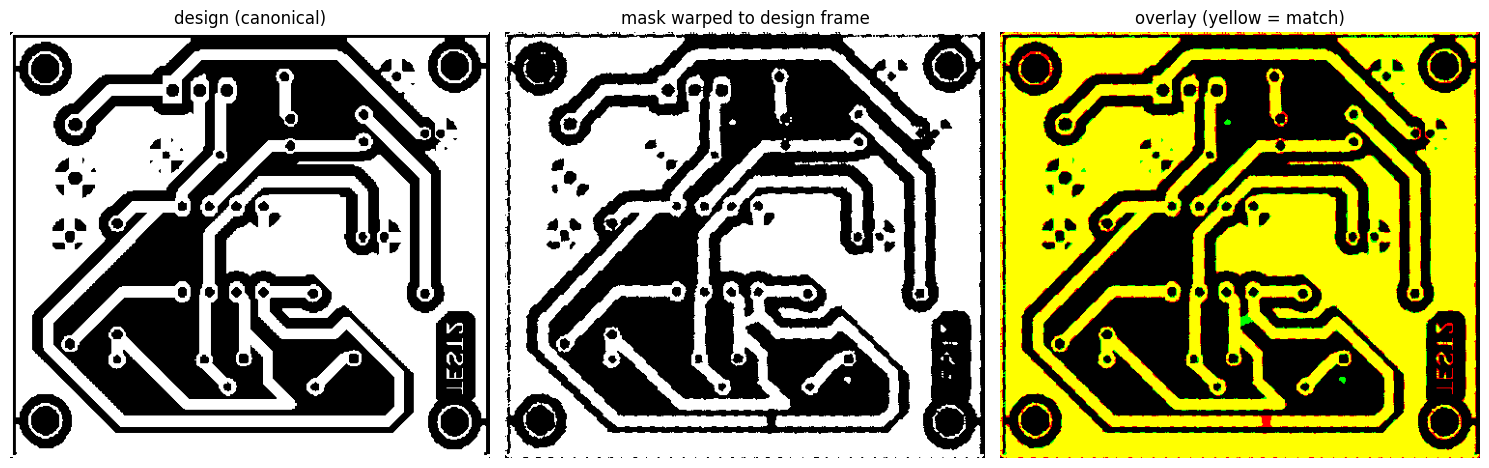

In [48]:
al = pc.align(design, pc.load_mask(demo_mask), verbose=True)
print(f"→ polarity={al['polarity']}  angle={al['angle']}°  mirrored={al['mirrored']}  scale={al['scale']}  "
      f"score={al['score']:.3f}  ({al['time_s']} s)")

# ตรวจความแม่น: เทียบมุมบอร์ดที่ระบบหาได้ กับคำตอบจริง
Dc = al["D"]
S = np.diag([base.shape[1] / Dc.shape[1], base.shape[0] / Dc.shape[0], 1])
H_, W_ = Dc.shape
corners = np.float64([[0, 0], [W_, 0], [W_, H_], [0, H_]])[None]
err = np.abs(cv2.perspectiveTransform(corners, A_true @ S) - cv2.perspectiveTransform(corners, al["A"])).max()
print(f"ความคลาดของมุมบอร์ด = {err:.2f} px (ใน mask)")

overlay = np.zeros(Dc.shape + (3,), np.uint8)
overlay[..., 2] = Dc * 255            # แดง = ต้นแบบ
overlay[..., 1] = al["Tc"] * 255      # เขียว = mask ที่ดัดแล้ว  → เหลือง = ซ้อนตรงกัน
show(Dc * 255, al["Tc"] * 255, overlay, titles=["design (canonical)", "mask warped to design frame", "overlay (yellow = match)"])

### C4 — หาจุดต่าง + จำแนก (ยังไม่มีโมเดล → ใช้กฎตั้งต้น)
กรอบสีขาวบาง = ตำแหน่งตำหนิจริง (เฉพาะ demo), กรอบสี = สิ่งที่ระบบเจอ (แดง open, ม่วง short, ส้ม minor, เทา normal)

verdict: FAIL {'open': 1, 'short': 1, 'minor': 1, 'normal': 4} | model: rule | warnings: ['LOW_RES: 11% ของบอร์ดมีช่องว่าง/ลายที่แคบเกินกว่าจะตรวจ open/short ได้ (ควร < 8%) — ควรใช้ mask ความละเอียดสูงขึ้น']
ความกว้างเส้นใน mask ≈ 3.96 px, tolerance = 3 px (canon)
  #0 normal bbox=[227, 85, 17, 16] nets_bridged=0 split=0 width_min=1.00 area_miss=0.00 area_extra=0.43
  #1 normal bbox=[236, 178, 12, 13] nets_bridged=1 split=0 width_min=0.36 area_miss=0.07 area_extra=0.00
  #2 short  bbox=[245, 288, 21, 21] nets_bridged=2 split=0 width_min=1.00 area_miss=0.00 area_extra=1.06
  #3 minor  bbox=[346, 352, 17, 17] nets_bridged=0 split=0 width_min=1.00 area_miss=0.00 area_extra=0.51
  #4 normal bbox=[183, 386, 13, 11] nets_bridged=1 split=0 width_min=1.00 area_miss=0.00 area_extra=0.00
  #5 normal bbox=[208, 386, 14, 11] nets_bridged=1 split=0 width_min=1.00 area_miss=0.00 area_extra=0.00
  #6 open   bbox=[262, 386, 25, 28] nets_bridged=1 split=1 width_min=0.00 area_miss=1.54 area_extra=0.00


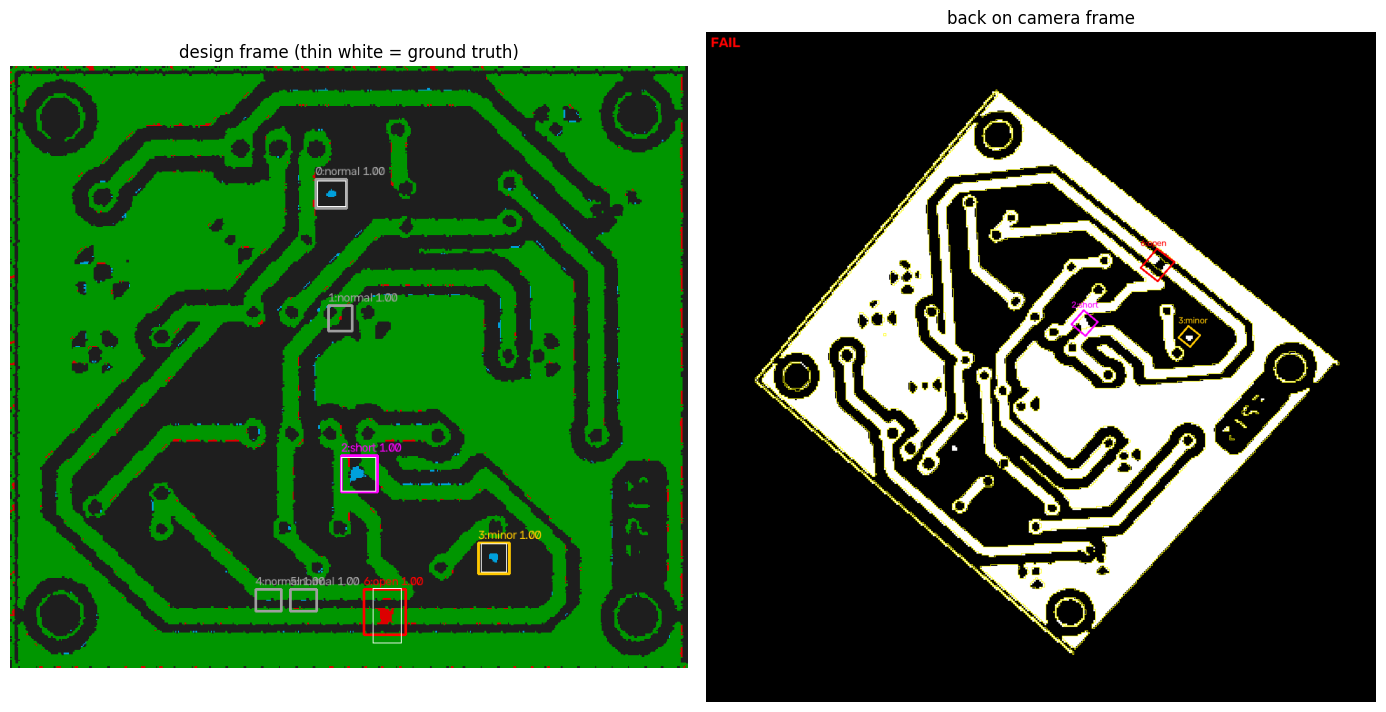

In [49]:
res0, ctx0 = pc.inspect(demo_mask, design)          # classifier=None → ใช้กฎ
print("verdict:", res0["verdict"], res0["counts"], "| model:", res0["model"], "| warnings:", res0["warnings"])
print(f"ความกว้างเส้นใน mask ≈ {res0['trace_width_mask_px']} px, tolerance = {res0['tol_px']} px (canon)")
for i, d in enumerate(res0["defects"]):
    f = d["features"]
    print(f"  #{i} {d['cls']:6s} bbox={d['bbox']} nets_bridged={f['nets_bridged_local']:.0f} split={f['split_local']:.0f} "
          f"width_min={f['width_min']:.2f} area_miss={f['area_miss']:.2f} area_extra={f['area_extra']:.2f}")

vis = pc.draw_canon(res0, ctx0, show_normal=True)
for g in sy.gt_to_canon(truth, base.shape, ctx0["cmp"].D.shape):
    x, y, w, h = [int(round(v * 1.5)) for v in g["bbox"]]
    cv2.rectangle(vis, (x - 9, y - 9), (x + w + 9, y + h + 9), (255, 255, 255), 1)
show(vis, pc.draw_on_mask(res0, ctx0), titles=["design frame (thin white = ground truth)", "back on camera frame"], size=7)

---
# ส่วน D — เทรน AI จำแนกตำหนิ (รอบแรกด้วยข้อมูลจำลอง)
- ใช้ **ไฟล์ต้นแบบของคุณ + ลายสุ่ม 3 แบบ** (ให้โมเดลไม่ยึดติดกับลายเดียว) × ความละเอียด mask 256–512 px
- ทุกจุดที่ระบบเจอ ถูกจับคู่กับตำหนิจริง → label อัตโนมัติ (จุดที่ไม่ตรงกับตำหนิใด = `normal`)
- ข้อมูลถูกเก็บไว้ที่ `SYNTH_CACHE` (รันซ้ำไม่ต้องสร้างใหม่ — ลบไฟล์ถ้าต้องการสร้างใหม่)

⏱️ ~2 วินาที/บอร์ดบน PC, ~5 วินาที/บอร์ดบน Pi 5 → 150 บอร์ด ≈ 5 นาที (PC) / 12 นาที (Pi) *(สร้างบน PC แล้วคัดลอกไฟล์ไป Pi ก็ได้)*

In [5]:
import joblib

def synth_designs():
    ds = [("user_design", design if DESIGN_COPPER != "auto" else dict(design, variants=[(al["polarity"], dict(design["variants"])[al["polarity"]])]))]
    for k in range(3):
        d = sy.make_trace_design(10 + k)
        ds.append((f"random_{k}", dict(variants=[("white", d)], crop=None)))
    return ds

if os.path.exists(SYNTH_CACHE):
    X_syn, y_syn, meta_syn, stat_syn = joblib.load(SYNTH_CACHE)
    print("โหลดข้อมูลจำลองจาก cache:", SYNTH_CACHE)
else:
    t0 = time.time()
    X_syn, y_syn, meta_syn, stat_syn = sy.make_training_set(synth_designs(), N_SYNTH_BOARDS, seed=0)
    joblib.dump((X_syn, y_syn, meta_syn, stat_syn), SYNTH_CACHE)
    print(f"สร้างเสร็จใน {time.time() - t0:.0f} s")
print("จำนวนตัวอย่าง:", {c: int((y_syn == c).sum()) for c in pc.CLASSES})
print("อัตราที่ระบบหาตำหนิเจอ (detection recall):",
      {k: f"{v[1]}/{v[0]} = {v[1] / max(1, v[0]):.0%}" for k, v in stat_syn.items()})

โหลดข้อมูลจำลองจาก cache: models/synth_dataset.joblib
จำนวนตัวอย่าง: {'open': 153, 'short': 148, 'minor': 152, 'normal': 168}
อัตราที่ระบบหาตำหนิเจอ (detection recall): {'open': '153/154 = 99%', 'short': '145/145 = 100%', 'minor': '152/217 = 70%'}


### D2 — เทรน + ประเมินผล (แบ่งตามบอร์ด: บอร์ดที่ใช้ทดสอบไม่เคยถูกใช้เทรน)

=== AI (RandomForest) ===
              precision    recall  f1-score   support

        open      0.971     1.000     0.986        34
       short      1.000     0.968     0.984        31
       minor      0.933     0.966     0.949        29
      normal      0.952     0.909     0.930        22

    accuracy                          0.966       116
   macro avg      0.964     0.961     0.962       116
weighted avg      0.966     0.966     0.965       116

=== กฎตั้งต้น (เทียบ) ===
              precision    recall  f1-score   support

        open      0.816     0.912     0.861        34
       short      0.960     0.774     0.857        31
       minor      0.378     0.483     0.424        29
      normal      0.312     0.227     0.263        22

    accuracy                          0.638       116
   macro avg      0.617     0.599     0.601       116
weighted avg      0.650     0.638     0.637       116

critical_thr=None: recall {'open': '100%', 'short': '97%', 'minor': '97%', 'no

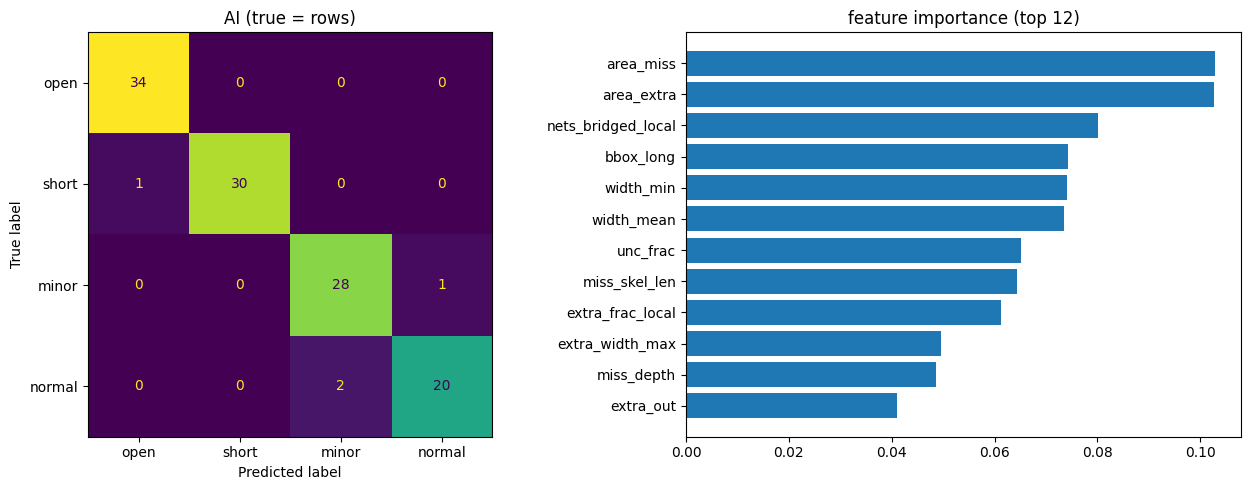

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

boards = np.array([m["board"] for m in meta_syn])
test_mask = boards % 5 == 0                                   # 20% ของบอร์ดไว้ทดสอบ
clf_eval = pc.DefectClassifier().fit(X_syn[~test_mask], y_syn[~test_mask])
pred = clf_eval.model.predict(X_syn[test_mask])
rule = np.array([m["rule"] for m in meta_syn])[test_mask]
print("=== AI (RandomForest) ===")
print(classification_report(y_syn[test_mask], pred, labels=pc.CLASSES, digits=3, zero_division=0))
print("=== กฎตั้งต้น (เทียบ) ===")
print(classification_report(y_syn[test_mask], rule, labels=pc.CLASSES, digits=3, zero_division=0))

# ผลของ critical_thr (ตอบ open/short ถ้าความน่าจะเป็น ≥ ค่านี้) — ค่าต่ำ = ไม่พลาดตำหนิร้ายแรง แต่เตือนเกินมากขึ้น
feats_te = [dict(zip(pc.FEATURE_NAMES, x)) for x in X_syn[test_mask]]
for thr in (None, 0.35, 0.25, 0.15):
    lab_t, _, _ = clf_eval.predict(X_syn[test_mask], feats_te, critical_thr=thr)
    cm = confusion_matrix(y_syn[test_mask], lab_t, labels=pc.CLASSES)
    rec = {c: f"{cm[i, i] / max(1, cm[i].sum()):.0%}" for i, c in enumerate(pc.CLASSES)}
    print(f"critical_thr={thr}: recall {rec} | normal/minor ถูกทายเป็น open/short = {cm[2:, :2].sum()} จุด")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(y_syn[test_mask], pred, labels=pc.CLASSES), display_labels=pc.CLASSES).plot(ax=ax[0], colorbar=False)
ax[0].set_title("AI (true = rows)")
imp = clf_eval.model.feature_importances_
o = np.argsort(imp)[::-1][:12]
ax[1].barh([pc.FEATURE_NAMES[i] for i in o][::-1], imp[o][::-1]); ax[1].set_title("feature importance (top 12)")
plt.tight_layout(); plt.show()

### D3 — เทรนด้วยข้อมูลทั้งหมด + บันทึกโมเดล

บันทึก models/defect_rf.joblib 0.5 MB
demo ด้วย AI: FAIL {'open': 1, 'short': 1, 'minor': 2, 'normal': 3}
  #0 minor  prob=0.94  (กฎ: normal)  probs={'minor': 0.943, 'normal': 0.032, 'open': 0.002, 'short': 0.023}
  #1 normal prob=0.95  (กฎ: normal)  probs={'minor': 0.043, 'normal': 0.952, 'open': 0.001, 'short': 0.004}
  #2 short  prob=0.90  (กฎ: short)  probs={'minor': 0.086, 'normal': 0.015, 'open': 0.0, 'short': 0.899}
  #3 minor  prob=0.94  (กฎ: minor)  probs={'minor': 0.94, 'normal': 0.059, 'open': 0.0, 'short': 0.001}
  #4 normal prob=0.93  (กฎ: normal)  probs={'minor': 0.055, 'normal': 0.934, 'open': 0.0, 'short': 0.011}
  #5 normal prob=0.90  (กฎ: normal)  probs={'minor': 0.087, 'normal': 0.898, 'open': 0.0, 'short': 0.015}
  #6 open   prob=0.99  (กฎ: open)  probs={'minor': 0.004, 'normal': 0.0, 'open': 0.988, 'short': 0.008}


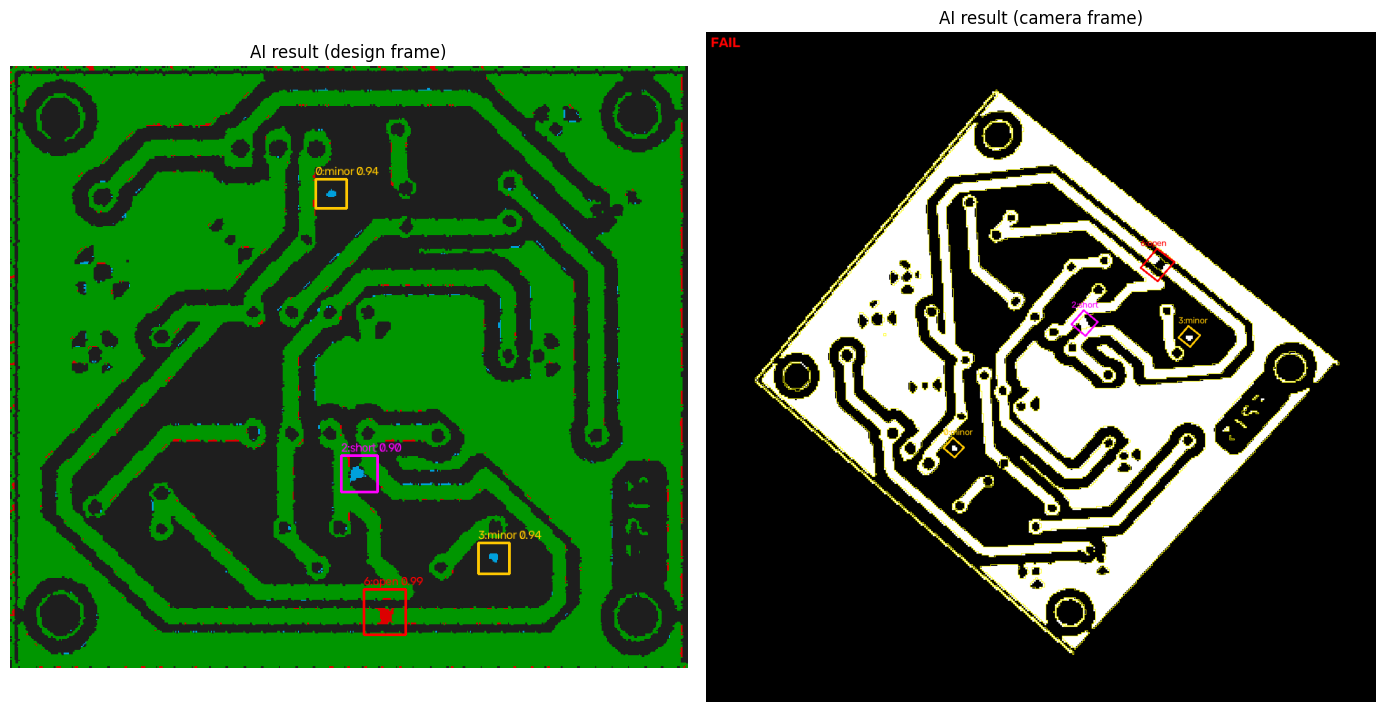

In [52]:
clf = pc.DefectClassifier(meta=dict(trained=time.strftime("%Y-%m-%d %H:%M"), n_synth=int(len(y_syn)), n_real=0))
clf.fit(X_syn, y_syn)
clf.save(MODEL_PATH)
print("บันทึก", MODEL_PATH, f"{os.path.getsize(MODEL_PATH) / 1e6:.1f} MB")

res1, ctx1 = pc.inspect(demo_mask, design, classifier=clf)
print("demo ด้วย AI:", res1["verdict"], {k: v for k, v in res1["counts"].items() if v})
for i, d in enumerate(res1["defects"]):
    print(f"  #{i} {d['cls']:6s} prob={d['prob']:.2f}  (กฎ: {d['rule']})  probs={d['probs']}")
show(pc.draw_canon(res1, ctx1), pc.draw_on_mask(res1, ctx1), titles=["AI result (design frame)", "AI result (camera frame)"], size=7)

---
# ส่วน E — ตรวจของจริง
### E1 — ตรวจ 1 แผ่น: mask จากโมเดลของคุณ + ไฟล์ต้นแบบ (+ ภาพถ่าย)

📦 โหลดต้นแบบจริง 4 แบบจาก ../train_ai_pcb/dataset_v4/real-pcb: ['test1', 'test2', 'test3', 'test4']
🎯 ต้นแบบที่จับคู่ได้: test4
VERDICT: FAIL   {'open': 18, 'short': 3, 'minor': 15}
จัดตำแหน่ง: มุม 355.1°, mirror=True, สเกล 0.5036, ทองแดงต้นแบบ=black, คะแนนซ้อน 0.935  | เวลา 5.828 s
⚠️ LOW_RES: 14% ของบอร์ดมีช่องว่าง/ลายที่แคบเกินกว่าจะตรวจ open/short ได้ (ควร < 8%) — ควรใช้ mask ความละเอียดสูงขึ้น
  #0 open   prob=0.94 ตำแหน่งใน mask = [[193.0, 36.0], [182.0, 35.0], [182.0, 47.0], [193.0, 48.0]]
  #2 minor  prob=0.54 ตำแหน่งใน mask = [[151.0, 37.0], [140.0, 36.0], [140.0, 44.0], [151.0, 45.0]]
  #3 minor  prob=0.57 ตำแหน่งใน mask = [[80.0, 33.0], [72.0, 32.0], [72.0, 44.0], [80.0, 45.0]]
  #6 open   prob=0.70 ตำแหน่งใน mask = [[215.0, 51.0], [197.0, 50.0], [197.0, 70.0], [216.0, 71.0]]
  #7 minor  prob=0.48 ตำแหน่งใน mask = [[184.0, 55.0], [176.0, 54.0], [176.0, 69.0], [184.0, 70.0]]
  #9 minor  prob=0.51 ตำแหน่งใน mask = [[112.0, 59.0], [105.0, 58.0], [105.0, 66.0], [112.0, 66.0]]
  

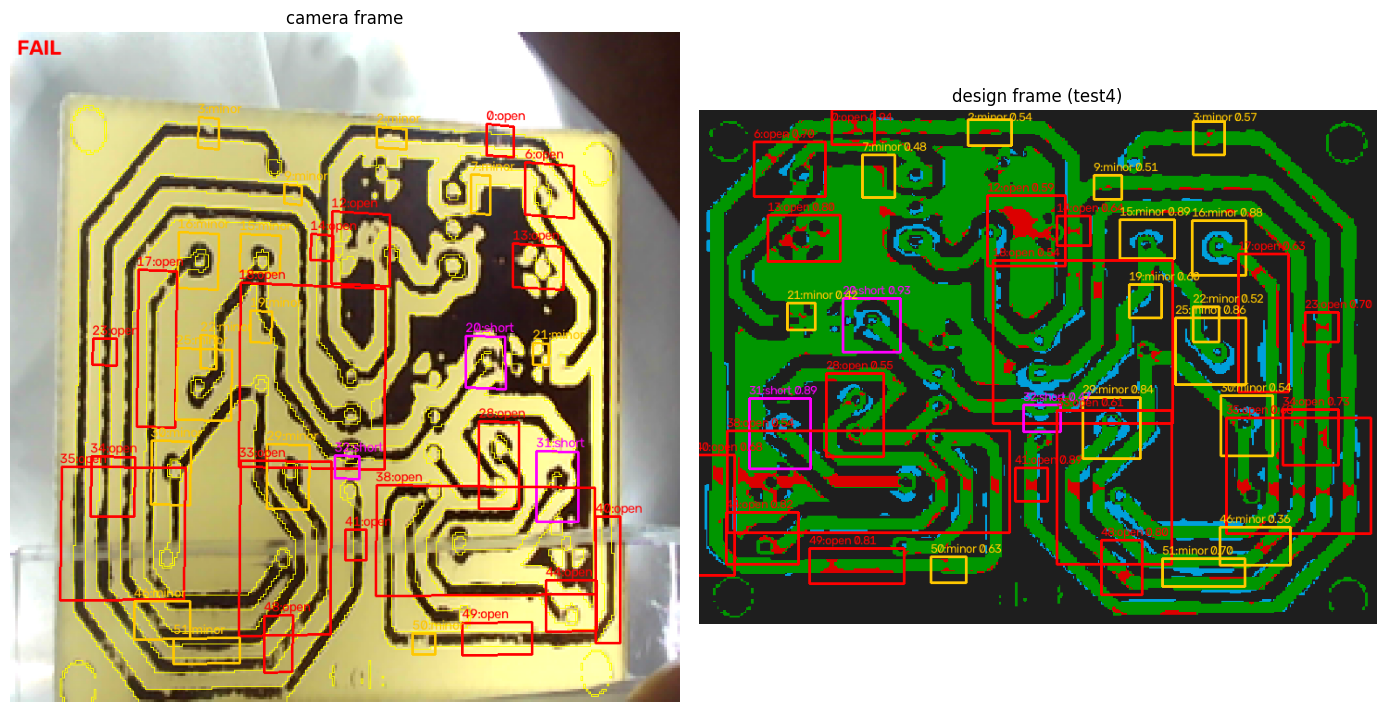

เก็บ 53 จุดไว้ label ที่ label_data/


In [53]:
clf = pc.DefectClassifier.load(MODEL_PATH) if os.path.exists(MODEL_PATH) else pc.DefectClassifier()

# โหลดไฟล์ต้นแบบทั้งหมดที่มี (test1..test4 จาก real-pcb หรือ TEST1.png)
DESIGNS = {}
if os.path.exists(DESIGN_DIR):
    for p in sorted(glob.glob(os.path.join(DESIGN_DIR, "*.png"))):
        dname = os.path.splitext(os.path.basename(p))[0]
        DESIGNS[dname] = pc.load_design(p, copper=DESIGN_COPPER)
    print(f"📦 โหลดต้นแบบจริง {len(DESIGNS)} แบบจาก {DESIGN_DIR}: {list(DESIGNS.keys())}")
elif os.path.exists(DESIGN_PATH):
    DESIGNS["TEST1"] = pc.load_design(DESIGN_PATH, copper=DESIGN_COPPER)

if os.path.exists(MASK_PATH):
    photo = cv2.imread(PHOTO_PATH) if os.path.exists(PHOTO_PATH) else None
    # ส่ง DESIGNS ให้ระบบจับคู่ต้นแบบที่ตรงที่สุดโดยอัตโนมัติ (Zero-Shot Template Matching)
    result, ctx = pc.inspect(MASK_PATH, DESIGNS, classifier=clf, photo=photo, copper=DESIGN_COPPER)
    a = result["align"]
    print(f"🎯 ต้นแบบที่จับคู่ได้: {result.get('matched_design', 'N/A')}")
    print(f"VERDICT: {result['verdict']}   {dict((k, v) for k, v in result['counts'].items() if k != 'normal')}")
    print(f"จัดตำแหน่ง: มุม {a['angle']}°, mirror={a['mirrored']}, สเกล {a['scale']}, ทองแดงต้นแบบ={a['polarity']}, "
          f"คะแนนซ้อน {a['score']:.3f}  | เวลา {result['time_s']} s")
    for w in result["warnings"]:
        print("⚠️", w)
    for i, d in enumerate(result["defects"]):
        if d["cls"] != "normal":
            print(f"  #{i} {d['cls']:6s} prob={d['prob']:.2f} ตำแหน่งใน mask = {np.round(d['poly_mask'], 0).tolist()}")
    # แสดงผล 3 มุมมอง: มุมกล้องเดิม | มุมมองหมุน/เลื่อนตรงกับ Template (Aligned) | ผลลัพธ์เชิงเปรียบเทียบ
    vis_aligned = pc.draw_aligned(result, ctx)
    show(pc.draw_on_mask(result, ctx), vis_aligned, pc.draw_canon(result, ctx),
         titles=["1. Camera Frame (มุมกล้องเดิม)", "2. Aligned Photo (หมุน/เลื่อนตรงกับ Template)", f"3. Defect Analysis ({result.get('matched_design', '')})"] , size=6)
    with open("last_result.json", "w", encoding="utf-8") as f:
        json.dump(pc.result_to_json(result), f, ensure_ascii=False, indent=1)
    ids = pc.save_candidates(result, ctx, LABEL_DIR, source=os.path.splitext(os.path.basename(MASK_PATH))[0])
    print(f"เก็บ {len(ids)} จุดไว้ label ที่ {LABEL_DIR}/")
else:
    print("ℹ️ ไม่พบ", MASK_PATH, "— แก้ MASK_PATH ใน cell ตั้งค่า")


### E2 — ตรวจทั้งโฟลเดอร์ (เช่น `train_ai_pcb/dataset/masks/*.png` คู่กับ `images/` ชื่อเดียวกัน)
บันทึกภาพผลใน `results/`, สรุปใน `results/summary.csv`, และเก็บทุกจุดไว้ label

In [54]:
MASK_DIR = _resolve_path("train_ai_pcb/dataset_v4/masks")
PHOTO_DIR = _resolve_path("train_ai_pcb/dataset_v4/images")
MAX_FILES = 20
os.makedirs("results", exist_ok=True)

# ตรวจสอบและโหลดต้นแบบทั้งหมด (test1..test4 จาก real-pcb)
if 'DESIGNS' not in globals() or not DESIGNS:
    DESIGNS = {}
    if os.path.exists(DESIGN_DIR):
        for p in sorted(glob.glob(os.path.join(DESIGN_DIR, "*.png"))):
            dname = os.path.splitext(os.path.basename(p))[0]
            DESIGNS[dname] = pc.load_design(p, copper=DESIGN_COPPER)
    elif os.path.exists(DESIGN_PATH):
        DESIGNS["TEST1"] = pc.load_design(DESIGN_PATH, copper=DESIGN_COPPER)

rows = []
mask_files = sorted(glob.glob(os.path.join(MASK_DIR, "*.png")))[:MAX_FILES]
print(f"กำลังตรวจทั้งหมด {len(mask_files)} แผ่น เทียบกับต้นแบบ {list(DESIGNS.keys())}...")

for mp in mask_files:
    name = os.path.splitext(os.path.basename(mp))[0]
    pp = os.path.join(PHOTO_DIR, name + ".png")
    try:
        # ระบบจะจับคู่ต้นแบบที่ถูกต้องให้อัตโนมัติ (Zero-Shot Template Comparison)
        r, cx = pc.inspect(mp, DESIGNS, classifier=clf, photo=cv2.imread(pp) if os.path.exists(pp) else None)
    except Exception as e:
        print(name, "ERROR", e); continue
    cv2.imwrite(f"results/{name}_{r['verdict']}.jpg", pc.draw_on_mask(r, cx))
    pc.save_candidates(r, cx, LABEL_DIR, source=name)
    rows.append([name, r.get("matched_design", "-"), r["verdict"], r["counts"]["open"], r["counts"]["short"], r["counts"]["minor"],
                 r["align"]["score"], r["align"]["angle"], r["align"]["mirrored"], r["time_s"], " | ".join(r["warnings"])])
    print(f"{name}: design={rows[-1][1]:5s} {r['verdict']:8s} open={rows[-1][3]} short={rows[-1][4]} minor={rows[-1][5]} score={r['align']['score']:.3f} ({r['time_s']} s)")

if rows:
    import csv
    with open("results/summary.csv", "w", newline="", encoding="utf-8-sig") as f:
        w = csv.writer(f)
        w.writerow(["file", "matched_design", "verdict", "open", "short", "minor", "align_score", "angle", "mirrored", "time_s", "warnings"])
        w.writerows(rows)
    print("→ บันทึกผลสรุปที่ results/summary.csv สำเร็จ ✅")
else:
    print("ℹ️ ไม่พบไฟล์ใน", MASK_DIR)


กำลังตรวจทั้งหมด 20 แผ่น เทียบกับต้นแบบ ['test1', 'test2', 'test3', 'test4']...
pcb_0001: design=test4 FAIL     open=18 short=3 minor=15 score=0.935 (5.719 s)
pcb_0002: design=test4 FAIL     open=16 short=3 minor=9 score=0.932 (5.665 s)
pcb_0003: design=test4 FAIL     open=23 short=3 minor=7 score=0.919 (27.479 s)
pcb_0004: design=test4 FAIL     open=15 short=4 minor=5 score=0.919 (20.789 s)
pcb_0005: design=test4 FAIL     open=16 short=2 minor=10 score=0.922 (5.641 s)
pcb_0006: design=test4 FAIL     open=22 short=1 minor=10 score=0.920 (20.612 s)
pcb_0007: design=test4 FAIL     open=11 short=3 minor=4 score=0.920 (5.561 s)
pcb_0008: design=test4 FAIL     open=17 short=2 minor=3 score=0.920 (22.755 s)
pcb_0009: design=test4 FAIL     open=18 short=4 minor=7 score=0.917 (19.376 s)
pcb_0010: design=test4 FAIL     open=16 short=2 minor=6 score=0.919 (18.398 s)
pcb_0011: design=test2 FAIL     open=10 short=0 minor=3 score=0.943 (4.681 s)
pcb_0012: design=test2 FAIL     open=8 short=0 minor=

---
# ส่วน F — Label เอง แล้วเทรน AI ซ้ำ (หัวใจของความแม่นบนบอร์ดจริง)
ทุกครั้งที่ตรวจ (E1, E2 หรือผ่าน API) จุดที่เจอจะถูกเก็บไว้ใน `label_data/` → คุณกดเลือกคลาสให้ → เทรนใหม่ → แม่นขึ้นเรื่อยๆ

**แนวทาง label:**
| กด | เมื่อ |
|---|---|
| `open` | ลายขาดจริง ไฟไม่ต่อ |
| `short` | ทองแดงเชื่อมสองเส้นที่ไม่ควรต่อกัน |
| `minor` | แหว่ง/ปุ่มยื่น/รูเล็ก/เศษทองแดง ที่ยังใช้งานได้ แต่ควรแจ้ง |
| `normal` | ไม่ใช่ตำหนิจริง (mask ไม่เนียน, แสงสะท้อน, ขอบบอร์ด) |
| `skip` | ไม่แน่ใจ — ไม่นำไปเทรน |

ภาพแต่ละจุด: **[ต้นแบบ | mask | ความต่าง (เขียว=ตรง, แดง=หาย, ฟ้า=เกิน, ขอบขาว=จุดที่ถาม) | ตำแหน่งบนบอร์ด]**
> 💡 เทียบกับภาพถ่ายจริงใน `results/` ด้วย — ถ้า mask ผิดแต่บอร์ดดี ให้กด `normal`

### F1 — หน้าจอ label ใน notebook (ipywidgets)

In [1]:
import os, sys
import ipywidgets as W
from IPython.display import display

if "pc" not in globals():
    try:
        import pcb_compare as pc
    except ImportError:
        sys.path.insert(0, ".")
        import pcb_compare as pc

LABEL_DIR = globals().get("LABEL_DIR", "label_data")
ONLY_UNLABELED = True
LABEL_BUTTONS = pc.CLASSES + ["skip"]


def build_labeler(label_dir=LABEL_DIR, min_align=0.8):
    cands = pc.read_candidates(label_dir)
    # กรองเฉพาะจุดจากบอร์ดที่ align ผ่านจริง (align_score >= 0.8) เพื่อไม่ให้แสดงภาพที่ไม่ตรงลาย
    cands = [c for c in cands if len(c.get("x", [])) <= 18 or c["x"][18] >= min_align]
    labels = pc.read_labels(label_dir)
    todo = [c for c in cands if (c["id"] not in labels) or not ONLY_UNLABELED]
    state = {"i": 0}
    img = W.Image(format="png", width=760)
    info = W.HTML()
    prog = W.HTML()

    def refresh():
        labels_now = pc.read_labels(label_dir)
        done = sum(1 for c in cands if c["id"] in labels_now)
        prog.value = f"<b>label แล้ว {done}/{len(cands)}</b> | คิวนี้ {min(state['i'] + 1, len(todo))}/{len(todo)}"
        if state["i"] >= len(todo):
            info.value = "<h3>✅ label ครบคิวแล้ว — ไปเทรนที่ F3</h3>"
            img.value = b""
            return
        c = todo[state["i"]]
        p = os.path.join(label_dir, "crops", c["id"] + ".png")
        img.value = open(p, "rb").read() if os.path.exists(p) else b""
        cur = labels_now.get(c["id"], "-")
        info.value = (f"<code>{c['id']}</code><br>AI ทาย: <b>{c['pred']}</b> ({c['prob']:.2f}) · กฎ: {c['rule']} · "
                      f"label ปัจจุบัน: <b>{cur}</b>")

    def on_label(b):
        if state["i"] < len(todo):
            pc.set_label(todo[state["i"]]["id"], b.description, label_dir)
            state["i"] += 1
        refresh()

    def on_back(b):
        state["i"] = max(0, state["i"] - 1)
        refresh()

    colors = {"open": "danger", "short": "warning", "minor": "info", "normal": "success", "skip": ""}
    btns = [W.Button(description=k, button_style=colors.get(k, "")) for k in LABEL_BUTTONS]
    for b in btns:
        b.on_click(on_label)
    back = W.Button(description="◀ ย้อน", icon="arrow-left")
    back.on_click(on_back)
    refresh()
    return W.VBox([prog, img, info, W.HBox(btns + [back])]), todo


labeler, _todo = build_labeler()
print(f"จุดที่รอ label: {len(_todo)}")
display(labeler)


จุดที่รอ label: 1082


### F2 — (ทางเลือก) หน้าต่าง OpenCV สำหรับ Raspberry Pi desktop
ปุ่ม: `1`=open `2`=short `3`=minor `4`=normal `s`=skip `b`=ย้อน `q`=ออก — ตั้ง `USE_OPENCV_LABELER = True` แล้วรัน

In [ ]:
USE_OPENCV_LABELER = True  # True → ใช้ OpenCV GUI (F1/F2/F3/F4/S/B/Q) / False → ใช้ ipywidgets GUI


def label_with_opencv(label_dir=LABEL_DIR):
    keys = {ord("1"): "open", ord("2"): "short", ord("3"): "minor", ord("4"): "normal", ord("s"): "skip"}
    labels = pc.read_labels(label_dir)
    todo = [c for c in pc.read_candidates(label_dir) if c["id"] not in labels]
    i = 0
    cv2.namedWindow("label", cv2.WINDOW_NORMAL)
    while 0 <= i < len(todo):
        c = todo[i]
        im = cv2.imread(os.path.join(label_dir, "crops", c["id"] + ".png"))
        bar = np.zeros((40, im.shape[1], 3), np.uint8)
        cv2.putText(bar, f"[{i + 1}/{len(todo)}] AI:{c['pred']} {c['prob']:.2f} | 1 open 2 short 3 minor 4 normal s skip b back q quit",
                    (6, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
        cv2.imshow("label", np.vstack([bar, im]))
        k = cv2.waitKey(0) & 0xFF
        if k in (ord("q"), 27):
            break
        if k == ord("b"):
            i = max(0, i - 1)
        elif k in keys:
            pc.set_label(c["id"], keys[k], label_dir)
            i += 1
    cv2.destroyAllWindows()
    print("label แล้วทั้งหมด:", len(pc.read_labels(label_dir)))


if USE_OPENCV_LABELER:
    label_with_opencv()

### F3 — เทรนใหม่ = ข้อมูลจำลอง + ข้อมูลจริงที่คุณ label (ให้น้ำหนักข้อมูลจริงมากกว่า `REAL_WEIGHT` เท่า)
ถ้ามี label จริง ≥ 20 จุด จะประเมินด้วย cross-validation **บนข้อมูลจริง** (ตัวเลขนี้คือความแม่นที่คาดหวังบนบอร์ดจริง)

In [8]:
from sklearn.model_selection import StratifiedKFold

X_real, y_real, real_ids = pc.load_labeled(LABEL_DIR)
print("label จริง:", {c: int((y_real == c).sum()) for c in pc.CLASSES}, "| รวม", len(y_real))

if len(y_real) >= 20 and len(set(y_real)) >= 2:
    n_split = int(min(5, np.bincount(np.unique(y_real, return_inverse=True)[1]).min()))
    if n_split >= 2:
        pred_cv = np.empty(len(y_real), dtype=object)
        for tr, te in StratifiedKFold(n_split, shuffle=True, random_state=0).split(X_real, y_real):
            Xtr = np.vstack([X_syn, X_real[tr]]); ytr = np.concatenate([y_syn, y_real[tr]])
            wtr = np.concatenate([np.ones(len(y_syn)), np.full(len(tr), REAL_WEIGHT)])
            pred_cv[te] = pc.DefectClassifier().fit(Xtr, ytr, sample_weight=wtr).model.predict(X_real[te])
        print(f"=== cross-validation บนข้อมูลจริง ({n_split} folds) ===")
        print(classification_report(y_real, pred_cv.astype(str), labels=pc.CLASSES, digits=3, zero_division=0))
    else:
        print("ℹ️ บางคลาสมีตัวอย่างน้อยเกินไปสำหรับ cross-validation")
else:
    print("ℹ️ label เพิ่มอีกหน่อย (≥ 20 จุด) เพื่อดูความแม่นบนข้อมูลจริง")

X_all = np.vstack([X_syn, X_real]) if len(y_real) else X_syn
y_all = np.concatenate([y_syn, y_real]) if len(y_real) else y_syn
w_all = np.concatenate([np.ones(len(y_syn)), np.full(len(y_real), REAL_WEIGHT)])
clf = pc.DefectClassifier(meta=dict(trained=time.strftime("%Y-%m-%d %H:%M"), n_synth=int(len(y_syn)), n_real=int(len(y_real))))
clf.fit(X_all, y_all, sample_weight=w_all)
clf.save(MODEL_PATH)
print("✅ บันทึกโมเดลใหม่ →", MODEL_PATH, clf.meta, "  (API: เรียก POST /reload_model)")

label จริง: {'open': 53, 'short': 4, 'minor': 14, 'normal': 197} | รวม 268
=== cross-validation บนข้อมูลจริง (4 folds) ===
              precision    recall  f1-score   support

        open      0.660     0.623     0.641        53
       short      0.167     0.250     0.200         4
       minor      0.600     0.214     0.316        14
      normal      0.850     0.893     0.871       197

    accuracy                          0.795       268
   macro avg      0.569     0.495     0.507       268
weighted avg      0.789     0.795     0.787       268

✅ บันทึกโมเดลใหม่ → models/defect_rf.joblib {'trained': '2026-09-21 00:11', 'n_synth': 621, 'n_real': 268}   (API: เรียก POST /reload_model)


---
# ส่วน G — FastAPI บน Raspberry Pi 5
คัดลอก `pcb_compare.py`, `compare_api.py`, `models/defect_rf.joblib` ไปไว้โฟลเดอร์เดียวกันบน Pi แล้วรัน
```bash
uvicorn compare_api:app --host 0.0.0.0 --port 8001 --workers 1
```
| Endpoint | ใช้ทำอะไร |
|---|---|
| `POST /design/{name}` | อัปโหลดไฟล์ต้นแบบเก็บไว้ (ครั้งเดียวต่อแบบลาย) |
| `POST /inspect` | ส่ง `mask` (+ `design` ไฟล์ หรือ `design_name`) (+ `photo`) → JSON ผลตรวจ + ภาพผล (base64) + เก็บจุดไว้ label |
| `POST /reload_model` | โหลดโมเดลใหม่หลังเทรนซ้ำ (F3) |
| `GET /health` | สถานะ |

ต่อจาก API แยกทองแดงเดิมของคุณได้เลย: ได้ mask แล้วส่งต่อมาที่ `/inspect` (รันคนละ port หรือรวม router เดียวกันก็ได้)

In [ ]:
"""
compare_api.py — FastAPI สำหรับเปรียบเทียบลายทองแดงกับไฟล์ต้นแบบ (รันบน Raspberry Pi 5)
รัน:  uvicorn compare_api:app --host 0.0.0.0 --port 8001 --workers 1
เปิด  http://<ip-ของ-pi>:8001/docs  เพื่อทดสอบผ่านหน้าเว็บ

ลำดับการใช้งาน
  1) โมเดลแยกทองแดงของคุณทำนาย mask เสร็จ (ขาว = ทองแดง)
  2) POST /inspect  ส่ง mask + ไฟล์ต้นแบบ (หรือชื่อต้นแบบที่อัปโหลดไว้ด้วย POST /design/{name})
     + ภาพถ่าย (ไม่บังคับ ใช้วาดผล)  → ได้ JSON: verdict, รายการตำหนิ (open/short/minor) + ตำแหน่ง + ภาพผล
"""
import os
import time
import base64
from typing import Optional

import cv2
import numpy as np
from fastapi import FastAPI, UploadFile, File, Form, HTTPException

import pcb_compare as pc

MODEL_PATH = os.getenv("DEFECT_MODEL", "models/defect_rf.joblib")
DESIGN_DIR = os.getenv("DESIGN_DIR", "designs")
RESULT_DIR = os.getenv("RESULT_DIR", "results")
LABEL_DIR = os.getenv("LABEL_DIR", "label_data")
os.makedirs(DESIGN_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

app = FastAPI(title="PCB Design Compare")
CLF = pc.DefectClassifier.load(MODEL_PATH) if os.path.exists(MODEL_PATH) else pc.DefectClassifier()
DESIGN_CACHE = {}


def _decode(upload: UploadFile, flags=cv2.IMREAD_UNCHANGED):
    data = np.frombuffer(upload.file.read(), np.uint8)
    img = cv2.imdecode(data, flags)
    if img is None:
        raise HTTPException(400, f"อ่านไฟล์ภาพไม่ได้: {upload.filename}")
    return img


def _b64(img, ext=".jpg"):
    ok, enc = cv2.imencode(ext, img, [cv2.IMWRITE_JPEG_QUALITY, 88] if ext == ".jpg" else [])
    return base64.b64encode(enc.tobytes()).decode()


def _get_design(name, copper):
    key = (name, copper)
    if key not in DESIGN_CACHE:
        path = os.path.join(DESIGN_DIR, name + ".png")
        if not os.path.exists(path):
            raise HTTPException(404, f"ไม่พบต้นแบบ '{name}' — อัปโหลดก่อนด้วย POST /design/{name}")
        DESIGN_CACHE[key] = pc.load_design(path, copper=copper)
    return DESIGN_CACHE[key]


@app.get("/health")
def health():
    return {"ok": True, "classifier": "rf" if CLF.model is not None else "rule",
            "classes": CLF.classes, "designs": sorted(f[:-4] for f in os.listdir(DESIGN_DIR) if f.endswith(".png"))}


@app.post("/design/{name}")
def upload_design(name: str, file: UploadFile = File(...), copper: str = Form("auto")):
    img = _decode(file, cv2.IMREAD_GRAYSCALE)
    cv2.imwrite(os.path.join(DESIGN_DIR, name + ".png"), img)
    for k in [k for k in DESIGN_CACHE if k[0] == name]:
        DESIGN_CACHE.pop(k)
    d = _get_design(name, copper)
    return {"name": name, "size": list(img.shape[::-1]), "variants": [v[0] for v in d["variants"]]}


@app.post("/inspect")
def inspect(mask: UploadFile = File(..., description="mask ทองแดงจากโมเดล (ขาว=ทองแดง)"),
            design: Optional[UploadFile] = File(None, description="ไฟล์ต้นแบบ (ถ้าไม่ส่ง ใช้ design_name)"),
            photo: Optional[UploadFile] = File(None, description="ภาพถ่ายกรอบเดียวกับ mask (ไม่บังคับ)"),
            design_name: Optional[str] = Form(None),
            copper: str = Form("auto", description="auto / black / white = สีของทองแดงในไฟล์ต้นแบบ"),
            allow_mirror: bool = Form(True),
            save_for_label: bool = Form(True),
            source: str = Form("board")):
    m = pc.load_mask(_decode(mask))
    if design is not None:
        des = pc.load_design(_decode(design), copper=copper)
    elif design_name:
        des = _get_design(design_name, copper)
    else:
        raise HTTPException(400, "ต้องส่งไฟล์ design หรือ design_name")
    ph = _decode(photo, cv2.IMREAD_COLOR) if photo is not None else None
    try:
        res, ctx = pc.inspect(m, des, classifier=CLF, photo=ph, align_kw=dict(allow_mirror=allow_mirror))
    except Exception as e:  # noqa
        raise HTTPException(422, f"ตรวจไม่สำเร็จ: {e}")
    vis = pc.draw_on_mask(res, ctx)
    vis_c = pc.draw_canon(res, ctx)
    stamp = time.strftime("%Y%m%d_%H%M%S")
    cv2.imwrite(os.path.join(RESULT_DIR, f"{source}_{stamp}_{res['verdict']}.jpg"), vis)
    out = pc.result_to_json(res)
    if save_for_label and res["defects"]:
        out["label_ids"] = pc.save_candidates(res, ctx, LABEL_DIR, source=source)
    out["vis_photo_jpg_b64"] = _b64(vis)
    out["vis_design_png_b64"] = _b64(vis_c, ".png")
    return out


@app.post("/reload_model")
def reload_model():
    global CLF
    CLF = pc.DefectClassifier.load(MODEL_PATH) if os.path.exists(MODEL_PATH) else pc.DefectClassifier()
    return {"classifier": "rf" if CLF.model is not None else "rule"}
print('FastAPI app พร้อมใช้งาน ✅ (ทดสอบผ่าน TestClient ใน notebook หรือ export ไปใช้บน Pi)')


ตัวอย่างเรียกใช้จากเครื่องอื่น / backend ของคุณ

In [ ]:
# ทดสอบเรียก FastAPI ผ่าน TestClient ใน notebook (ไม่ต้องเปิด server ภายนอก)
try:
    from fastapi.testclient import TestClient
    client = TestClient(app)
    res_health = client.get('/health')
    print('ทดสอบ GET /health ใน notebook:', res_health.json())
except Exception as e:
    print('ℹ️ หากต้องการทดสอบ API ใน notebook ให้ลง httpx: !pip install httpx (หรือเรียก inspect() ตรงๆ ได้)')

# ตัวอย่างเรียกใช้จากเครื่องอื่น / Pi ผ่าน requests
import requests, base64
URL = 'http://raspberrypi.local:8001'
RUN_CLIENT = False

if RUN_CLIENT:
    requests.post(f'{URL}/design/TEST1', files={'file': open(DESIGN_PATH, 'rb')}, data={'copper': 'black'})
    cv2.imwrite('_mask.png', demo_mask)
    r = requests.post(f'{URL}/inspect', files={'mask': open('_mask.png', 'rb')},
                      data={'design_name': 'TEST1', 'copper': 'black', 'source': 'line1'}).json()
    print(r['verdict'], r['counts'], r['align'], r['time_s'], 's')
    for d in r['defects']:
        if d['cls'] != 'normal':
            print(d['cls'], d['prob'], d['poly_mask'])
    vis = cv2.imdecode(np.frombuffer(base64.b64decode(r['vis_photo_jpg_b64']), np.uint8), cv2.IMREAD_COLOR)
    show(vis, titles=[r['verdict']], size=7)


### G3 — (ทางเลือก) ส่งออกไฟล์ .py สำหรับ Deploy ไปยัง Raspberry Pi 5
หากต้องการนำโค้ดไปรันบนบอร์ด Raspberry Pi 5 แบบ standalone สามารถรัน cell ด้านล่างนี้เพื่อสร้างไฟล์ `pcb_compare.py`, `pcb_synth.py`, และ `compare_api.py` ได้ทันที

In [ ]:
def export_pi_files(output_dir="."):
    """สร้างไฟล์ .py สำหรับนำไป deploy บน Raspberry Pi 5"""
    import os
    os.makedirs(output_dir, exist_ok=True)
    # 1. pcb_compare.py
    with open(os.path.join(output_dir, 'pcb_compare.py'), 'w', encoding='utf-8') as f:
        f.write('# ==========================================================================================\n# pcb_compare.py — เปรียบเทียบ "mask ลายทองแดงที่โมเดลทำนาย" กับ "ไฟล์ต้นแบบ (design)"\n#   1) โหลด/ทำความสะอาด design + mask (รองรับ design ทองแดงสีดำหรือสีขาว, auto)\n#   2) จัดตำแหน่งอัตโนมัติ: หมุนได้ทุกมุม + กลับซ้าย-ขวา (mirror) + ปรับสเกล + เลื่อน + perspective\n#   3) หาจุดต่าง (candidate) ระหว่างสองลาย\n#   4) สกัด feature เชิงรูปทรง/การเชื่อมต่อ (topology) ของแต่ละจุด\n#   5) จำแนกด้วยโมเดล AI (RandomForest) → open / short / minor / normal\n# ใช้ได้ทั้งใน notebook และ FastAPI บน Raspberry Pi 5 (ต้องการแค่ numpy, opencv, scikit-image, scikit-learn)\n# ==========================================================================================\nimport os\nimport json\nimport time\nimport math\nimport cv2\nimport numpy as np\nfrom skimage.morphology import skeletonize\n\nCLASSES = ["open", "short", "minor", "normal"]          # normal = ไม่ใช่ตำหนิ (false alarm)\nCLASS_COLORS = {"open": (0, 0, 255), "short": (255, 0, 255), "minor": (0, 200, 255), "normal": (160, 160, 160)}\nCANON_LONG = 512                                         # ความยาวด้านยาวของ "กรอบมาตรฐาน" ที่ใช้เปรียบเทียบ (px)\n\n\n# ---------------------------------------------------------------------------------------\n# ยูทิลิตี้\n# ---------------------------------------------------------------------------------------\ndef disk(r):\n    r = max(0, int(round(r)))\n    return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))\n\n\ndef dil(m, r):\n    return cv2.dilate(m, disk(r)) if r >= 0.5 else m.copy()\n\n\ndef ero(m, r):\n    return cv2.erode(m, disk(r)) if r >= 0.5 else m.copy()\n\n\ndef remove_small(m01, min_area):\n    m01 = m01.astype(np.uint8)\n    if min_area <= 1:\n        return m01\n    n, lab, st, _ = cv2.connectedComponentsWithStats(m01, connectivity=8)\n    keep = np.zeros(n, np.uint8)\n    keep[1:] = st[1:, cv2.CC_STAT_AREA] >= min_area\n    return keep[lab]\n\n\ndef fill_small_holes(m01, max_area):\n    inv = (1 - m01).astype(np.uint8)\n    n, lab, st, _ = cv2.connectedComponentsWithStats(inv, connectivity=4)\n    small = np.zeros(n, bool)\n    small[1:] = st[1:, cv2.CC_STAT_AREA] < max_area\n    # ไม่เติมช่องที่แตะขอบภาพ\n    for side in (lab[0, :], lab[-1, :], lab[:, 0], lab[:, -1]):\n        small[np.unique(side)] = False\n    out = m01.copy()\n    out[small[lab]] = 1\n    return out\n\n\ndef _read_gray(src):\n    if isinstance(src, str):\n        img = cv2.imread(src, cv2.IMREAD_UNCHANGED)\n        if img is None:\n            raise FileNotFoundError(src)\n    else:\n        img = np.asarray(src)\n    if img.ndim == 3:\n        if img.shape[2] == 4:                       # PNG โปร่งใส → วางบนพื้นขาว\n            a = img[..., 3:4].astype(np.float32) / 255\n            img = (img[..., :3] * a + 255 * (1 - a)).astype(np.uint8)\n        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)\n    if img.dtype != np.uint8:                        # probability map 0..1\n        img = np.clip(img.astype(np.float32) * (255 if img.max() <= 1.0 else 1), 0, 255).astype(np.uint8)\n    return img\n\n\ndef load_mask(src, thr=64):\n    """mask จากโมเดลแยกทองแดง: ขาว = ทองแดง (ค่า >= thr ถือเป็นทองแดง; label 128 \'ไม่แน่ใจ\' นับเป็นทองแดง)"""\n    return (_read_gray(src) >= thr).astype(np.uint8)\n\n\ndef _trim_uniform(b01, frac=0.995):\n    """ตัดขอบที่เป็นสีเดียวกันทั้งแถว/คอลัมน์ออก (ขอบกระดาษ/ขอบว่างของไฟล์ export)"""\n    H, W = b01.shape\n    bg = np.bincount([b01[0, 0], b01[0, -1], b01[-1, 0], b01[-1, -1]], minlength=2).argmax()\n    rows = (b01 == bg).mean(1) < frac\n    cols = (b01 == bg).mean(0) < frac\n    if rows.sum() < 10 or cols.sum() < 10:\n        return b01, (0, 0, W, H)\n    y0, y1 = np.where(rows)[0][[0, -1]]\n    x0, x1 = np.where(cols)[0][[0, -1]]\n    return b01[y0:y1 + 1, x0:x1 + 1], (int(x0), int(y0), int(x1 - x0 + 1), int(y1 - y0 + 1))\n\n\ndef _drop_frame(m01, band_frac=0.05, thick_px=None):\n    """\n    ลบเส้นกรอบบอร์ด (board outline) ที่พิมพ์ติดมากับไฟล์ต้นแบบ:\n      1) ก้อนทองแดงบางๆ ที่แตะขอบทั้ง 4 ด้าน\n      2) เส้นตรงยาวบางๆ ที่วิ่งขนานขอบภาพ (อยู่ในแถบ band_frac ของขอบ)\n    """\n    H, W = m01.shape\n    n, lab, st, _ = cv2.connectedComponentsWithStats(m01, connectivity=8)\n    out = m01.copy()\n    for k in range(1, n):\n        x, y, w, h, a = st[k]\n        if w >= 0.97 * W and h >= 0.97 * H and a < 0.12 * W * H:\n            out[lab == k] = 0\n    t = thick_px or max(4, int(round(0.012 * max(H, W))))       # เส้นที่บางกว่านี้ = เส้นกรอบ\n    band = max(3, int(band_frac * min(H, W)))\n    zone = np.zeros_like(out)\n    zone[:band, :] = 1\n    zone[-band:, :] = 1\n    zone[:, :band] = 1\n    zone[:, -band:] = 1\n    hl = cv2.morphologyEx(out, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (max(3, int(0.3 * W)), 1)))\n    vl = cv2.morphologyEx(out, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(3, int(0.3 * H)))))\n    thick_v = cv2.morphologyEx(out, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (1, t)))\n    thick_h = cv2.morphologyEx(out, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (t, 1)))\n    frame = ((hl & (1 - thick_v)) | (vl & (1 - thick_h))) & zone\n    frame = cv2.dilate(frame, np.ones((3, 3), np.uint8)) & out & (1 - (thick_v & thick_h))\n    out[frame > 0] = 0\n    return remove_small(out, max(4, int(0.0002 * H * W)))\n\n\ndef load_design(src, copper="auto", trim=True, drop_frame=True):\n    """\n    โหลดไฟล์ต้นแบบ (PNG/JPG ขาว-ดำ จาก KiCad/EasyEDA/ไฟล์พิมพ์ลาย)\n    copper: "black" = ทองแดงเป็นสีดำ, "white" = ทองแดงเป็นสีขาว, "auto" = ลองทั้งสองแบบตอนจัดตำแหน่ง\n    คืน dict {variants: [(ชื่อ, mask 0/1)], crop}\n    """\n    gray = _read_gray(src)\n    _, bw = cv2.threshold(gray, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)\n    crop = (0, 0, bw.shape[1], bw.shape[0])\n    if trim:\n        bw, crop = _trim_uniform(bw)\n    variants = []\n    for pol in (["black", "white"] if copper == "auto" else [copper]):\n        m = (1 - bw) if pol == "black" else bw.copy()\n        m = m.astype(np.uint8)\n        if drop_frame:\n            m = _drop_frame(m)\n        variants.append((pol, m))\n    return dict(variants=variants, crop=crop, src_shape=gray.shape)\n\n\ndef to_canon(m01, long_side=CANON_LONG):\n    H, W = m01.shape\n    s = long_side / max(H, W)\n    size = (max(8, int(round(W * s))), max(8, int(round(H * s))))\n    f = cv2.resize(m01.astype(np.float32), size, interpolation=cv2.INTER_AREA if s < 1 else cv2.INTER_LINEAR)\n    return (f >= 0.5).astype(np.uint8)\n\n\ndef trace_width(D):\n    """ประมาณความกว้างเส้นลายทั่วไป (px) จาก distance transform บนเส้นกลาง"""\n    dt = cv2.distanceTransform(D, cv2.DIST_L2, 5)\n    sk = skeletonize(D > 0)\n    v = dt[sk]\n    v = v[v >= 1]\n    if len(v) == 0:\n        return 4.0\n    return float(max(3.0, 2 * np.percentile(v, 35)))\n\n\ndef _main_copper(m01, keep=0.985):\n    """ตัดก้อนเล็กๆ ที่อยู่นอกบอร์ด (noise) ออก เก็บก้อนใหญ่ที่รวมกันได้ >= keep ของทองแดงทั้งหมด"""\n    n, lab, st, _ = cv2.connectedComponentsWithStats(m01, connectivity=8)\n    if n <= 2:\n        return m01\n    a = st[1:, cv2.CC_STAT_AREA]\n    order = np.argsort(-a)\n    cum = np.cumsum(a[order]) / a.sum()\n    k = int(np.searchsorted(cum, keep)) + 1\n    ok = np.zeros(n, np.uint8)\n    ok[order[:k] + 1] = 1\n    return ok[lab]\n\n\ndef _hull_area(m01):\n    pts = cv2.findNonZero(m01)\n    if pts is None or len(pts) < 3:\n        return 1.0\n    return max(1.0, float(cv2.contourArea(cv2.convexHull(pts))))\n\n\n# ---------------------------------------------------------------------------------------\n# การจัดตำแหน่ง (alignment): หมุนทุกมุม + mirror + สเกล + เลื่อน → ECC affine → ECC homography\n# A (3x3) = การแปลงพิกัดจาก "กรอบมาตรฐานของ design" → "พิกัดภาพ mask"\n# ---------------------------------------------------------------------------------------\ndef _M3(M2):\n    return np.vstack([M2, [0, 0, 1]]).astype(np.float64)\n\n\ndef _blurf(m, sigma):\n    f = m.astype(np.float32)\n    return cv2.GaussianBlur(f, (0, 0), sigma) if sigma > 0 else f\n\n\ndef _rot_canvas(h, w, angle, scale, flip):\n    """เมทริกซ์ (3x3) หมุน/สเกล/กลับด้าน รอบจุดกลาง แล้วเลื่อนให้อยู่ในกรอบใหม่ + ขนาดกรอบ"""\n    F = np.array([[-1, 0, w - 1], [0, 1, 0], [0, 0, 1]], np.float64) if flip else np.eye(3)\n    R = _M3(cv2.getRotationMatrix2D(((w - 1) / 2, (h - 1) / 2), angle, scale))\n    M = R @ F\n    c = np.array([[0, 0, 1], [w - 1, 0, 1], [w - 1, h - 1, 1], [0, h - 1, 1]], np.float64).T\n    p = (M @ c)[:2]\n    x0, y0 = p.min(1)\n    x1, y1 = p.max(1)\n    T = np.array([[1, 0, -x0], [0, 1, -y0], [0, 0, 1]], np.float64)\n    return T @ M, (int(math.ceil(x1 - x0)) + 1, int(math.ceil(y1 - y0)) + 1)\n\n\ndef warp_to_canon(img, A, canon_shape, nearest=False, border=0):\n    Hc, Wc = canon_shape\n    flags = (cv2.INTER_NEAREST if nearest else cv2.INTER_LINEAR) | cv2.WARP_INVERSE_MAP\n    return cv2.warpPerspective(img, A, (Wc, Hc), flags=flags, borderMode=cv2.BORDER_CONSTANT, borderValue=border)\n\n\ndef warp_mask_to_canon(T, A, canon_shape):\n    return (warp_to_canon(T.astype(np.float32), A, canon_shape) >= 0.5).astype(np.uint8)\n\n\ndef match_score(D, Tc, r=2):\n    """F-score ที่ยอมให้คลาดได้ r px: 1.0 = ซ้อนกันพอดี"""\n    d, t = D > 0, Tc > 0\n    if t.sum() == 0 or d.sum() == 0:\n        return 0.0\n    prec = (t & (dil(D, r) > 0)).sum() / t.sum()\n    rec = (d & (dil(Tc, r) > 0)).sum() / d.sum()\n    return float(2 * prec * rec / max(1e-9, prec + rec))\n\n\ndef align_quality(D, Tc, r=2, hull=None):\n    """\n    คะแนนการซ้อน = min(F-score ของทองแดง, F-score ของช่องว่างภายในบอร์ด)\n    ดูทั้งสองด้าน เพราะ design แบบ ground pour มีทองแดงเกือบทั้งแผ่น (ดูแค่ทองแดงจะได้คะแนนสูงเกินจริง)\n    ≥ 0.95 ดีมาก, < 0.8 = น่าจะคนละลาย/ผิดด้าน\n    """\n    if hull is None:\n        hull = np.zeros_like(D)\n        pts = cv2.findNonZero(D)\n        if pts is not None:\n            cv2.fillConvexPoly(hull, cv2.convexHull(pts), 1)\n    f1 = match_score(D, Tc, r)\n    f0 = match_score(((1 - D) & hull).astype(np.uint8), ((1 - Tc) & hull).astype(np.uint8), r)\n    return float(min(f1, f0))\n\n\ndef _coarse_search(Dc, T, s0, angle_step=5.0, scale_factors=(0.85, 1.0, 1.15),\n                   flips=(False, True), coarse_long=112, sigma=1.0, pad_frac=0.3, angles=None):\n    """ค้นหาแบบหยาบ: ลองหมุนทุก angle_step องศา × กลับด้าน × สเกล ด้วย normalized cross-correlation"""\n    Hc, Wc = Dc.shape\n    ct = coarse_long / max(T.shape)\n    Tsm = cv2.resize(T.astype(np.float32), (max(8, int(round(T.shape[1] * ct))), max(8, int(round(T.shape[0] * ct)))),\n                     interpolation=cv2.INTER_AREA)\n    ctx, cty = Tsm.shape[1] / T.shape[1], Tsm.shape[0] / T.shape[0]\n    Tsm = cv2.GaussianBlur(Tsm, (0, 0), sigma)\n    k = s0 * ct                                     # canon px → coarse px\n    Ds = cv2.resize(Dc.astype(np.float32), (max(4, int(round(Wc * k))), max(4, int(round(Hc * k)))),\n                    interpolation=cv2.INTER_AREA)\n    kx, ky = Ds.shape[1] / Wc, Ds.shape[0] / Hc\n    Rs = np.diag([kx, ky, 1.0])\n    pad = int(max(Ds.shape) * max(scale_factors) * pad_frac) + 4\n    Tp = cv2.copyMakeBorder(Tsm, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=0)\n    ii, ii2 = cv2.integral2(Tp, sdepth=cv2.CV_64F)\n    Sinv = np.diag([1 / ctx, 1 / cty, 1.0])\n    res = []\n    jobs = [(f, a) for f in flips for a in np.arange(0, 360, angle_step)] if angles is None else angles\n    for flip, ang in jobs:\n            for sf in scale_factors:\n                M, (tw, th) = _rot_canvas(Ds.shape[0], Ds.shape[1], ang, sf, flip)\n                if tw >= Tp.shape[1] or th >= Tp.shape[0]:\n                    continue\n                tmpl = cv2.warpAffine(Ds, M[:2], (tw, th), flags=cv2.INTER_LINEAR, borderValue=0)\n                tmpl = cv2.GaussianBlur(tmpl, (0, 0), sigma)\n                if tmpl.std() < 1e-4:\n                    continue\n                r = cv2.matchTemplate(Tp, tmpl, cv2.TM_CCOEFF_NORMED)\n                # ตัดตำแหน่งที่ภาพเรียบ (variance ~ 0) ซึ่ง NCC ให้ค่าผิดๆ\n                n = tw * th\n                S = ii[th:, tw:] - ii[:-th, tw:] - ii[th:, :-tw] + ii[:-th, :-tw]\n                S2 = ii2[th:, tw:] - ii2[:-th, tw:] - ii2[th:, :-tw] + ii2[:-th, :-tw]\n                var = (S2 - S * S / n) / n\n                r = np.where(var[:r.shape[0], :r.shape[1]] > 0.02 * tmpl.var(), r, -1)\n                r = np.nan_to_num(r, nan=-1, posinf=-1, neginf=-1)\n                _, mx, _, loc = cv2.minMaxLoc(r)\n                Tr = np.array([[1, 0, loc[0] - pad], [0, 1, loc[1] - pad], [0, 0, 1]], np.float64)\n                A = Sinv @ Tr @ M @ Rs\n                res.append(dict(score=float(mx), flip=bool(flip), angle=float(ang), scale=float(s0 * sf), A=A))\n    res.sort(key=lambda d: -d["score"])\n    return res\n\n\ndef _ecc(Dc, T, A, motion, sigma_c=2.0, iters=80, eps=1e-5):\n    """ECC บนภาพที่ย่อ design ลงให้ใกล้ความละเอียดของ mask (เร็วขึ้นมากบน Pi)"""\n    s = math.sqrt(abs(np.linalg.det(A[:2, :2] / A[2, 2])))    # test px ต่อ canon px\n    k = min(1.0, 1.3 * s)\n    size = (max(8, int(round(Dc.shape[1] * k))), max(8, int(round(Dc.shape[0] * k))))\n    kx, ky = size[0] / Dc.shape[1], size[1] / Dc.shape[0]\n    K, Kinv = np.diag([kx, ky, 1.0]), np.diag([1 / kx, 1 / ky, 1.0])\n    tmpl = cv2.GaussianBlur(cv2.resize(Dc.astype(np.float32), size, interpolation=cv2.INTER_AREA), (0, 0), max(0.6, sigma_c * k))\n    inp = _blurf(T, max(0.6, sigma_c * s))\n    As = A @ Kinv\n    crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, iters, eps)\n    try:\n        if motion == cv2.MOTION_HOMOGRAPHY:\n            w = (As / As[2, 2]).astype(np.float32)\n            cc, w = cv2.findTransformECC(tmpl, inp, w, motion, crit, None, 1)\n            return w.astype(np.float64) @ K, float(cc)\n        w = (As / As[2, 2])[:2].astype(np.float32)\n        cc, w = cv2.findTransformECC(tmpl, inp, w, motion, crit, None, 1)\n        return _M3(w) @ K, float(cc)\n    except cv2.error:\n        return None, 0.0\n\n\ndef _sane(A0, A1, canon_shape, max_rel=0.25):\n    """ป้องกัน ECC หลุด: มุมทั้ง 4 ของบอร์ดต้องไม่ขยับเกิน max_rel ของขนาดบอร์ด"""\n    Hc, Wc = canon_shape\n    c = np.array([[0, 0, 1], [Wc, 0, 1], [Wc, Hc, 1], [0, Hc, 1]], np.float64).T\n    p0 = A0 @ c\n    p1 = A1 @ c\n    if np.any(np.abs(p1[2]) < 1e-6):\n        return False\n    p0, p1 = p0[:2] / p0[2], p1[:2] / p1[2]\n    size = np.linalg.norm(p0[:, 2] - p0[:, 0])\n    return bool(np.max(np.linalg.norm(p1 - p0, axis=0)) < max_rel * size)\n\n\ndef _angle_diff(a, b):\n    d = abs(a - b) % 360\n    return min(d, 360 - d)\n\n\ndef align(design, mask01, canon_max=768, canon_min=256, px_per_test=2.0, angle_step=6.0,\n          allow_mirror=True, perspective=True, top_k=3, good_enough=0.93, verbose=False):\n    """\n    จัดตำแหน่ง design ให้ซ้อนกับ mask: หมุนได้ทุกมุม + กลับซ้าย-ขวา + สเกล + เลื่อน + perspective\n      1) ประมาณสเกลจากพื้นที่ convex hull ของทองแดง\n      2) ค้นหาแบบหยาบ: ทุกมุม (angle_step) × {ปกติ, กลับด้าน} × {design ทองแดงดำ/ขาว}\n      3) ค้นละเอียดรอบผู้สมัครที่ดีที่สุด (มุม ±, สเกล ±)\n      4) ECC affine → ECC homography (ชดเชยมุมกล้อง/perspective)\n    กรอบมาตรฐาน (canon) ถูกเลือกให้ 1 px ของ mask ≈ px_per_test px ของ canon\n    คืน dict: A (canon→mask 3x3), D (design ในกรอบมาตรฐาน), Tc (mask ที่ดัดเข้ากรอบมาตรฐาน), score, ...\n    """\n    t0 = time.time()\n    if not isinstance(design, dict):\n        design = load_design(design)\n    mask01 = (mask01 > 0).astype(np.uint8)\n    T = _main_copper(mask01)\n    hullT = _hull_area(T)\n    cands, canon = [], {}\n    for pol, dm in design["variants"]:\n        base = to_canon(dm, 512)\n        s512 = math.sqrt(hullT / _hull_area(base))\n        long_ = int(np.clip(round(px_per_test * s512 * 512), canon_min, canon_max))\n        Dc = to_canon(dm, long_)\n        canon[pol] = Dc\n        s0 = math.sqrt(hullT / _hull_area(Dc))\n        flips = (False, True) if allow_mirror else (False,)\n        res = _coarse_search(Dc, T, s0, angle_step=angle_step, scale_factors=(1.0,), flips=flips)\n        # ค้นละเอียดรอบผู้สมัครที่ดีที่สุด\n        seeds = []\n        for r in res:\n            if all(not (r["flip"] == q["flip"] and _angle_diff(r["angle"], q["angle"]) <= angle_step * 1.5) for q in seeds):\n                seeds.append(r)\n            if len(seeds) >= top_k:\n                break\n        jobs = [(q["flip"], (q["angle"] + da) % 360) for q in seeds for da in np.arange(-angle_step / 2, angle_step / 2 + 0.1, 1.5)]\n        fine = _coarse_search(Dc, T, s0, scale_factors=(0.9, 0.95, 1.0, 1.05, 1.1), angles=jobs, coarse_long=160)\n        for r in fine:\n            r["polarity"] = pol\n        cands += fine\n    cands.sort(key=lambda d: -d["score"])\n    picked = []\n    for c in cands:\n        if all(not (c["polarity"] == p["polarity"] and c["flip"] == p["flip"] and\n                    _angle_diff(c["angle"], p["angle"]) <= angle_step * 1.5) for p in picked):\n            picked.append(c)\n        if len(picked) >= top_k:\n            break\n    best = None\n    for c in picked:\n        Dc = canon[c["polarity"]]\n        A = c["A"]\n        for sig in (3.0, 1.5):\n            A1, cc = _ecc(Dc, T, A, cv2.MOTION_AFFINE, sigma_c=sig)\n            if A1 is not None and _sane(A, A1, Dc.shape):\n                A = A1\n        sc = align_quality(Dc, warp_mask_to_canon(T, A, Dc.shape))\n        if perspective:\n            A2, cc = _ecc(Dc, T, A, cv2.MOTION_HOMOGRAPHY, sigma_c=1.5)\n            if A2 is not None and _sane(A, A2, Dc.shape, 0.08):\n                sc2 = align_quality(Dc, warp_mask_to_canon(T, A2, Dc.shape))\n                if sc2 >= sc - 1e-3:\n                    A, sc = A2, sc2\n        if verbose:\n            print(f"  pol={c[\'polarity\']} flip={c[\'flip\']} ang={c[\'angle\']:.1f} coarse={c[\'score\']:.3f} → {sc:.3f}")\n        if best is None or sc > best["score"]:\n            best = dict(c, A=A, score=sc, D=Dc)\n        if sc >= good_enough:\n            break\n    Dc, A = best["D"], best["A"]\n    L = A[:2, :2] / A[2, 2]\n    det = np.linalg.det(L)\n    mirrored = det < 0\n    Lm = L @ np.diag([-1, 1]) if mirrored else L\n    angle = (-math.degrees(math.atan2(Lm[1, 0], Lm[0, 0]))) % 360\n    return dict(A=A, D=Dc, Tc=warp_mask_to_canon(mask01, A, Dc.shape), T=mask01,\n                score=best["score"], coarse_score=best["score"], polarity=best["polarity"],\n                mirrored=bool(mirrored), angle=round(angle, 1), scale=round(math.sqrt(abs(det)), 4),\n                time_s=round(time.time() - t0, 3))\n\n\ndef design_as_seen(D, A, mask_shape, blur=0.6):\n    """\n    \'ต้นแบบในสายตากล้อง\': ย่อ design ลงความละเอียดเดียวกับ mask (+เบลอเล็กน้อย) แล้วดัดกลับเข้ากรอบมาตรฐาน\n    รายละเอียดที่เล็กกว่าความละเอียดกล้อง (รูเจาะเล็ก, thermal relief, วงแหวนบาง) จะหายไปเหมือนใน mask จริง\n    → ลด false alarm ได้มาก\n    """\n    h, w = mask_shape\n    s = math.sqrt(abs(np.linalg.det(A[:2, :2] / A[2, 2])))\n    f = cv2.GaussianBlur(D.astype(np.float32), (0, 0), max(0.3, 0.45 / s))\n    Dm = cv2.warpPerspective(f, A, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)\n    if blur > 0:\n        Dm = cv2.GaussianBlur(Dm, (0, 0), blur)\n    Dm = (Dm >= 0.5).astype(np.uint8)\n    return warp_mask_to_canon(Dm, A, D.shape), Dm\n\n\n# ---------------------------------------------------------------------------------------\n# หาจุดต่าง (candidates) + feature\n# ---------------------------------------------------------------------------------------\nFEATURE_NAMES = [\n    "area_miss", "area_extra", "miss_skel_len", "miss_depth", "extra_out",\n    "nets_bridged_local", "nets_bridged_global", "split_local", "split_global",\n    "width_min", "width_mean", "extra_width_max", "bbox_long", "bbox_aspect",\n    "region_solidity", "miss_frac_local", "extra_frac_local", "near_border", "align_score",\n    "extra_touch_nets", "gap_local", "unc_frac",\n]\n\n\ndef _touch_nets(region01, net_core_lab, min_px=3):\n    v = net_core_lab[region01 > 0]\n    v = v[v > 0]\n    if len(v) == 0:\n        return set()\n    ids, cnt = np.unique(v, return_counts=True)\n    return set(int(i) for i, c in zip(ids, cnt) if c >= min_px)\n\n\nclass Comparator:\n    """เตรียมข้อมูลของการเปรียบเทียบหนึ่งคู่ (design canon D กับ mask ที่ดัดแล้ว Tc)"""\n\n    def __init__(self, D, Tc, align_score=1.0, tol=None, border=None, px=1.0, min_feature=1.6, D_hi=None):\n        """\n        D    = design \'ในสายตากล้อง\' (canon)  — ใช้หา net / ทองแดงหาย\n        D_hi = design ความละเอียดเต็ม (canon) — ใช้ตัดสินทองแดงเกิน (ถ้าต้นแบบมีทองแดงจริงตรงนั้น ไม่นับว่าเกิน)\n        Tc   = mask ที่ดัดเข้ากรอบแล้ว, px = จำนวน px ของ canon ต่อ 1 px ของ mask\n        """\n        self.D = D.astype(np.uint8)\n        self.D_hi = (D_hi if D_hi is not None else D).astype(np.uint8)\n        self.px = float(px)\n        self.tw = trace_width(self.D)\n        tw = self.tw\n        self.tol = int(tol if tol is not None else max(2, round(max(0.3 * tw, 1.3 * px))))\n        self.min_area = max(4, int(0.2 * tw * tw), int(round(px * px)))\n        T = remove_small(Tc.astype(np.uint8), self.min_area)\n        T = fill_small_holes(T, max(4, int(0.15 * tw * tw)))\n        self.T_raw = T\n        # โซนที่กล้องแยกไม่ออก: ช่องว่าง/ทองแดงที่แคบกว่า ~min_feature px ของ mask\n        #   → ไม่นับว่าช็อต/ขาดตรงนั้น (ตรวจไม่ได้จริงที่ความละเอียดนี้)\n        r = max(1, int(math.ceil((min_feature * px - 1) / 2)))\n        k = disk(r)\n        self.thin_gap = dil(((1 - D) & (1 - cv2.morphologyEx((1 - D).astype(np.uint8), cv2.MORPH_OPEN, k))).astype(np.uint8), 1) & (1 - D)\n        self.thin_cu = dil((D & (1 - cv2.morphologyEx(D, cv2.MORPH_OPEN, k))).astype(np.uint8), 1) & D\n        # ส่วนที่ \'ต้นแบบในสายตากล้อง\' ต่างจากต้นแบบจริง = รายละเอียดเล็กกว่าความละเอียดกล้อง → ตรวจไม่ได้\n        self.subres = (dil((self.D ^ self.D_hi).astype(np.uint8), 1)) if D_hi is not None else np.zeros_like(self.D)\n        self.uncertain = (self.thin_gap | self.thin_cu | self.subres).astype(np.uint8)\n        T = ((T & (1 - self.thin_gap)) | self.thin_cu).astype(np.uint8)\n        T = np.where(self.subres > 0, self.D, T).astype(np.uint8)\n        self.T = T\n        self.align_score = align_score\n        H, W = D.shape\n        b = int(border if border is not None else max(3, round(0.6 * tw), round(2.5 * px)))\n        self.valid = np.zeros_like(self.D)\n        self.valid[b:H - b, b:W - b] = 1\n        self.n_net, self.net = cv2.connectedComponents(self.D, connectivity=8)\n        self.dtD = cv2.distanceTransform(self.D, cv2.DIST_L2, 5)\n        self.dtDo = cv2.distanceTransform((1 - self.D).astype(np.uint8), cv2.DIST_L2, 5)\n        self.dtT = cv2.distanceTransform(self.T, cv2.DIST_L2, 5)\n        self.core = ero(self.D, 1)\n        self.core_lab = self.net * self.core\n        sk = skeletonize(self.D > 0).astype(np.uint8)\n        self.skel = sk & (self.dtD >= max(1.5, 0.3 * tw)).astype(np.uint8)\n        self.skel_lab = self.net * self.skel\n        self.n_t, self.t_lab = cv2.connectedComponents(self.T, connectivity=8)\n        # รูเจาะ (drill hole) ใน design = ช่องว่างเล็กที่ล้อมด้วย net เดียว → ไม่สนใจทองแดงเกินในนั้น\n        self.ignore = self._drill_holes()\n        # จำนวนท่อนของแต่ละ net ใน T (ใช้บอก open ระดับทั้งบอร์ด)\n        self.frag_global = self._fragments_global()\n\n    def _drill_holes(self):\n        tw = self.tw\n        inv = (1 - self.D).astype(np.uint8)\n        n, lab, st, _ = cv2.connectedComponentsWithStats(inv, connectivity=4)\n        ign = np.zeros_like(self.D)\n        for k in range(1, n):\n            if st[k, cv2.CC_STAT_AREA] > 10.0 * tw * tw:\n                continue\n            x, y, w, h = st[k, :4]\n            x0, y0, x1, y1 = max(0, x - 2), max(0, y - 2), x + w + 2, y + h + 2\n            comp = (lab[y0:y1, x0:x1] == k).astype(np.uint8)\n            ring = dil(comp, 1) & (1 - comp)\n            nets = set(np.unique(self.net[y0:y1, x0:x1][ring > 0]).tolist()) - {0}\n            if len(nets) == 1:\n                ign[y0:y1, x0:x1] |= dil(comp, 1)\n        return ign\n\n    def _fragments_global(self):\n        frag = {}\n        tcov = dil(self.T, 1)\n        for i in range(1, self.n_net):\n            sk = (self.skel_lab == i)\n            n_sk = int(sk.sum())\n            if n_sk < 3:\n                continue\n            ids = self.t_lab[sk & (tcov > 0)]\n            ids = ids[ids > 0]\n            if len(ids) == 0:\n                frag[i] = 0\n                continue\n            u, c = np.unique(ids, return_counts=True)\n            frag[i] = int((c >= max(3, 0.5 * self.tw)).sum())\n        return frag\n\n    # ------------------------------------------------------------------\n    def candidates(self):\n        tw, tol = self.tw, self.tol\n        D, T, V = self.D, self.T, self.valid\n        Dh = dil(self.D_hi, 1)\n        miss = (D & self.D_hi & (1 - T) & V & (1 - self.ignore)).astype(np.uint8)\n        extra = (T & (1 - D) & (1 - Dh) & V & (1 - self.ignore)).astype(np.uint8)\n        keep = np.zeros_like(D)\n        # ทองแดงหาย: ต้องลึกถึงเส้นกลาง หรือ หนาเกิน tol\n        n, lab, st, _ = cv2.connectedComponentsWithStats(miss, connectivity=8)\n        skd = dil(self.skel, 1)\n        for k in range(1, n):\n            if st[k, cv2.CC_STAT_AREA] < 3:\n                continue\n            x, y, w, h = st[k, :4]\n            comp = lab[y:y + h, x:x + w] == k\n            if (skd[y:y + h, x:x + w][comp]).any() or self.dtD[y:y + h, x:x + w][comp].max() > tol + 0.5:\n                keep[y:y + h, x:x + w][comp] = 1\n        # ทองแดงเกิน: ต้องยื่นออกเกิน tol\n        n, lab, st, _ = cv2.connectedComponentsWithStats(extra, connectivity=8)\n        for k in range(1, n):\n            if st[k, cv2.CC_STAT_AREA] < 3:\n                continue\n            x, y, w, h = st[k, :4]\n            comp = lab[y:y + h, x:x + w] == k\n            if self.dtDo[y:y + h, x:x + w][comp].max() > tol + 0.5:\n                keep[y:y + h, x:x + w][comp] = 1\n        # short ที่ช่องแคบมาก (สะพานอยู่ในระยะ tol): T ก้อนเดียวแตะหลาย net\n        for j in range(1, self.n_t):\n            comp = (self.t_lab == j)\n            nets = _touch_nets(comp.astype(np.uint8), self.core_lab, 3)\n            if len(nets) < 2:\n                continue\n            ex = comp & (D == 0) & (V > 0)\n            if not ex.any():\n                continue\n            nets = sorted(nets)[:6]\n            dts = [cv2.distanceTransform((self.net != i).astype(np.uint8), cv2.DIST_L2, 3) for i in nets]\n            for a in range(len(nets)):\n                for b in range(a + 1, len(nets)):\n                    s = dts[a] + dts[b]\n                    sv = s[ex]\n                    if len(sv) == 0:\n                        continue\n                    lim = sv.min() + max(2.0, 0.5 * tw)\n                    if sv.min() > 6 * tw:\n                        continue\n                    keep[ex & (s <= lim)] = 1\n        # รวมจุดใกล้กันเป็นกลุ่มเดียว\n        grp = dil(keep, max(2, round(0.6 * tw)))\n        n, lab, st, _ = cv2.connectedComponentsWithStats(grp, connectivity=8)\n        out = []\n        for k in range(1, n):\n            x, y, w, h = st[k, :4]\n            reg = ((lab == k) & (keep > 0)).astype(np.uint8)\n            if reg.sum() < 3:\n                continue\n            out.append(dict(bbox=[int(x), int(y), int(w), int(h)], region=reg))\n        return out\n\n    # ------------------------------------------------------------------\n    def features(self, cand):\n        tw, tol = self.tw, self.tol\n        D, T = self.D, self.T\n        H, W = D.shape\n        x, y, w, h = cand["bbox"]\n        pad = int(round(2.5 * tw))\n        x0, y0, x1, y1 = max(0, x - pad), max(0, y - pad), min(W, x + w + pad), min(H, y + h + pad)\n        sl = (slice(y0, y1), slice(x0, x1))\n        reg = cand["region"][sl]\n        Dw, Tw = D[sl], T[sl]\n        Dhw = self.D_hi[sl]\n        miss = reg & Dw & Dhw & (1 - Tw)\n        extra = reg & Tw & (1 - Dw) & (1 - dil(Dhw, 1))\n        f = {}\n        f["area_miss"] = miss.sum() / tw ** 2\n        f["area_extra"] = extra.sum() / tw ** 2\n        skw = self.skel[sl]\n        regd = dil(reg, 1)\n        f["miss_skel_len"] = float((skw & regd & (1 - Tw)).sum()) / tw\n        f["miss_depth"] = float(self.dtD[sl][miss > 0].max() / tw) if miss.any() else 0.0\n        f["extra_out"] = float(self.dtDo[sl][extra > 0].max() / tw) if extra.any() else 0.0\n        # short: T ก้อนที่ทับบริเวณนี้ แตะ net ต่างกันกี่ net\n        core_w = self.core_lab[sl]\n        tl, tlab = cv2.connectedComponents(Tw, connectivity=8)\n        ids = np.unique(tlab[(regd > 0) & (Tw > 0)])\n        nb_loc, touch_all = 0, set()\n        for j in ids[ids > 0]:\n            nets = _touch_nets((tlab == j).astype(np.uint8), core_w, 3)\n            nb_loc = max(nb_loc, len(nets))\n        gids = np.unique(self.t_lab[sl][(regd > 0) & (Tw > 0)])\n        nb_glob = 0\n        for j in gids[gids > 0]:\n            nets = _touch_nets((self.t_lab == j).astype(np.uint8), self.core_lab, 3)\n            nb_glob = max(nb_glob, len(nets))\n        f["nets_bridged_local"] = float(nb_loc)\n        f["nets_bridged_global"] = float(nb_glob)\n        # open: net ในหน้าต่างนี้ ถูกแบ่งเป็นกี่ท่อนเพิ่มขึ้น\n        nets_here = set(np.unique(self.net[sl][dil(reg, 2) > 0]).tolist()) - {0}\n        split_loc, split_glob = 0, 0\n        tcov = dil(Tw, 1)\n        for i in nets_here:\n            dn = (self.net[sl] == i).astype(np.uint8)\n            skn = (skw > 0) & (dn > 0)\n            if skn.sum() < 3:\n                continue\n            nd = cv2.connectedComponents(dn, connectivity=8)[0] - 1\n            tn = (Tw & dil(dn, tol)).astype(np.uint8)\n            nt, tlb = cv2.connectedComponents(tn, connectivity=8)\n            cnt = np.bincount(tlb[skn & (tcov > 0)].ravel(), minlength=nt)\n            cnt[0] = 0\n            nfr = int((cnt >= 2).sum())\n            split_loc = max(split_loc, nfr - nd)\n            split_glob = max(split_glob, self.frag_global.get(i, 1) - 1)\n        f["split_local"] = float(max(0, split_loc))\n        f["split_global"] = float(max(0, split_glob))\n        # ความกว้างที่เหลือของเส้นเทียบกับต้นแบบ (0 = ขาด, 1 = ครบ)\n        skr = (skw > 0) & (regd > 0)\n        if skr.any():\n            ratio = np.clip(self.dtT[sl][skr] / np.maximum(1.0, self.dtD[sl][skr]), 0, 1.5)\n            f["width_min"] = float(ratio.min())\n            f["width_mean"] = float(ratio.mean())\n        else:\n            f["width_min"], f["width_mean"] = 1.0, 1.0\n        if extra.any():\n            dte = cv2.distanceTransform(extra.astype(np.uint8), cv2.DIST_L2, 3)\n            f["extra_width_max"] = float(2 * dte.max() / tw)\n        else:\n            f["extra_width_max"] = 0.0\n        f["bbox_long"] = max(w, h) / tw\n        f["bbox_aspect"] = max(w, h) / max(1, min(w, h))\n        pts = cv2.findNonZero(reg)\n        ha = _hull_area(reg) if pts is not None and len(pts) >= 3 else 1.0\n        f["region_solidity"] = float(min(1.0, reg.sum() / ha))\n        f["miss_frac_local"] = float((Dw & (1 - Tw)).sum() / max(1, Dw.sum()))\n        f["extra_frac_local"] = float((Tw & (1 - Dw)).sum() / max(1, (1 - Dw).sum()))\n        cx, cy = x + w / 2, y + h / 2\n        f["near_border"] = float(min(cx, cy, W - cx, H - cy) / tw)\n        f["align_score"] = float(self.align_score)\n        f["extra_touch_nets"] = float(len(_touch_nets(dil(extra, 1), core_w, 1))) if extra.any() else 0.0\n        # ช่องว่างระหว่าง net ใกล้ๆ (ถ้าแคบ short เกิดง่าย / false alarm ง่าย)\n        dto = self.dtDo[sl]\n        f["gap_local"] = float(2 * np.percentile(dto[dto > 0], 60) / tw) if (dto > 0).any() else 10.0\n        f["unc_frac"] = float((dil(self.uncertain, 1)[sl] & reg).sum() / max(1, reg.sum()))\n        return np.array([f[k] for k in FEATURE_NAMES], np.float32), f\n\n\n# ---------------------------------------------------------------------------------------\n# ตัวจำแนก\n# ---------------------------------------------------------------------------------------\ndef rule_predict(f):\n    """ตัวจำแนกแบบกฎ (ใช้ก่อนมีโมเดล / ใช้เป็นค่าแนะนำตอน label)"""\n    if f["nets_bridged_local"] >= 2:\n        return "short"\n    if f["split_local"] >= 1 or (f["width_min"] < 0.05 and f["miss_skel_len"] >= 0.5):\n        return "open"\n    big = (f["area_miss"] + f["area_extra"]) >= 0.35\n    if f["width_min"] < 0.6 or f["extra_out"] >= 0.5 or big:\n        return "minor"\n    return "normal"\n\n\nclass DefectClassifier:\n    """RandomForest บน feature เชิงรูปทรง/การเชื่อมต่อ (เทรนได้จากข้อมูลน้อย, เร็วบน Pi)"""\n\n    def __init__(self, model=None, classes=None, meta=None):\n        self.model = model\n        self.classes = list(classes or CLASSES)\n        self.meta = meta or {}\n\n    @staticmethod\n    def load(path):\n        import joblib\n        obj = joblib.load(path)\n        if obj.get("feature_names") != FEATURE_NAMES:\n            raise ValueError("feature ของโมเดลไม่ตรงกับเวอร์ชันโค้ด — เทรนใหม่")\n        return DefectClassifier(obj["model"], obj["classes"], obj.get("meta"))\n\n    def save(self, path):\n        import joblib\n        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)\n        joblib.dump(dict(model=self.model, classes=self.classes, feature_names=FEATURE_NAMES,\n                         meta=self.meta), path, compress=3)\n\n    def fit(self, X, y, sample_weight=None, n_estimators=300, seed=0):\n        from sklearn.ensemble import RandomForestClassifier\n        self.model = RandomForestClassifier(n_estimators=n_estimators, min_samples_leaf=2,\n                                            class_weight="balanced", n_jobs=-1, random_state=seed)\n        self.model.fit(X, y, sample_weight=sample_weight)\n        self.classes = [str(c) for c in self.model.classes_]\n        return self\n\n    def predict(self, X, feats=None, critical_thr=None):\n        """\n        critical_thr: ถ้าความน่าจะเป็นของ open หรือ short ≥ ค่านี้ ให้ตอบคลาสนั้น (แม้ไม่ใช่ค่าสูงสุด)\n                      → ลดโอกาสพลาดตำหนิร้ายแรง แลกกับ false alarm เพิ่มเล็กน้อย (None = ใช้ค่าสูงสุดตามปกติ)\n        """\n        if self.model is None:\n            labs = [rule_predict(f) for f in feats]\n            P = np.array([[1.0 if c == l else 0.0 for c in CLASSES] for l in labs])\n            return labs, P, list(CLASSES)\n        P = self.model.predict_proba(np.atleast_2d(X))\n        cls = [str(c) for c in self.model.classes_]\n        labs = [cls[i] for i in P.argmax(1)]\n        if critical_thr is not None:\n            crit = [c for c in ("open", "short") if c in cls]\n            for n, p in enumerate(P):\n                if crit:\n                    c = max(crit, key=lambda k: p[cls.index(k)])\n                    if p[cls.index(c)] >= critical_thr:\n                        labs[n] = c\n        return labs, P, cls\n\n\n# ---------------------------------------------------------------------------------------\n# ฟังก์ชันหลัก: ตรวจ 1 แผ่น\n# ---------------------------------------------------------------------------------------\ndef inspect(mask, design, classifier=None, photo=None, mask_thr=64, copper="auto", align_kw=None,\n            tol=None, min_prob=0.0, design_blur=0.6, min_align=0.8, critical_thr=None):\n    """\n    mask   : mask ทองแดงจากโมเดล (path / ภาพ gray / probability) — ขาว = ทองแดง\n    design : ไฟล์ต้นแบบ (path / ภาพ / dict จาก load_design)\n    photo  : (ไม่บังคับ) ภาพถ่ายต้นฉบับกรอบเดียวกับ mask ใช้แสดงผล\n    design_blur : เบลอ design ที่ย่อแล้ว (หน่วย px ของ mask) — None = เทียบกับ design ความละเอียดเต็ม\n    min_align   : คะแนนซ้อนต่ำกว่านี้ → verdict = NO_MATCH\n    critical_thr: (ไม่บังคับ) ถ้า P(open) หรือ P(short) ≥ ค่านี้ ให้ตอบคลาสนั้น เช่น 0.3 = ไวขึ้น แต่ false alarm มากขึ้น\n    คืน result (dict, พร้อมแปลงเป็น JSON ด้วย result_to_json) และ ctx (ข้อมูลกลางทาง)\n    """\n    t0 = time.time()\n    m = load_mask(mask, mask_thr) if not (isinstance(mask, np.ndarray) and mask.dtype == np.uint8 and mask.max() <= 1) else mask\n    if not isinstance(design, dict):\n        design = load_design(design, copper=copper)\n    al = align(design, m, **(align_kw or {}))\n    s_test = math.sqrt(abs(np.linalg.det(al["A"][:2, :2] / al["A"][2, 2])))\n    D_eff, _ = design_as_seen(al["D"], al["A"], m.shape, blur=design_blur) if design_blur is not None else (al["D"], None)\n    cmp_ = Comparator(D_eff, al["Tc"], al["score"], tol=tol, px=1.0 / s_test, D_hi=al["D"])\n    cands = cmp_.candidates()\n    X, F = [], []\n    for c in cands:\n        x, f = cmp_.features(c)\n        X.append(x)\n        F.append(f)\n    clf = classifier or DefectClassifier()\n    defects = []\n    if cands:\n        labs, P, cls = clf.predict(np.array(X), F, critical_thr=critical_thr)\n        Ainv = None\n        for c, x, f, lab, p in zip(cands, X, F, labs, P):\n            prob = float(p[cls.index(lab)]) if lab in cls else float(p.max())\n            bx, by, bw, bh = c["bbox"]\n            pts = np.array([[bx, by], [bx + bw, by], [bx + bw, by + bh], [bx, by + bh]], np.float64)\n            pm = cv2.perspectiveTransform(pts[None], al["A"])[0]\n            defects.append(dict(cls=str(lab), prob=round(prob, 3),\n                                probs={str(k): round(float(v), 3) for k, v in zip(cls, p)},\n                                rule=rule_predict(f), bbox=c["bbox"], poly_mask=pm.round(1).tolist(),\n                                features={k: round(float(v), 4) for k, v in f.items()},\n                                _x=x, _region=c["region"]))\n    real = [d for d in defects if d["cls"] != "normal" and d["prob"] >= min_prob]\n    counts = {k: sum(d["cls"] == k for d in defects) for k in CLASSES}\n    verdict = "FAIL" if (counts.get("open", 0) + counts.get("short", 0)) else ("WARN" if counts.get("minor", 0) else "PASS")\n    warn = []\n    if al["score"] < min_align:\n        verdict = "NO_MATCH"\n        warn.append(f"ALIGN_LOW: ลายซ้อนกันได้น้อย (คะแนน {al[\'score\']:.2f} < {min_align}) — อาจเป็นคนละลาย, ผิดด้าน (top/bottom), "\n                    f"หรือ mask ไม่ดี → ผลตำหนิเชื่อถือไม่ได้")\n    tw_test = cmp_.tw / cmp_.px                                   # ความกว้างเส้นใน px ของ mask\n    unresolved = float((cmp_.uncertain & cmp_.valid).sum() / max(1, cmp_.valid.sum()))\n    if tw_test < 3.0 or unresolved > 0.08:\n        why = []\n        if tw_test < 3.0:\n            why.append(f"เส้นลายกว้างเพียง {tw_test:.1f} px ใน mask (ควร ≥ 4 px)")\n        if unresolved > 0.08:\n            why.append(f"{unresolved * 100:.0f}% ของบอร์ดมีช่องว่าง/ลายที่แคบเกินกว่าจะตรวจ open/short ได้ (ควร < 8%)")\n        warn.append("LOW_RES: " + " และ ".join(why) + " — ควรใช้ mask ความละเอียดสูงขึ้น")\n    result = dict(verdict=verdict, counts=counts, n_candidates=len(defects),\n                  align=dict(score=round(al["score"], 4), angle=al["angle"], mirrored=al["mirrored"],\n                             scale=al["scale"], polarity=al["polarity"], time_s=al["time_s"]),\n                  trace_width_px=round(cmp_.tw, 2), trace_width_mask_px=round(tw_test, 2), tol_px=cmp_.tol,\n                  unresolved_frac=round(unresolved, 4), canon_size=list(al["D"].shape[::-1]),\n                  model="rf" if clf.model is not None else "rule", warnings=warn,\n                  defects=defects, time_s=round(time.time() - t0, 3))\n    ctx = dict(align=al, cmp=cmp_, mask=m, photo=photo)\n    return result, ctx\n\n\ndef result_to_json(result):\n    out = dict(result)\n    out["defects"] = [{k: v for k, v in d.items() if not k.startswith("_")} for d in result["defects"]]\n    return out\n\n\n# ---------------------------------------------------------------------------------------\n# วาดผล\n# ---------------------------------------------------------------------------------------\ndef draw_canon(result, ctx, show_normal=False):\n    """ภาพเทียบในกรอบ design: เขียว=ตรงกัน, แดง=ต้นแบบมีแต่ของจริงหาย, ฟ้า=ของจริงมีเกิน"""\n    cm = ctx["cmp"]\n    D, T = cm.D > 0, cm.T > 0\n    vis = np.full(D.shape + (3,), 30, np.uint8)\n    vis[D & T] = (0, 150, 0)\n    vis[D & ~T] = (0, 0, 220)\n    vis[~D & T] = (220, 160, 0)\n    vis = cv2.resize(vis, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_NEAREST)\n    for i, d in enumerate(result["defects"]):\n        if d["cls"] == "normal" and not show_normal:\n            continue\n        x, y, w, h = [int(round(v * 1.5)) for v in d["bbox"]]\n        c = CLASS_COLORS[d["cls"]]\n        cv2.rectangle(vis, (x - 4, y - 4), (x + w + 4, y + h + 4), c, 2)\n        cv2.putText(vis, f"{i}:{d[\'cls\']} {d[\'prob\']:.2f}", (x - 4, max(12, y - 8)),\n                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, c, 1, cv2.LINE_AA)\n    return vis\n\n\ndef draw_on_mask(result, ctx, show_normal=False, scale=3):\n    """วาดกรอบตำหนิกลับไปบนภาพต้นฉบับ (photo ถ้ามี ไม่งั้น mask) — ทิศทางเดิมของกล้อง"""\n    photo = ctx.get("photo")\n    m = ctx["mask"]\n    if photo is not None:\n        base = photo if photo.ndim == 3 else cv2.cvtColor(photo, cv2.COLOR_GRAY2BGR)\n        sx, sy = base.shape[1] / m.shape[1], base.shape[0] / m.shape[0]\n    else:\n        base = cv2.cvtColor((m * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)\n        sx = sy = 1.0\n    s = scale if max(base.shape[:2]) < 700 else 1\n    vis = cv2.resize(base, None, fx=s, fy=s, interpolation=cv2.INTER_NEAREST)\n    # เส้นลายต้นแบบ (ขอบ) ทับบนภาพ\n    D = ctx["cmp"].D\n    Dm = cv2.warpPerspective(D, ctx["align"]["A"], (m.shape[1], m.shape[0]), flags=cv2.INTER_NEAREST)\n    Dm = cv2.resize(Dm, (vis.shape[1], vis.shape[0]), interpolation=cv2.INTER_NEAREST)\n    edge = Dm - cv2.erode(Dm, np.ones((3, 3), np.uint8))\n    vis[edge > 0] = (0, 255, 255)\n    for i, d in enumerate(result["defects"]):\n        if d["cls"] == "normal" and not show_normal:\n            continue\n        p = np.array(d["poly_mask"]) * [sx * s, sy * s]\n        c = CLASS_COLORS[d["cls"]]\n        cv2.polylines(vis, [p.astype(np.int32)], True, c, 2)\n        cv2.putText(vis, f"{i}:{d[\'cls\']}", tuple(p.min(0).astype(int) + [0, -4]),\n                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 1, cv2.LINE_AA)\n    cv2.putText(vis, result["verdict"], (8, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.8,\n                {"FAIL": (0, 0, 255), "WARN": (0, 200, 255), "PASS": (0, 200, 0)}.get(result["verdict"], (255, 0, 255)), 2)\n    return vis\n\n\ndef candidate_crop(ctx, d, size=96):\n    """ภาพตัวอย่าง 3 ช่อง (ต้นแบบ | mask จริง | ความต่าง) ของจุดหนึ่ง สำหรับหน้าจอ label"""\n    cm = ctx["cmp"]\n    x, y, w, h = d["bbox"]\n    tw = cm.tw\n    half = int(max(w, h) / 2 + 2.5 * tw)\n    cx, cy = x + w // 2, y + h // 2\n    H, W = cm.D.shape\n\n    def crop(img):\n        P = cv2.copyMakeBorder(img, half, half, half, half, cv2.BORDER_CONSTANT, value=0)\n        c = P[cy:cy + 2 * half, cx:cx + 2 * half]\n        return cv2.resize(c, (size, size), interpolation=cv2.INTER_NEAREST)\n\n    Dc = crop(cm.D * 255)\n    Tc = crop(cm.T * 255)\n    diff = np.zeros((size, size, 3), np.uint8)\n    Db, Tb = Dc > 0, Tc > 0\n    diff[Db & Tb] = (0, 150, 0)\n    diff[Db & ~Tb] = (0, 0, 230)\n    diff[~Db & Tb] = (230, 160, 0)\n    reg = crop(d["_region"] * 255) > 0\n    edge = reg & ~(cv2.erode(reg.astype(np.uint8), np.ones((3, 3), np.uint8)) > 0)\n    diff[edge] = (255, 255, 255)\n    g = lambda a: cv2.cvtColor(a, cv2.COLOR_GRAY2BGR)\n    sep = np.full((size, 3, 3), 255, np.uint8)\n    return np.hstack([g(Dc), sep, g(Tc), sep, diff])\n\n\n# ---------------------------------------------------------------------------------------\n# ชุดข้อมูลสำหรับ label เอง (active learning)\n#   save_candidates → โฟลเดอร์ label_data/  (crops/*.png + candidates.jsonl)\n#   set_label        → labels.csv  (id,label)\n#   load_labeled     → X, y สำหรับเทรน\n# ---------------------------------------------------------------------------------------\ndef save_candidates(result, ctx, out_dir="label_data", source="board", include_normal=True, context=True):\n    os.makedirs(os.path.join(out_dir, "crops"), exist_ok=True)\n    stamp = time.strftime("%Y%m%d_%H%M%S")\n    ids = []\n    board_vis = draw_canon(result, ctx, show_normal=True) if context else None\n    with open(os.path.join(out_dir, "candidates.jsonl"), "a", encoding="utf-8") as fp:\n        for i, d in enumerate(result["defects"]):\n            if d["cls"] == "normal" and not include_normal:\n                continue\n            cid = f"{source}_{stamp}_{i:03d}"\n            crop = candidate_crop(ctx, d, 128)\n            if board_vis is not None:\n                bv = board_vis.copy()\n                x, y, w, h = [int(round(v * 1.5)) for v in d["bbox"]]\n                cv2.rectangle(bv, (x - 8, y - 8), (x + w + 8, y + h + 8), (255, 255, 255), 3)\n                s_ = 128 * 2 / bv.shape[0]\n                bv = cv2.resize(bv, None, fx=s_, fy=s_, interpolation=cv2.INTER_AREA)\n                top = np.zeros((bv.shape[0], max(bv.shape[1], crop.shape[1] * 1), 3), np.uint8)\n                crop_big = cv2.resize(crop, None, fx=2, fy=2, interpolation=cv2.INTER_NEAREST)\n                sheet = np.hstack([crop_big, np.full((crop_big.shape[0], 6, 3), 255, np.uint8),\n                                   cv2.resize(bv, (int(bv.shape[1] * crop_big.shape[0] / bv.shape[0]), crop_big.shape[0]))])\n            else:\n                sheet = cv2.resize(crop, None, fx=2, fy=2, interpolation=cv2.INTER_NEAREST)\n            cv2.imwrite(os.path.join(out_dir, "crops", cid + ".png"), sheet)\n            rec = dict(id=cid, source=source, pred=d["cls"], prob=d["prob"], rule=d["rule"], bbox=d["bbox"],\n                       x=[float(v) for v in d["_x"]], feature_names=FEATURE_NAMES)\n            fp.write(json.dumps(rec, ensure_ascii=False) + "\\n")\n            ids.append(cid)\n    return ids\n\n\ndef read_candidates(out_dir="label_data"):\n    p = os.path.join(out_dir, "candidates.jsonl")\n    if not os.path.exists(p):\n        return []\n    with open(p, encoding="utf-8") as fp:\n        return [json.loads(l) for l in fp if l.strip()]\n\n\ndef read_labels(out_dir="label_data"):\n    p = os.path.join(out_dir, "labels.csv")\n    lab = {}\n    if os.path.exists(p):\n        with open(p, encoding="utf-8") as fp:\n            for line in fp:\n                line = line.strip()\n                if line and not line.startswith("id,"):\n                    k, v = line.split(",", 1)\n                    lab[k] = v\n    return lab\n\n\ndef set_label(cid, label, out_dir="label_data"):\n    """บันทึก label (ถ้าเคย label แล้วจะเขียนทับ); label = \'skip\' เพื่อข้าม, \'\' เพื่อลบ"""\n    lab = read_labels(out_dir)\n    if label:\n        lab[cid] = label\n    else:\n        lab.pop(cid, None)\n    os.makedirs(out_dir, exist_ok=True)\n    with open(os.path.join(out_dir, "labels.csv"), "w", encoding="utf-8") as fp:\n        fp.write("id,label\\n")\n        for k, v in lab.items():\n            fp.write(f"{k},{v}\\n")\n\n\ndef load_labeled(out_dir="label_data", classes=None):\n    classes = classes or CLASSES\n    lab = read_labels(out_dir)\n    X, y, ids = [], [], []\n    for r in read_candidates(out_dir):\n        l = lab.get(r["id"])\n        if l in classes and r.get("feature_names") == FEATURE_NAMES:\n            X.append(r["x"])\n            y.append(l)\n            ids.append(r["id"])\n    return np.array(X, np.float32).reshape(-1, len(FEATURE_NAMES)), np.array(y), ids')
    print('✅ ส่งออก:', os.path.join(output_dir, 'pcb_compare.py'))
    
    # 2. pcb_synth.py
    with open(os.path.join(output_dir, 'pcb_synth.py'), 'w', encoding='utf-8') as f:
        f.write('# ==========================================================================================\n# pcb_synth.py — สร้างข้อมูลจำลองสำหรับทดสอบ/เทรนเบื้องต้น\n#   - ใส่ตำหนิลงใน design (open / short / minor) โดยตรวจ topology ว่าเป็นชนิดนั้นจริง\n#   - จำลอง "mask จากโมเดล": หมุน/กลับด้าน/ย่อ/perspective/ขอบขรุขระ/noise\n# ==========================================================================================\nimport math\nimport cv2\nimport numpy as np\nfrom skimage.morphology import skeletonize\nimport pcb_compare as pc\n\n\ndef make_trace_design(seed=0, W=420, H=380):\n    """ลายวงจรแบบเส้น (ไม่มี ground pour) สุ่มขึ้นมา — ขาว(1)=ทองแดง"""\n    rng = np.random.default_rng(seed)\n    m = np.zeros((H, W), np.uint8)\n    gx = np.linspace(50, W - 50, 6).astype(int)\n    gy = np.linspace(50, H - 50, 5).astype(int)\n    pads = [(int(x + rng.integers(-10, 11)), int(y + rng.integers(-10, 11))) for x in gx for y in gy]\n    rng.shuffle(pads)\n    used = pads[:22]\n    for i in range(0, len(used) - 1, 2):\n        (x1, y1), (x2, y2) = used[i], used[i + 1]\n        th = int(rng.integers(6, 10))\n        d = min(abs(x2 - x1), abs(y2 - y1))\n        sx, sy = np.sign(x2 - x1), np.sign(y2 - y1)\n        pts = [(x1, y1), (x1 + sx * d, y1 + sy * d), (x2, y2)] if rng.random() < 0.5 else [(x1, y1), (x2, y1), (x2, y2)]\n        cv2.polylines(m, [np.array(pts, np.int32)], False, 1, th)\n    for (x, y) in used:\n        cv2.circle(m, (x, y), 11, 1, -1)\n        cv2.circle(m, (x, y), 3, 0, -1)\n    for (x, y) in [(20, 20), (W - 20, 20), (20, H - 20), (W - 20, H - 20)]:\n        cv2.circle(m, (x, y), 13, 1, -1)\n        cv2.circle(m, (x, y), 6, 0, -1)\n    return m\n\n\ndef _ncomp(m):\n    return cv2.connectedComponents(m.astype(np.uint8), connectivity=8)[0] - 1\n\n\ndef topo_class(before, after):\n    """ชนิดตำหนิตามนิยาม: จำนวน net เพิ่ม = open, ลด = short, เท่าเดิม = minor"""\n    nb, na = _ncomp(before), _ncomp(after)\n    if na < nb:\n        return "short"\n    if na > nb:\n        return "open"\n    return "minor"\n\n\ndef _bbox(mask):\n    ys, xs = np.nonzero(mask)\n    return [int(xs.min()), int(ys.min()), int(xs.max() - xs.min() + 1), int(ys.max() - ys.min() + 1)]\n\n\ndef add_defects(D, rng, s_test, n_open=1, n_short=1, n_minor=2, tries=300):\n    """\n    ใส่ตำหนิลงใน D (กรอบ canon) — s_test = จำนวน px ของภาพทดสอบต่อ 1 px canon (ใช้กำหนดขนาดให้มองเห็นได้)\n    คืน (D ใหม่, list ของ {cls, kind, bbox})\n    """\n    D = D.copy().astype(np.uint8)\n    tw = pc.trace_width(D)\n    u = 1.0 / max(s_test, 1e-3)                       # 1 px ของภาพทดสอบ = u px canon\n    H, W = D.shape\n    gts = []\n    margin = int(2 * tw) + 4\n\n    def inside(x, y):\n        return margin < x < W - margin and margin < y < H - margin\n\n    def far_from_gts(x, y):\n        return all(abs(x - (g["bbox"][0] + g["bbox"][2] / 2)) + abs(y - (g["bbox"][1] + g["bbox"][3] / 2)) > 5 * tw\n                   for g in gts)\n\n    def commit(new, want, kind):\n        nonlocal D\n        cls = topo_class(D, new)\n        if cls != want:\n            return False\n        diff = (new != D).astype(np.uint8)\n        if diff.sum() < 2:\n            return False\n        gts.append(dict(cls=cls, kind=kind, bbox=_bbox(diff)))\n        D = new\n        return True\n\n    # ---- OPEN: ตัดขวางเส้นลาย ----\n    for _ in range(n_open):\n        dt = cv2.distanceTransform(D, cv2.DIST_L2, 5)\n        sk = skeletonize(D > 0) & (dt >= max(0.3 * tw, 1.4 * u)) & (dt <= max(0.75 * tw, 1.6 * u))\n        ys, xs = np.nonzero(sk)\n        for _t in range(tries):\n            if len(xs) == 0:\n                break\n            k = rng.integers(len(xs))\n            x, y = int(xs[k]), int(ys[k])\n            if not inside(x, y) or not far_from_gts(x, y):\n                continue\n            win = sk[y - 4:y + 5, x - 4:x + 5]\n            py, px = np.nonzero(win)\n            if len(px) < 3:\n                continue\n            v = np.cov(np.stack([px, py]).astype(float))\n            ev, evec = np.linalg.eigh(v)\n            d = evec[:, -1]                              # ทิศของเส้น\n            n = np.array([-d[1], d[0]])                  # ทิศตั้งฉาก\n            half_len = dt[y, x] + 2 + 1.5 * u\n            cut_w = rng.uniform(2.5, 5.5) * u\n            p1 = np.array([x, y]) + n * half_len\n            p2 = np.array([x, y]) - n * half_len\n            new = D.copy()\n            cv2.line(new, tuple(np.round(p1).astype(int)), tuple(np.round(p2).astype(int)), 0,\n                     max(1, int(round(cut_w))))\n            if commit(new, "open", "cut"):\n                break\n\n    # ---- SHORT: สะพานทองแดงข้ามช่องระหว่าง 2 net ----\n    for _ in range(n_short):\n        inv = (1 - D).astype(np.uint8)\n        dto, lab = cv2.distanceTransformWithLabels(inv, cv2.DIST_L2, 5, labelType=cv2.DIST_LABEL_CCOMP)\n        # lab: net (ก้อนทองแดง) ที่ใกล้ที่สุด → เขตแดน Voronoi = กลางช่องระหว่างสอง net\n        edge = np.zeros_like(D, bool)\n        edge[:, 1:] |= lab[:, 1:] != lab[:, :-1]\n        edge[1:, :] |= lab[1:, :] != lab[:-1, :]\n        edge &= (inv > 0) & (dto <= max(2.2 * tw, 3 * u)) & (dto >= max(1.0, 1.1 * u))\n        ys, xs = np.nonzero(edge)\n        n_net, net = cv2.connectedComponents(D, connectivity=8)\n        for _t in range(tries):\n            if len(xs) == 0:\n                break\n            k = rng.integers(len(xs))\n            x, y = int(xs[k]), int(ys[k])\n            if not inside(x, y) or not far_from_gts(x, y):\n                continue\n            r = int(3 * tw)\n            y0, y1, x0, x1 = max(0, y - r), min(H, y + r), max(0, x - r), min(W, x + r)\n            nw = net[y0:y1, x0:x1]\n            ids = [i for i in np.unique(nw) if i > 0]\n            if len(ids) < 2:\n                continue\n            pts = []\n            for i in ids:\n                py, px = np.nonzero(nw == i)\n                dd = (px + x0 - x) ** 2 + (py + y0 - y) ** 2\n                j = dd.argmin()\n                pts.append((dd[j], (int(px[j] + x0), int(py[j] + y0))))\n            pts.sort()\n            (_, pa), (_, pb) = pts[0], pts[1]\n            th = max(2, int(round(rng.uniform(2.5, 5.0) * u)))\n            new = D.copy()\n            cv2.line(new, pa, pb, 1, th)\n            if commit(new, "short", "bridge"):\n                break\n\n    # ---- MINOR: รอยแหว่ง / ปุ่มยื่น / รูเข็ม / เศษทองแดง ที่ไม่ทำให้ขาดหรือช็อต ----\n    kinds = ["nick", "spur", "pinhole", "speck"]\n    for _ in range(n_minor):\n        kind = kinds[int(rng.integers(len(kinds)))]\n        dt = cv2.distanceTransform(D, cv2.DIST_L2, 5)\n        dto = cv2.distanceTransform((1 - D).astype(np.uint8), cv2.DIST_L2, 5)\n        for _t in range(tries):\n            new = D.copy()\n            if kind == "nick":                                    # แหว่งที่ขอบเส้น ไม่ถึงครึ่ง\n                ys, xs = np.nonzero((dt > 0) & (dt <= 1.2))\n                k = rng.integers(len(xs))\n                x, y = int(xs[k]), int(ys[k])\n                r = max(2.5 * u, rng.uniform(0.25, 0.45) * tw)\n                cv2.circle(new, (x, y), int(round(r)), 0, -1)\n            elif kind == "spur":                                  # ปุ่มยื่นออกจากเส้น ไม่แตะเส้นอื่น\n                ys, xs = np.nonzero((dto > 0) & (dto <= 1.2))\n                k = rng.integers(len(xs))\n                x, y = int(xs[k]), int(ys[k])\n                r = max(2.5 * u, rng.uniform(0.25, 0.5) * tw)\n                cv2.circle(new, (x, y), int(round(r)), 1, -1)\n            elif kind == "pinhole":                               # รูในทองแดงกว้าง\n                r = max(1.6 * u, rng.uniform(0.15, 0.35) * tw)\n                ys, xs = np.nonzero(dt > r + 2.5 * u)\n                if len(xs) == 0:\n                    kind = "nick"\n                    continue\n                k = rng.integers(len(xs))\n                x, y = int(xs[k]), int(ys[k])\n                cv2.circle(new, (x, y), int(round(r)), 0, -1)\n            else:                                                 # เศษทองแดงลอยในช่องว่าง\n                r = max(1.6 * u, rng.uniform(0.2, 0.45) * tw)\n                ys, xs = np.nonzero(dto > r + 3 * u)\n                if len(xs) == 0:\n                    kind = "spur"\n                    continue\n                k = rng.integers(len(xs))\n                x, y = int(xs[k]), int(ys[k])\n                cv2.ellipse(new, (x, y), (int(round(r * 1.4)), int(round(r))), float(rng.uniform(0, 180)), 0, 360, 1, -1)\n            if not inside(x, y) or not far_from_gts(x, y):\n                continue\n            want = "minor"\n            if kind == "speck":                                    # เศษลอย = เพิ่ม 1 ก้อน (ไม่ใช่ open)\n                if _ncomp(new) == _ncomp(D) + 1 and (new & dil1(D)).sum() == (D & dil1(D)).sum():\n                    diff = (new != D).astype(np.uint8)\n                    gts.append(dict(cls="minor", kind=kind, bbox=_bbox(diff)))\n                    D = new\n                    break\n                continue\n            if kind == "nick":\n                # ต้องไม่ทำให้เส้นเหลือบางกว่า ~ครึ่งหนึ่ง (ไม่งั้นกลายเป็นเกือบขาด)\n                dtn = cv2.distanceTransform(new, cv2.DIST_L2, 5)\n                sk = skeletonize(D > 0)\n                loc = np.zeros_like(D)\n                cv2.circle(loc, (x, y), int(tw), 1, -1)\n                v = dtn[(sk > 0) & (loc > 0)]\n                if len(v) == 0 or v.min() < 0.25 * tw:\n                    continue\n            if commit(new, want, kind):\n                break\n    return D, gts\n\n\ndef dil1(m):\n    return cv2.dilate(m.astype(np.uint8), np.ones((3, 3), np.uint8))\n\n\ndef simulate_mask(Dd, rng, out=256, fill=(0.7, 0.95), flip=None, angle=None, persp=0.03,\n                  bias=(-0.08, 0.08), rough=0.10, specks=(0, 4), clutter=0.3):\n    """\n    จำลอง mask ที่โมเดลทำนายได้จากภาพกล้อง: หมุน/กลับด้าน/ย่อ/perspective + ขอบขรุขระ + noise\n    คืน (mask uint8 0/255, A_true canon→mask, s_test)\n    """\n    Hc, Wc = Dd.shape\n    flip = bool(rng.random() < 0.5) if flip is None else flip\n    angle = float(rng.uniform(0, 360)) if angle is None else float(angle)\n    M, (bw, bh) = pc._rot_canvas(Hc, Wc, angle, 1.0, flip)\n    s = out * rng.uniform(*fill) / max(bw, bh)\n    S = np.diag([s, s, 1.0])\n    M = S @ M\n    bw, bh = bw * s, bh * s\n    tx, ty = rng.uniform(0, max(1, out - bw)), rng.uniform(0, max(1, out - bh))\n    A = np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]]) @ M\n    src = np.float32([[0, 0], [Wc, 0], [Wc, Hc], [0, Hc]])\n    dst = cv2.perspectiveTransform(src[None].astype(np.float64), A)[0]\n    dst = dst + rng.uniform(-persp, persp, dst.shape) * out\n    A = cv2.getPerspectiveTransform(src, dst.astype(np.float32)).astype(np.float64)\n    f = cv2.GaussianBlur(Dd.astype(np.float32), (0, 0), max(0.3, 0.45 / s))\n    T = cv2.warpPerspective(f, A, (out, out), flags=cv2.INTER_LINEAR, borderValue=0)\n    T = cv2.GaussianBlur(T, (0, 0), 0.7)\n    noise = cv2.GaussianBlur(rng.normal(0, 1, T.shape).astype(np.float32), (0, 0), 1.2)\n    lf = cv2.GaussianBlur(rng.normal(0, 1, T.shape).astype(np.float32), (0, 0), 25)\n    lf = lf / (np.abs(lf).max() + 1e-6)\n    thr = 0.5 - rng.uniform(*bias) + 0.06 * lf\n    m = (T + rough * noise > thr).astype(np.uint8)\n    for _ in range(int(rng.integers(specks[0], specks[1] + 1))):   # จุด noise เล็กๆ\n        x, y = int(rng.integers(0, out)), int(rng.integers(0, out))\n        cv2.circle(m, (x, y), int(rng.integers(1, 2)), int(rng.random() < 0.5), -1)\n    if rng.random() < clutter:                                     # วัตถุแปลกปลอมที่ขอบภาพ\n        x = int(rng.choice([rng.integers(0, 15), rng.integers(out - 15, out)]))\n        y = int(rng.integers(0, out))\n        cv2.ellipse(m, (x, y), (int(rng.integers(4, 12)), int(rng.integers(8, 25))), float(rng.uniform(0, 180)), 0, 360, 1, -1)\n    return m * 255, A, s\n\n\n# ------------------------------------------------------------------------------------------\n# ประเมินผล: จับคู่จุดที่ระบบเจอ กับ ตำหนิจริง\n# ------------------------------------------------------------------------------------------\ndef gt_to_canon(gts, base_shape, canon_shape):\n    sy_, sx_ = canon_shape[0] / base_shape[0], canon_shape[1] / base_shape[1]\n    out = []\n    for g in gts:\n        x, y, w, h = g["bbox"]\n        out.append(dict(g, bbox=[x * sx_, y * sy_, w * sx_, h * sy_]))\n    return out\n\n\ndef _iou_box(a, b, grow=0.0):\n    ax, ay, aw, ah = a\n    bx, by, bw, bh = b\n    ax, ay, aw, ah = ax - grow, ay - grow, aw + 2 * grow, ah + 2 * grow\n    ix = max(0, min(ax + aw, bx + bw) - max(ax, bx))\n    iy = max(0, min(ay + ah, by + bh) - max(ay, by))\n    return ix * iy\n\n\ndef match_candidates(defects, gts_canon, tw):\n    """คืน label ของแต่ละ candidate (ชนิดของตำหนิจริงที่ทับ หรือ normal) และ index ของ gt ที่ถูกพบ"""\n    labels, found = [], set()\n    for d in defects:\n        best, bi = 0.0, -1\n        for i, g in enumerate(gts_canon):\n            ov = _iou_box(d["bbox"], g["bbox"], grow=0.75 * tw)\n            if ov > best:\n                best, bi = ov, i\n        if bi >= 0:\n            labels.append(gts_canon[bi]["cls"])\n            found.add(bi)\n        else:\n            labels.append("normal")\n    return labels, found\n\n\n# ------------------------------------------------------------------------------------------\n# สร้างชุดข้อมูลเทรนจากบอร์ดจำลอง\n# ------------------------------------------------------------------------------------------\ndef make_training_set(designs, n_boards, seed=0, outs=(256, 320, 384, 512), verbose=True):\n    """\n    designs: list ของ (ชื่อ, design dict จาก pc.load_design) — ใช้หลายแบบลายจะดีกว่า\n    คืน X (N×F), y (N), meta (list) และสถิติการตรวจพบ\n    """\n    import time as _t\n    rng = np.random.default_rng(seed)\n    X, y, meta = [], [], []\n    stat = {c: [0, 0] for c in ("open", "short", "minor")}\n    t0 = _t.time()\n    for b in range(n_boards):\n        name, des = designs[b % len(designs)]\n        pol, dm = des["variants"][0]\n        base = pc.to_canon(dm, 512)\n        out = int(rng.choice(outs))\n        fill = float(rng.uniform(0.7, 0.95))\n        Dd, gts = add_defects(base, rng, out * fill / 512, n_open=int(rng.integers(0, 3)),\n                              n_short=int(rng.integers(0, 3)), n_minor=int(rng.integers(0, 4)))\n        m, A, s = simulate_mask(Dd, rng, out=out, fill=(fill, fill))\n        res, ctx = pc.inspect(m, dict(variants=[(pol, dm)], crop=des["crop"]))\n        cm = ctx["cmp"]\n        g2 = gt_to_canon(gts, base.shape, cm.D.shape)\n        labs, found = match_candidates(res["defects"], g2, cm.tw)\n        for i, g in enumerate(gts):\n            stat[g["cls"]][0] += 1\n            stat[g["cls"]][1] += int(i in found)\n        for d, l in zip(res["defects"], labs):\n            f = d["features"]\n            # จุดที่ไม่ตรงกับตำหนิที่ใส่ แต่ mask จำลอง "ขาดจริง" จาก noise → กำกวม (เหมือน open ทุกอย่าง) ไม่ใช้เทรน\n            if l == "normal" and (f["split_local"] >= 1 or f["width_min"] < 0.05):\n                continue\n            X.append(d["_x"])\n            y.append(l)\n            meta.append(dict(board=b, design=name, out=out, rule=d["rule"]))\n        if verbose and (b + 1) % max(1, n_boards // 10) == 0:\n            print(f"  {b + 1}/{n_boards} boards | samples {len(y)} | {_t.time() - t0:.0f}s")\n    return np.array(X, np.float32), np.array(y), meta, stat')
    print('✅ ส่งออก:', os.path.join(output_dir, 'pcb_synth.py'))
    
    # 3. compare_api.py
    with open(os.path.join(output_dir, 'compare_api.py'), 'w', encoding='utf-8') as f:
        f.write('"""\ncompare_api.py — FastAPI สำหรับเปรียบเทียบลายทองแดงกับไฟล์ต้นแบบ (รันบน Raspberry Pi 5)\nรัน:  uvicorn compare_api:app --host 0.0.0.0 --port 8001 --workers 1\nเปิด  http://<ip-ของ-pi>:8001/docs  เพื่อทดสอบผ่านหน้าเว็บ\n\nลำดับการใช้งาน\n  1) โมเดลแยกทองแดงของคุณทำนาย mask เสร็จ (ขาว = ทองแดง)\n  2) POST /inspect  ส่ง mask + ไฟล์ต้นแบบ (หรือชื่อต้นแบบที่อัปโหลดไว้ด้วย POST /design/{name})\n     + ภาพถ่าย (ไม่บังคับ ใช้วาดผล)  → ได้ JSON: verdict, รายการตำหนิ (open/short/minor) + ตำแหน่ง + ภาพผล\n"""\nimport os\nimport time\nimport base64\nfrom typing import Optional\n\nimport cv2\nimport numpy as np\nfrom fastapi import FastAPI, UploadFile, File, Form, HTTPException\n\nimport pcb_compare as pc\n\nMODEL_PATH = os.getenv("DEFECT_MODEL", "models/defect_rf.joblib")\nDESIGN_DIR = os.getenv("DESIGN_DIR", "designs")\nRESULT_DIR = os.getenv("RESULT_DIR", "results")\nLABEL_DIR = os.getenv("LABEL_DIR", "label_data")\nos.makedirs(DESIGN_DIR, exist_ok=True)\nos.makedirs(RESULT_DIR, exist_ok=True)\n\napp = FastAPI(title="PCB Design Compare")\nCLF = pc.DefectClassifier.load(MODEL_PATH) if os.path.exists(MODEL_PATH) else pc.DefectClassifier()\nDESIGN_CACHE = {}\n\n\ndef _decode(upload: UploadFile, flags=cv2.IMREAD_UNCHANGED):\n    data = np.frombuffer(upload.file.read(), np.uint8)\n    img = cv2.imdecode(data, flags)\n    if img is None:\n        raise HTTPException(400, f"อ่านไฟล์ภาพไม่ได้: {upload.filename}")\n    return img\n\n\ndef _b64(img, ext=".jpg"):\n    ok, enc = cv2.imencode(ext, img, [cv2.IMWRITE_JPEG_QUALITY, 88] if ext == ".jpg" else [])\n    return base64.b64encode(enc.tobytes()).decode()\n\n\ndef _get_design(name, copper):\n    key = (name, copper)\n    if key not in DESIGN_CACHE:\n        path = os.path.join(DESIGN_DIR, name + ".png")\n        if not os.path.exists(path):\n            raise HTTPException(404, f"ไม่พบต้นแบบ \'{name}\' — อัปโหลดก่อนด้วย POST /design/{name}")\n        DESIGN_CACHE[key] = pc.load_design(path, copper=copper)\n    return DESIGN_CACHE[key]\n\n\n@app.get("/health")\ndef health():\n    return {"ok": True, "classifier": "rf" if CLF.model is not None else "rule",\n            "classes": CLF.classes, "designs": sorted(f[:-4] for f in os.listdir(DESIGN_DIR) if f.endswith(".png"))}\n\n\n@app.post("/design/{name}")\ndef upload_design(name: str, file: UploadFile = File(...), copper: str = Form("auto")):\n    img = _decode(file, cv2.IMREAD_GRAYSCALE)\n    cv2.imwrite(os.path.join(DESIGN_DIR, name + ".png"), img)\n    for k in [k for k in DESIGN_CACHE if k[0] == name]:\n        DESIGN_CACHE.pop(k)\n    d = _get_design(name, copper)\n    return {"name": name, "size": list(img.shape[::-1]), "variants": [v[0] for v in d["variants"]]}\n\n\n@app.post("/inspect")\ndef inspect(mask: UploadFile = File(..., description="mask ทองแดงจากโมเดล (ขาว=ทองแดง)"),\n            design: Optional[UploadFile] = File(None, description="ไฟล์ต้นแบบ (ถ้าไม่ส่ง ใช้ design_name)"),\n            photo: Optional[UploadFile] = File(None, description="ภาพถ่ายกรอบเดียวกับ mask (ไม่บังคับ)"),\n            design_name: Optional[str] = Form(None),\n            copper: str = Form("auto", description="auto / black / white = สีของทองแดงในไฟล์ต้นแบบ"),\n            allow_mirror: bool = Form(True),\n            save_for_label: bool = Form(True),\n            source: str = Form("board")):\n    m = pc.load_mask(_decode(mask))\n    if design is not None:\n        des = pc.load_design(_decode(design), copper=copper)\n    elif design_name:\n        des = _get_design(design_name, copper)\n    else:\n        raise HTTPException(400, "ต้องส่งไฟล์ design หรือ design_name")\n    ph = _decode(photo, cv2.IMREAD_COLOR) if photo is not None else None\n    try:\n        res, ctx = pc.inspect(m, des, classifier=CLF, photo=ph, align_kw=dict(allow_mirror=allow_mirror))\n    except Exception as e:  # noqa\n        raise HTTPException(422, f"ตรวจไม่สำเร็จ: {e}")\n    vis = pc.draw_on_mask(res, ctx)\n    vis_c = pc.draw_canon(res, ctx)\n    stamp = time.strftime("%Y%m%d_%H%M%S")\n    cv2.imwrite(os.path.join(RESULT_DIR, f"{source}_{stamp}_{res[\'verdict\']}.jpg"), vis)\n    out = pc.result_to_json(res)\n    if save_for_label and res["defects"]:\n        out["label_ids"] = pc.save_candidates(res, ctx, LABEL_DIR, source=source)\n    out["vis_photo_jpg_b64"] = _b64(vis)\n    out["vis_design_png_b64"] = _b64(vis_c, ".png")\n    return out\n\n\n@app.post("/reload_model")\ndef reload_model():\n    global CLF\n    CLF = pc.DefectClassifier.load(MODEL_PATH) if os.path.exists(MODEL_PATH) else pc.DefectClassifier()\n    return {"classifier": "rf" if CLF.model is not None else "rule"}')
    print('✅ ส่งออก:', os.path.join(output_dir, 'compare_api.py'))

# ปลดคอมเมนต์บรรทัดล่างเมื่อต้องการส่งออกไฟล์สำหรับ Raspberry Pi 5
# export_pi_files()


---
# ส่วน H — เคล็ดลับ + แก้ปัญหา

### ⭐ ความละเอียดของ mask สำคัญที่สุด
ตอนนี้ `capture_pcb.py` ย่อบอร์ดเป็น **256×256** → เส้นลายเหลือ ~2–3 px, ช่องว่างระหว่าง ground pour กับเส้น (clearance) ใน TEST1 เหลือ ~1 px
ซึ่ง **เล็กเกินกว่าจะตัดสินว่าช็อตหรือไม่** (ระบบจะเตือน `LOW_RES` และไม่นับจุดที่แคบเกินไป)
- แนะนำให้ mask มี **เส้นลายกว้าง ≥ 4 px และช่องว่างแคบสุด ≥ 2 px** → บอร์ดขนาดนี้ควรใช้ mask **≥ 512 px** (กล้อง 1080p ให้ได้สบาย)
- ใน `capture_pcb.py` เพิ่ม `cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)` / `HEIGHT 1080` และ `target_size=(512, 512)` (โมเดล U-Net แบบ fully-convolutional รับขนาดใหม่ได้)
- ถ้าออกแบบลายเอง: ตั้ง clearance ของ copper pour ≥ 0.5 mm จะตรวจง่ายขึ้นมาก

### การปรับจูน
| อาการ | แก้ |
|---|---|
| `ALIGN_LOW` / ซ้อนไม่ตรง | เช็ก `DESIGN_COPPER` (ดำ/ขาว), ไฟล์ต้นแบบถูกด้าน (Top/Bottom) หรือยัง, mask มีทองแดงนอกบอร์ดเยอะไหม |
| ช้าเกินไปบน Pi | ตั้ง `DESIGN_COPPER` เป็น `"black"`/`"white"` (เร็วขึ้น ~2 เท่า), `align_kw=dict(angle_step=10)`, หรือ `allow_mirror=False` ถ้ารู้ว่าไม่กลับด้าน |
| false alarm เยอะ (จุด `normal` ถูกทายเป็นตำหนิ) | label จุดเหล่านั้นเป็น `normal` แล้วเทรนใหม่ (F3) — วิธีที่ได้ผลที่สุด |
| ตำหนิเล็กหาไม่เจอ | เพิ่มความละเอียด mask, ลด `tol` เช่น `pc.inspect(..., tol=2)` |
| อยากให้ไวต่อ open/short มากขึ้น | `pc.inspect(..., critical_thr=0.3)` (ดูผลของแต่ละค่าใน D2) — ค่าเริ่มต้น `None` = ใช้คลาสที่ความน่าจะเป็นสูงสุด |
| โหลดโมเดลบน Pi ไม่ได้ / เตือนเรื่องเวอร์ชัน | ไฟล์ `.joblib` ต้องใช้ **scikit-learn เวอร์ชันเดียวกัน** กับเครื่องที่เทรน (`pip install scikit-learn==<เวอร์ชัน>`) หรือรัน D3/F3 บน Pi เลย (เทรน RandomForest ใช้เวลาไม่กี่วินาที; ที่ช้าคือสร้างข้อมูลจำลองใน D1 ซึ่งคัดลอก `models/synth_dataset.joblib` ไปได้) |
| ขึ้น `NO_MATCH` | คะแนนซ้อน < `min_align` (0.8): คนละลาย, ใช้ไฟล์ Top แทน Bottom, หรือ mask แย่มาก |
| อยากเทียบกับต้นแบบความละเอียดเต็ม | `pc.inspect(..., design_blur=None)` (false alarm จะมากขึ้นถ้า mask หยาบ) |

### ขั้นตอนพัฒนาต่อที่แนะนำ
1. รัน C→D ให้เห็นระบบทำงานกับไฟล์ต้นแบบของคุณ
2. ถ่าย/ทำนาย mask บอร์ดจริงหลายแผ่น (ทั้งดีและเสีย) → E2 ตรวจทั้งโฟลเดอร์
3. F1 label 50–100 จุด (เน้น open/short จริง และจุด false alarm) → F3 เทรนใหม่ → วนซ้ำ
4. ทำตำหนิจริงบนบอร์ดทดสอบ (ขูดลายให้ขาด, บัดกรีเชื่อม, เจาะรู) เพื่อได้ label open/short ของจริง
5. ดู cross-validation บนข้อมูลจริง (F3) — เป้าหมาย recall ของ open/short ≥ 95%